In [ ]:
<img src=""C:\Users\ADMIN\Desktop\Case Study\netflix case study\BrandAssets_Logos_01-Wordmark.jpg"" width="500" height="300">

In [1]:
# Importing essential libraries for data analysis and visualization:
# pandas for data manipulation, numpy for numerical operations,
# matplotlib and seaborn for creating various plots and visualizations.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the cleaned Netflix dataset from a CSV file into a pandas DataFrame for analysis.
df = pd.read_csv("Netflix_cleaned_dataset.csv")

In [3]:
# Displaying the first few rows of the cleaned Netflix dataset to get an overview of the data.
df.head()

,show_id,type,title,director,cast,country,date_added,month_added,week_added,year_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,United States,2021-09-25,9,38,2021,2020,PG-13,80-100,Documentaries
1,s2,TV Show,Blood & Water,Unknown Director,Ama Qamata,South Africa,2021-09-24,9,38,2021,2021,TV-MA,2 Seasons,International TV Shows
2,s2,TV Show,Blood & Water,Unknown Director,Ama Qamata,South Africa,2021-09-24,9,38,2021,2021,TV-MA,2 Seasons,TV Dramas
3,s2,TV Show,Blood & Water,Unknown Director,Ama Qamata,South Africa,2021-09-24,9,38,2021,2021,TV-MA,2 Seasons,TV Mysteries
4,s2,TV Show,Blood & Water,Unknown Director,Khosi Ngema,South Africa,2021-09-24,9,38,2021,2021,TV-MA,2 Seasons,International TV Shows


In [4]:
# Checking the shape of the dataset to understand the number of rows and columns.
df.shape

(201826, 14)

In [5]:
# Check the structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201826 entries, 0 to 201825
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   show_id       201826 non-null  object
 1   type          201826 non-null  object
 2   title         201826 non-null  object
 3   director      201826 non-null  object
 4   cast          201826 non-null  object
 5   country       201826 non-null  object
 6   date_added    201826 non-null  object
 7   month_added   201826 non-null  int64 
 8   week_added    201826 non-null  int64 
 9   year_added    201826 non-null  int64 
 10  release_year  201826 non-null  int64 
 11  rating        201826 non-null  object
 12  duration      201826 non-null  object
 13  listed_in     201826 non-null  object
dtypes: int64(4), object(10)
memory usage: 21.6+ MB


In [6]:
df['date_added'] = pd.to_datetime(df['date_added'])
print(df.dtypes)  # Check the data type after conversion

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
month_added              int64
week_added               int64
year_added               int64
release_year             int64
rating                  object
duration                object
listed_in               object
dtype: object


In [7]:
# Check for missing values
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
month_added     0
week_added      0
year_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [8]:
# Get basic descriptive statistics for numerical columns
df.describe()

,date_added,month_added,week_added,year_added,release_year
count,201826,201826.000000,201826.00000,201826.000000,201826.000000
mean,2019-06-19 06:20:46.816564992,6.636301,26.69546,2018.964712,2013.450155
min,2008-01-01 00:00:00,1.000000,1.00000,2008.000000,1925.000000
25%,2018-06-23 00:00:00,4.000000,14.00000,2018.000000,2012.000000
50%,2019-09-01 00:00:00,7.000000,27.00000,2019.000000,2016.000000
75%,2020-09-10 00:00:00,10.000000,39.00000,2020.000000,2019.000000
max,2021-09-25 00:00:00,12.000000,53.00000,2021.000000,2021.000000
std,NaN,3.441727,15.04950,1.552603,9.005656


In [9]:
# Number of unique show_ids
print(df['show_id'].nunique())

# Total number of rows
print(df.shape[0])

8803
201826


In [10]:
# Count of duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
#number of distinct titles on the basis of type
df.groupby("type")["title"].nunique()

type
Movie      6104
TV Show    2674
Name: title, dtype: int64

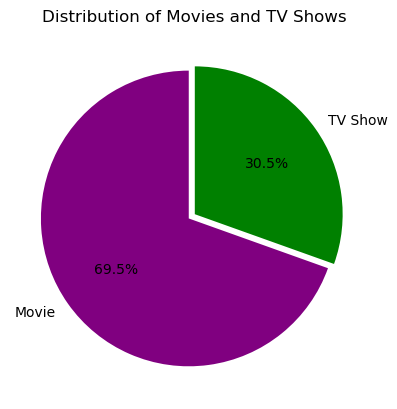

In [12]:
#Distribution of unique Movies and TV Shows (%)
type_counts=df.groupby("type")["title"].nunique()
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90,explode=(0.05, 0),colors=['purple','green'])
plt.title('Distribution of Movies and TV Shows')
plt.show()

## 🎬 Type (TV Shows vs Movies)

### 📌 Observation:
- **69.5%** of the titles are Movies, while **30.5%** are TV Shows.
- **Total Distinct Titles:**
  - 🎥 Movies: **6104**
  - 📺 TV Shows: **2674**
  
### 💡 Suggestion:
Focus more on **movie-related trends**, as they represent the majority of the content. To account for the volume difference and enable clearer insights, separate dashboards or visualizations have been created for movies and TV shows.

In [14]:
#Split data into TV Shows and Movies.

df_shows=df[df['type']=='TV Show']
df_movies=df[df['type']=='Movie']

## Function: `Analyze_column_distribution`

This function is used to perform univariate analysis by showing how many **unique values** of a `target_col` (like job titles) exist within each category of a `column_name` (like country).  

### 🔍 Key Features:
- **Data Cleaning:** Excludes irrelevant or missing values from the dataset.
- **Grouping:** Groups the data by the chosen `column_name` and counts the unique values in the `target_col`.
- **Visualization:** Plots a **bar chart** using Seaborn with flexible axis labels and label orientation.
- **Customization Options:**
  - `top_n` categories to focus on.
  - Customizable `x_col` and `y_col` for orientation.
  - Ability to exclude specific values like "Unknown", 0, etc.
- **Enhanced Readability:** Automatically adds value labels to each bar for better readability.

In [16]:
def Analyze_column_distribution(df, column_name, target_col="title", top_n=10, exclude_values=None, x_col="unique_count", y_col=None):
    """
    Plots the top N unique counts of target_col grouped by column_name.
    Excludes unwanted values and places correct value labels depending on orientation.
    Allows flexible choice for x_col and y_col.
    """
    if exclude_values is None:
        exclude_values = ["Unknown", "unknown", "0", 0, "", None]

    # Step 1: Clean the data
    clean_df = df[(~df[column_name].isin(exclude_values)) &(df[column_name].notna())]

    # Step 2: Group and count
    Result = (clean_df.groupby(column_name)[target_col].nunique().sort_values(ascending=False).head(top_n).reset_index()
              .rename(columns={target_col: "unique_count"}))

    print(f"\n🔢 Top {top_n} unique '{target_col}' counts for '{column_name}':")
    print(Result)

    # Step 3: Plot
    plt.figure(figsize=(8, 4))

    # Default behavior for y-axis if not provided
    if y_col is None:
        y_col = column_name
    ax = sns.barplot(data=Result, x=x_col, y=y_col, palette="viridis", hue=column_name, legend=False)

    plt.title(f"Top {top_n} '{column_name}' by Unique {target_col}", fontsize=14, fontweight="bold")
    
    # 🔁 Flexible axis labels based on column names
    x_label = "Number of " + target_col if x_col == "unique_count" else x_col
    y_label = "Group: " + column_name if y_col is None else y_col
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)

    # Step 4: Adaptive label placement based on axis orientation
    for patch in ax.patches:
        if pd.api.types.is_numeric_dtype(ax.get_xticks()):
            width = patch.get_width()
            y = patch.get_y() + patch.get_height() / 2
            ax.text(width + 1, y, str(int(width)), va='center', ha='left', fontweight='bold', color='black')
        elif pd.api.types.is_numeric_dtype(ax.get_yticks()):
            height = patch.get_height()
            x = patch.get_x() + patch.get_width() / 2
            ax.text(x, height + 1, str(int(height)), ha='center', va='bottom', fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

## Function: `Analyze_top_categories`

This function compares the top N categories (such as country, genre, etc.) in **TV shows** and **movies** by counting unique titles in each category. It generates **side-by-side bar charts** for a quick and clear visual comparison.

### 🔍 Key Features:
- **Comparison of Top Categories:** Analyzes the top N categories in TV shows and movies, focusing on unique title counts.
- **Visualization:** Generates side-by-side **bar charts** for easy comparison between the categories.
- **Customizable:** Adjust the number of top categories (`top_n`) and the specific categories to analyze.

In [18]:
def Analyze_top_categories(df_shows, df_movies, category_col, title_col, x_col, y_col, top_n=5, exclude_values=None):


    # Default exclusion list
    if exclude_values is None:
        exclude_values = ["Unknown", "unknown", "0", 0, "", None]
    # Handle missing columns gracefully
    if category_col not in df_shows.columns or category_col not in df_movies.columns:
        print(f"Column '{category_col}' not found in one of the dataframes.")
        return

    # Filter out unwanted or null values
    df_shows = df_shows[(~df_shows[category_col].isin(exclude_values)) & (df_shows[category_col].notna())]
    df_movies = df_movies[(~df_movies[category_col].isin(exclude_values)) & (df_movies[category_col].notna())]

    # Group by category and count unique titles
    top_tv_categories = (df_shows.groupby(category_col)[title_col].nunique().sort_values(ascending=False).head(top_n).reset_index()
                         .rename(columns={title_col: "Count"}))

    top_movie_categories = (df_movies.groupby(category_col)[title_col].nunique().sort_values(ascending=False).head(top_n).reset_index()
                            .rename(columns={title_col: "Count"}))

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10,3))

    # TV Shows plot
    sns.barplot(ax=axes[0], data=top_tv_categories, x=x_col, y=y_col, palette="Blues_d", hue=category_col, legend=False)
    axes[0].set_title(f"Top {top_n} Categories for TV Shows", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Number of TV Shows" if x_col == "Count" else x_col)
    axes[0].set_ylabel("Number of TV Shows" if y_col == "Count" else y_col)

    # Movies plot
    sns.barplot(ax=axes[1], data=top_movie_categories, x=x_col, y=y_col, palette="Greens_d", hue=category_col, legend=False)
    axes[1].set_title(f"Top {top_n} Categories for Movies", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Number of Movies" if x_col == "Count" else x_col)
    axes[1].set_ylabel("Number of Movies" if y_col == "Count" else y_col)

    for ax in axes:
        for patch in ax.patches:
            # Case 1: Vertical bar chart (like yours) — y-axis is numeric
            if pd.api.types.is_numeric_dtype(ax.get_yticks()):
                height = patch.get_height()  # bar height = count
                x = patch.get_x() + patch.get_width() / 2  # bar center
                ax.text(x, height +0.5, str(int(height)), ha='center', va='bottom', fontweight='bold', color='black')
    
            # Case 2: Horizontal bar chart (x-axis is numeric)
            elif pd.api.types.is_numeric_dtype(ax.get_xticks()):
                width = patch.get_width()
                y = patch.get_y() + patch.get_height() / 2
                ax.text(width +0.5, y, str(int(width)), ha='left', va='center', fontweight='bold', color='black')
    

    plt.tight_layout()
    plt.show()

## Function: `📈 plot_line_for_column`

This function visualizes trends by plotting the count of unique titles over a numeric column (such as release year or month). It is useful for observing patterns or changes over time.

### 🔍 Key Features:
- **Trend Visualization:** Plots the count of unique titles over a numeric column (e.g., release year, month).
- **Pattern Observation:** Helps in identifying patterns or trends, especially for time-series data.
- **Customizable:** Allows flexibility in choosing the column to visualize and adjusting the visual style.

In [20]:
def plot_line_for_column(df, col, title_col, exclude_values=None):
    """
    Plots a line chart showing unique counts of title_col grouped by a numeric column (e.g., year, month).
    Optionally excludes specific values from the grouping column.
    """

    # Set default excluded values if not provided
    if exclude_values is None:
        exclude_values = ["Unknown", "unknown", "0", 0, "", None]

    # Step 1: Clean the data
    clean_df = df[(~df[col].isin(exclude_values)) & (df[col].notna())]

    # Step 2: Group and count
    data = clean_df.groupby(col)[title_col].nunique().reset_index()

    # Step 3: Plot
    sns.lineplot(data=data, x=col, y=title_col, marker='o', color="purple")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel(f"Unique {title_col}")
    plt.title(f"Trend of Unique {title_col} by {col.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()


In [21]:
#Displays the column names of the DataFrame `df`.
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'month_added', 'week_added', 'year_added', 'release_year', 'rating',
       'duration', 'listed_in'],
      dtype='object')


🔢 Top 10 unique 'title' counts for 'director':
              director  unique_count
0        Rajiv Chilaka            22
1            Jan Suter            21
2          Raúl Campos            19
3         Marcus Raboy            16
4          Suhas Kadav            16
5            Jay Karas            15
6  Cathy Garcia-Molina            13
7      Martin Scorsese            12
8          Jay Chapman            12
9      Youssef Chahine            12


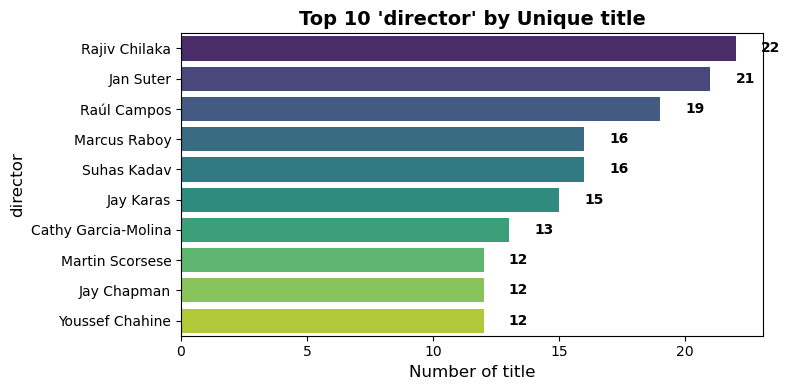

In [22]:
#Shows top 15 directors with the most unique titles.
Analyze_column_distribution(df,column_name='director',target_col="title",top_n=10,exclude_values=['Unknown Director'],x_col="unique_count",y_col=None)

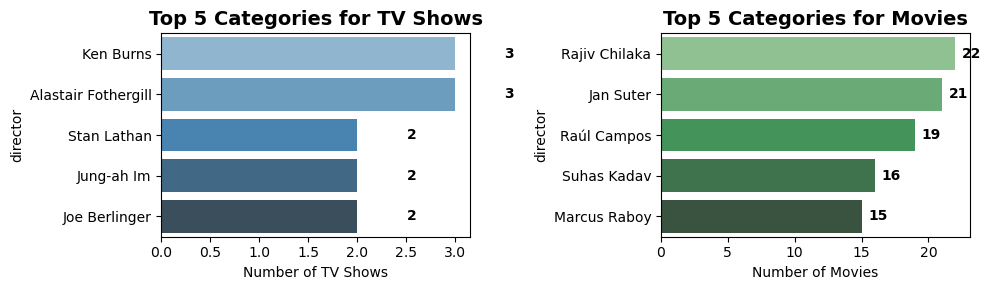

In [23]:
#Compares top `n` categories (e.g., directors) across shows and movies based on unique title counts.  Helps identify leading contributors in each category.
Analyze_top_categories(df_shows,df_movies,category_col='director',title_col='title',exclude_values=['Unknown Director'], x_col='Count',y_col='director',top_n=5)

## 🎬 Director Highlights:
- **Top Directors:**
  - Rajiv Chilaka (22 titles)
  - Jan Suter (21 titles)
  - Raúl Campos (19 titles)
- **TV Show Directors:** Ken Burns & Alastair Fothergill (3 titles each)
- **Movie Directors:** Chilaka, Suter, Campos (16–22 titles)

### ➤ Key Insight:
Directors like **Rajiv Chilaka**, **Jan Suter**, and **Raúl Campos** dominate in **movie content**, suggesting a strong influence on the platform’s film offerings. On the other hand, **TV shows** feature directors like **Ken Burns** and **Alastair Fothergill**, who lead with fewer titles.


🔢 Top 10 unique 'title' counts for 'cast':
               cast  unique_count
0       Anupam Kher            43
1    Shah Rukh Khan            35
2     Julie Tejwani            33
3  Naseeruddin Shah            32
4  Takahiro Sakurai            32
5      Rupa Bhimani            31
6      Akshay Kumar            30
7           Om Puri            30
8         Yuki Kaji            29
9      Paresh Rawal            28


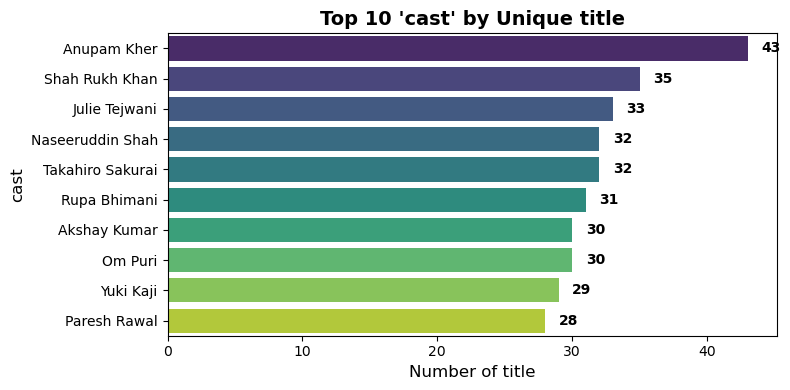

In [25]:
#Displays the top 10 actors based on the number of unique titles they appear in, excluding unknown entries.
Analyze_column_distribution(df,column_name='cast',target_col="title",top_n=10,exclude_values=['Unknown Actor'],x_col="unique_count",y_col=None)

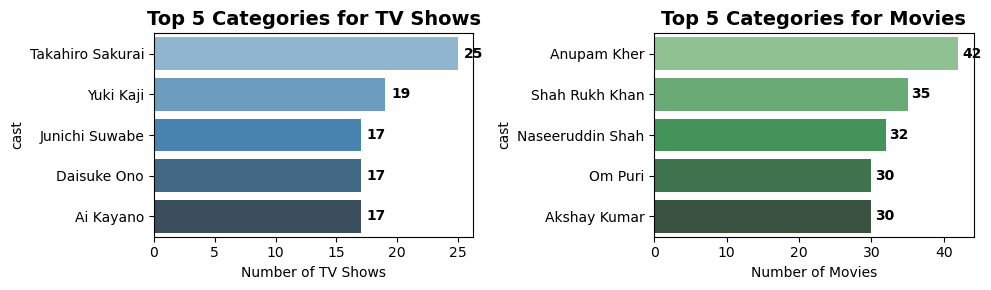

In [26]:
#Compares the top 5 actors by unique title count in both shows and movies, excluding unknown entries.
Analyze_top_categories(df_shows,df_movies,category_col='cast',title_col='title', x_col='Count',y_col='cast',top_n=5,exclude_values=['Unknown Actor'])

## 🟪 Cast Highlights:
- **Top Actors:**
  - Anupam Kher (43 titles)
  - Shah Rukh Khan (35 titles)
  - Julie Tejwani (33 titles)
  - Naseeruddin Shah (32 titles)
- **TV Show Cast:** Takahiro Sakurai (25 titles), Yūki Kaji (19 titles)
- **Movie Cast:** Kher (42 titles), Khan (35 titles), Shah (32 titles)

### ➤ Key Insight:
Actors like Kher, Khan, and Shah play a central role in the platform’s content, while Japanese voice actors dominate TV shows and Bollywood actors lead movies, reflecting regional trends.


🔢 Top 10 unique 'title' counts for 'country':
          country  unique_count
0   United States          3851
1           India          1140
2  United Kingdom           842
3          Canada           484
4          France           413
5           Japan           365
6     South Korea           260
7           Spain           249
8         Germany           234
9          Mexico           184


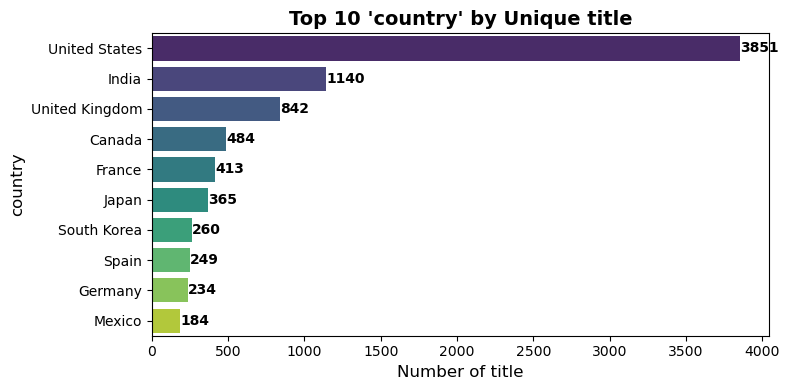

In [28]:
#Shows the top 10 countries with the most unique titles, excluding unknown entries.
Analyze_column_distribution(df,column_name='country',target_col="title",top_n=10,exclude_values=['Unknown Country'],x_col="unique_count",y_col=None)

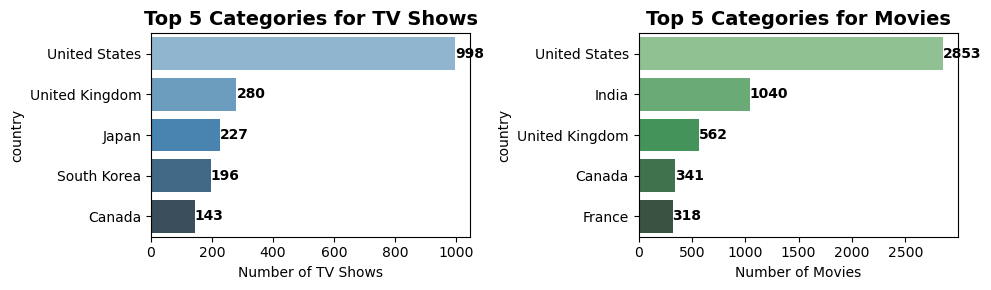

In [29]:
#Compares the top 5 countries producing the most unique titles in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='country',exclude_values=['Unknown Country'],title_col='title', x_col='Count',y_col='country',top_n=5)

## 🌍 Country Highlights:
- **Top Countries:**
  - United States (3851 titles)
  - India (1140 titles)
  - United Kingdom (842 titles)
- **TV Show Country Breakdown:** 
  - United States (998 titles)
  - United Kingdom (280 titles)
  - Japan (227 titles)
- **Movie Country Breakdown:**
  - United States (2853 titles)
  - India (1040 titles)
  - United Kingdom (562 titles)

### ➤ Key Insight:
The United States dominates in both TV shows and movies, with India and the United Kingdom making strong contributions in their respective categories.


🔢 Top 10 unique 'title' counts for 'date_added':
  date_added  unique_count
0 2020-01-01           110
1 2019-11-01            91
2 2018-03-01            75
3 2019-12-31            74
4 2018-10-01            71
5 2019-10-01            62
6 2021-07-01            61
7 2018-11-01            60
8 2021-09-01            58
9 2018-01-01            55


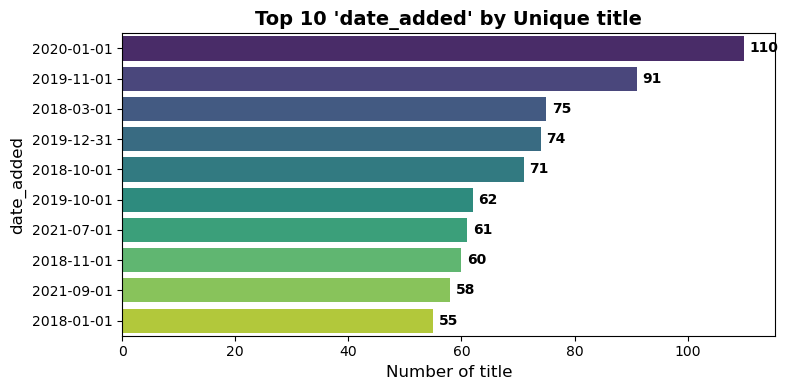

In [31]:
#Shows the top 10 dates when the most unique titles were added to Netflix.
Analyze_column_distribution(df,column_name='date_added',target_col="title",top_n=10,exclude_values=['Unknown Director'],x_col="unique_count",y_col=None)

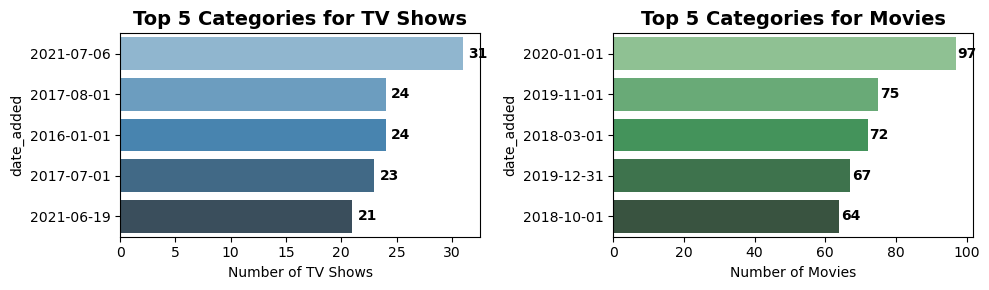

In [32]:
#Compares the top 5 dates with the highest number of title additions in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='date_added',title_col='title', x_col='Count',y_col='date_added',top_n=5)

## 🗓️ Date Added Highlights:

### ➤ Key Insight:
Movies are added in bulk at the start or end of the year, especially around 01/01/2020, indicating strategic additions. TV shows are added in smaller, scattered batches, often mid-year, suggesting a content refresh plan for movies around holidays.


🔢 Top 10 unique 'title' counts for 'month_added':
   month_added  unique_count
0            7           832
1           12           813
2            9           769
3            4           764
4           10           756
5            8           747
6            3           740
7            1           737
8            6           725
9           11           706


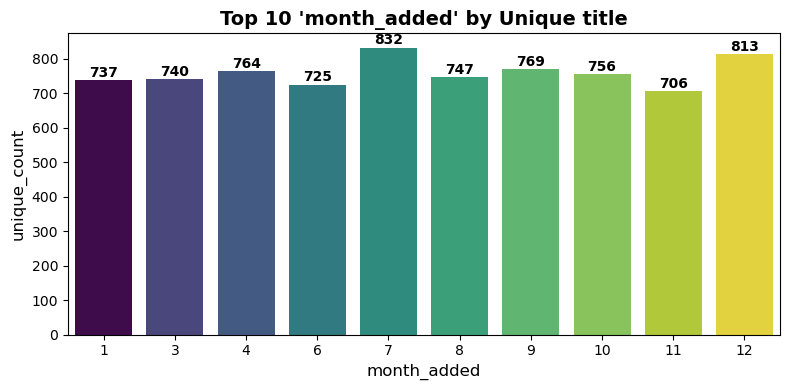

In [34]:
# Displays how many unique titles were added in each month, showing the top 10 months.
Analyze_column_distribution(df,column_name='month_added',target_col="title",top_n=10,exclude_values=[None],x_col='month_added',y_col="unique_count")

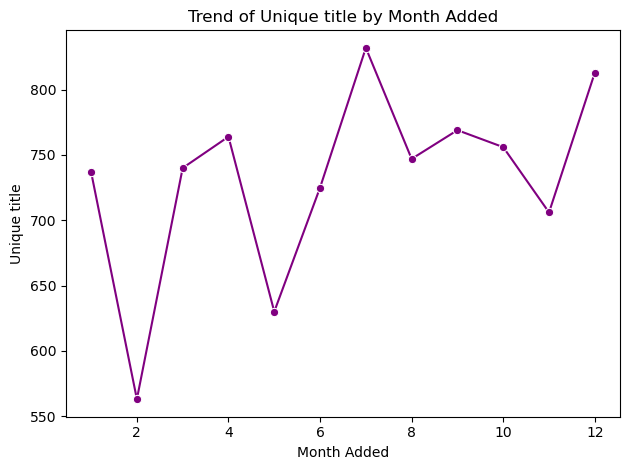

In [35]:
###### Visualizes the trend of unique titles added over each month.
plot_line_for_column(df, "month_added", "title")

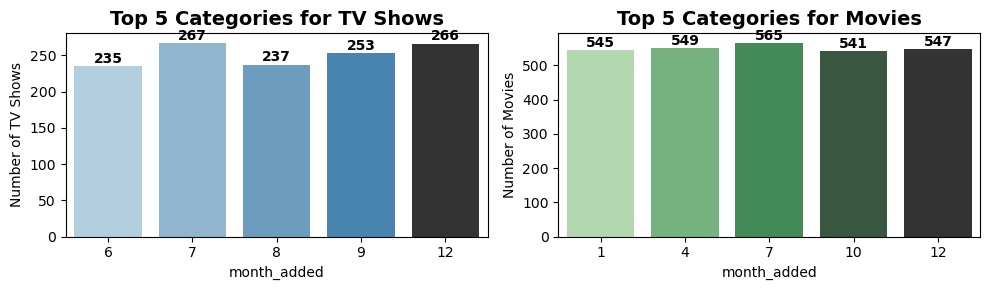

In [36]:
#### Compares the top 5 months with the highest number of title additions in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='month_added',title_col='title', x_col='month_added',y_col='Count',top_n=5)

## 🗓️ Month Added Highlights:

### ➤ Key Insight:
July and December are peak months for both TV shows and movies, likely due to mid-year breaks and holidays. April, September, and October also show strong activity, indicating a strategic content rollout aligned with global viewer cycles.


🔢 Top 10 unique 'title' counts for 'week_added':
   week_added  unique_count
0           1           372
1          44           318
2          40           287
3          31           269
4          26           269
5          35           265
6           9           254
7          13           249
8          27           241
9          18           234


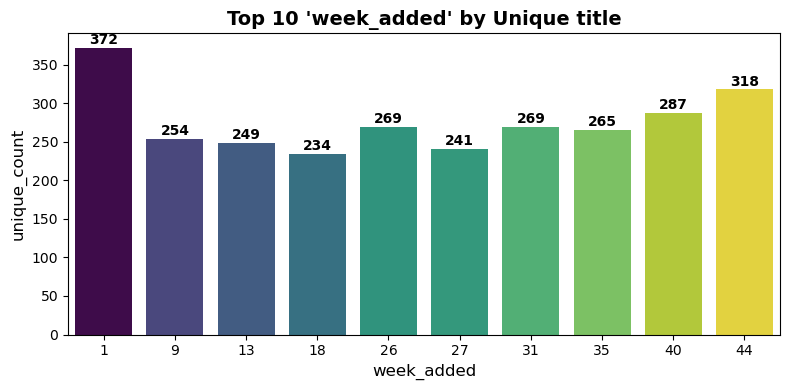

In [38]:
### Displays the top 10 weeks with the most unique title additions.
Analyze_column_distribution(df,column_name='week_added',target_col="title",top_n=10,exclude_values=[None],y_col="unique_count",x_col='week_added')

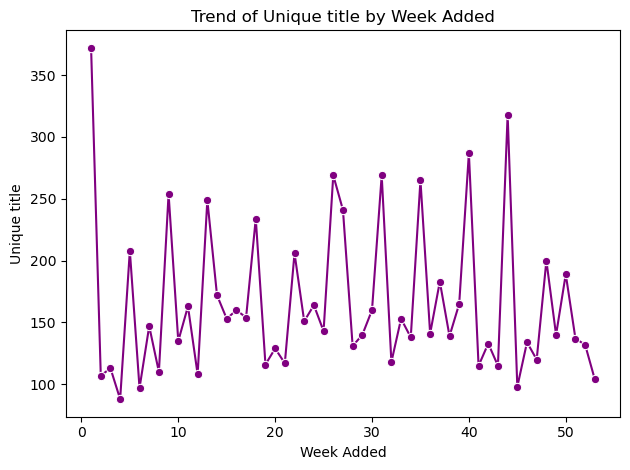

In [39]:
#Visualizes the trend of unique titles added over each week.
plot_line_for_column(df, "week_added", "title")

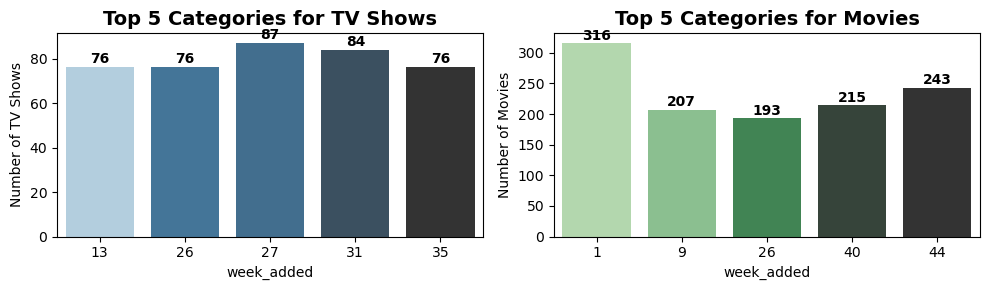

In [40]:
#Compares the top 5 weeks with the highest number of title additions in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='week_added',title_col='title', x_col='week_added',y_col='Count',top_n=5)

## 📅 Week Added Highlights:

### ➤ Key Insight:
Week 1 (early January) stands out for **movies**, hinting at a strong start-of-year content push. **TV shows** are more spread out, with additions peaking in mid-year weeks like Week 27 and 31. This reflects a dual strategy: capitalizing on holiday viewership for **movies** and maintaining regular engagement with episodic **content** mid-year.


🔢 Top 10 unique 'title' counts for 'year_added':
   year_added  unique_count
0        2019          2005
1        2020          1877
2        2018          1649
3        2021          1494
4        2017          1185
5        2016           432
6        2015            82
7        2014            24
8        2011            13
9        2013            11


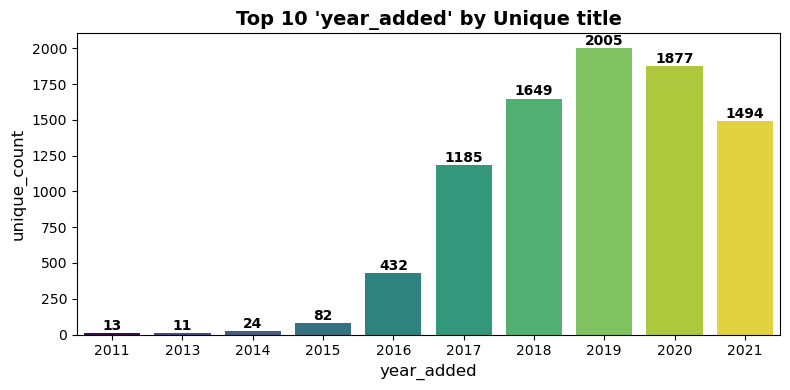

In [42]:
##### Displays the top 10 years with the most unique title additions.
Analyze_column_distribution(df,column_name='year_added',target_col="title",top_n=10,exclude_values=[None],x_col='year_added',y_col="unique_count")

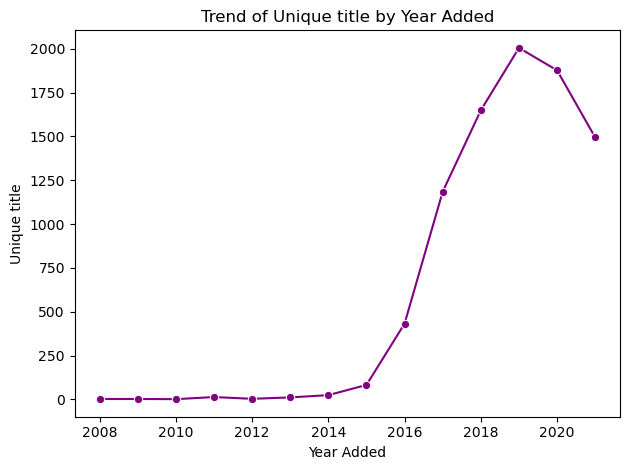

In [43]:
# Visualizes the trend of unique titles added over each year.
plot_line_for_column(df, "year_added", "title")

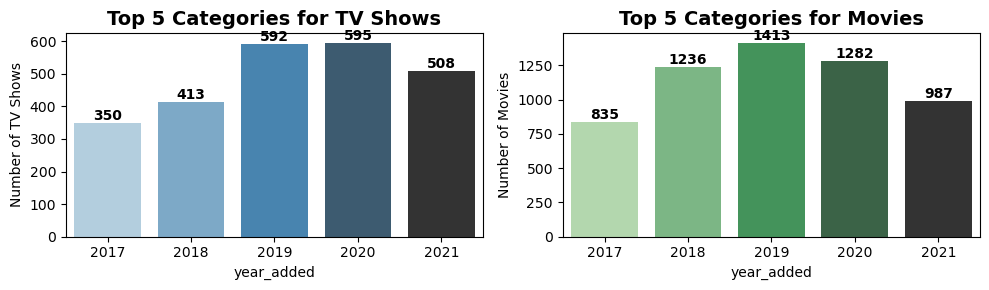

In [44]:
#Compares the top 5 years with the highest number of title additions in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='year_added',title_col='title', x_col='year_added',y_col='Count',top_n=5)

## 📆 Year Added Highlights:

### ➤ Key Insight:
The platform saw a major spike in content additions between 2018 and 2021, especially in 2019 and 2020. **TV shows** peaked in 2020, likely due to increased streaming demand during the pandemic, while **movies** saw the highest growth in 2019, indicating a shift in content expansion strategy before global lockdowns.


🔢 Top 10 unique 'title' counts for 'release_year':
   release_year  unique_count
0          2018          1143
1          2017          1030
2          2019          1018
3          2020           953
4          2016           902
5          2021           587
6          2015           557
7          2014           351
8          2013           288
9          2012           237


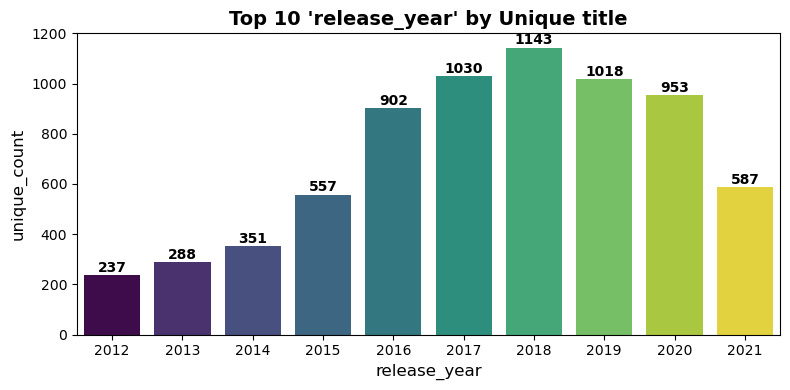

In [46]:
#Displays the top 10 release years with the most unique titles.
Analyze_column_distribution(df,column_name='release_year',target_col="title",top_n=10,exclude_values=[None],x_col='release_year',y_col="unique_count")

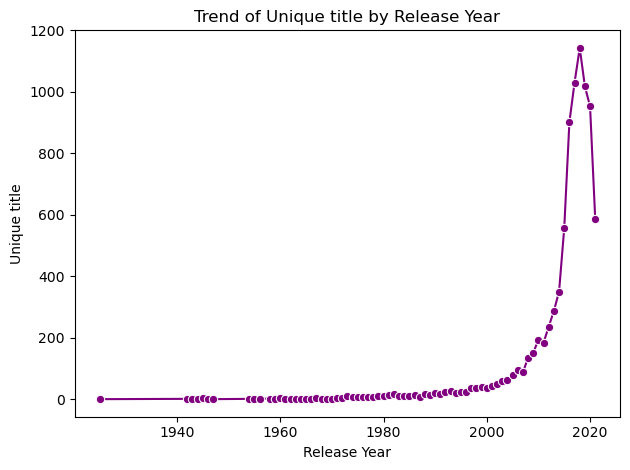

In [47]:
#Visualizes the trend of unique titles released over each year.
plot_line_for_column(df, "release_year", "title")

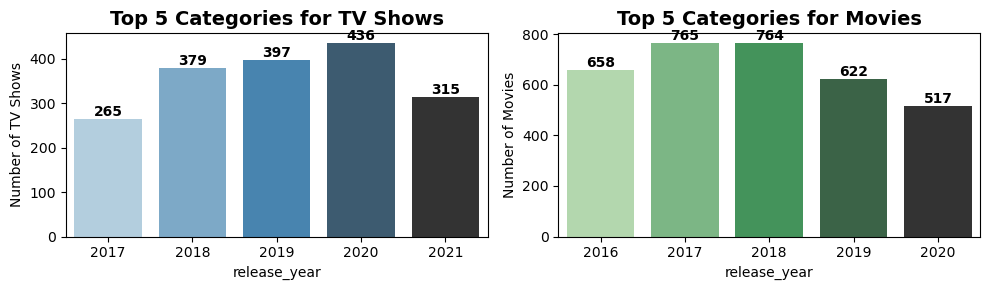

In [48]:
#Compares the top 5 release years with the highest number of title additions in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='release_year',title_col='title', x_col='release_year',y_col='Count',top_n=5)

## 🎞️ Release Year Highlights:

### ➤ Key Insight:
Most content was released between 2016 and 2020, reflecting a focus on recent productions. **Movies** peaked in 2017–2018, while **TV shows** saw the highest releases in 2020, indicating a growing investment in episodic content amid rising streaming demand.

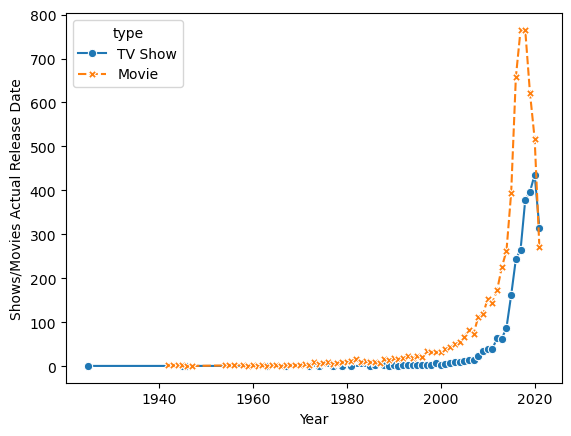

In [50]:
# Group by release_year and type to get unique titles count, and reset index
df_release_year_type = df.groupby(["release_year", "type"])["title"].nunique().reset_index()

# Now plot the lineplot using 'type' for hue and style
sns.lineplot(x='release_year', y='title', hue='type', style='type', markers=True, data=df_release_year_type)
plt.ylabel("Shows/Movies Actual Release Date")
plt.xlabel("Year")
plt.show()

## 📈 Release Trend Over the Years:
- This line plot shows the number of unique **TV Shows** and **Movies** released each year based on actual release dates.
- **Movies** rose sharply from 2010, peaking around 2018–2019 with over 750 titles, then dropped slightly after 2020.
- **TV Shows** increased steadily, peaking in 2020 with over 400 titles, likely due to the streaming boom during the pandemic.
- Pre-2000, both content types had minimal releases, reflecting limited archival data or a focus on newer content.

### ➤ Key Insight:
The platform focuses on modern content, particularly post-2015. **Movies** had an earlier growth, while **TV shows** rapidly gained traction by 2020, indicating a shift toward serialized, binge-worthy content to engage users.


🔢 Top 10 unique 'title' counts for 'rating':
  rating  unique_count
0  TV-MA          3202
1  TV-14          2142
2  TV-PG           863
3      R           798
4  PG-13           489
5  TV-Y7           334
6   TV-Y           305
7     PG           287
8   TV-G           220
9      G            41


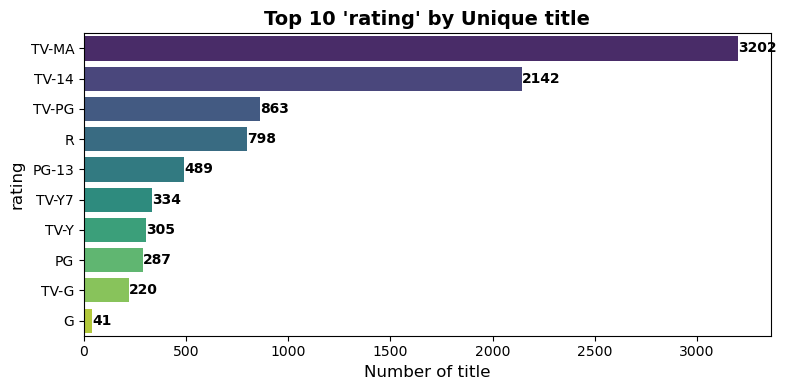

In [52]:
## Displays the top 10 ratings with the most unique titles, excluding 'NR' (Not Rated) entries.
Analyze_column_distribution(df,column_name='rating',target_col="title",top_n=10,exclude_values=['NR'],x_col="unique_count",y_col=None)

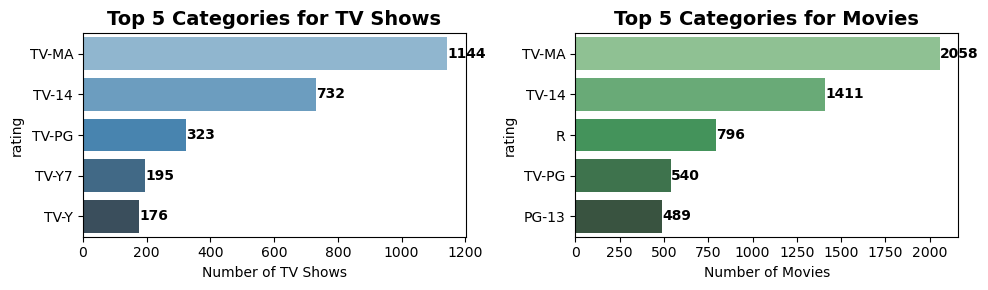

In [53]:
#Compares the top 5 ratings with the highest number of title additions in shows and movies, excluding 'NR' entries.
Analyze_top_categories(df_shows,df_movies,category_col='rating',title_col='title', x_col='Count',y_col='rating',exclude_values=['NR'],top_n=5)

## 🎯 Top Content Ratings on the Platform:
- **TV-MA and R** = Adult content
- **TV-14 and PG-13** = Teens and above
- **TV-PG and PG** = Family-friendly with guidance
- **TV-Y, TV-Y7, TV-G, G** = Child-appropriate

### ➤ Key Insight:
The platform primarily focuses on mature audience content across both **TV shows** and **movies**, while maintaining a balanced offering for teens and children, especially with **TV-PG**, **TV-Y7**, and **TV-Y** ratings.


🔢 Top 10 unique 'title' counts for 'duration':
    duration  unique_count
0     80-100          2219
1   1 Season          1791
2    100-120          1669
3    120-150           885
4      50-80           808
5  2 Seasons           425
6       1-50           287
7    150-200           221
8  3 Seasons           199
9  4 Seasons            95


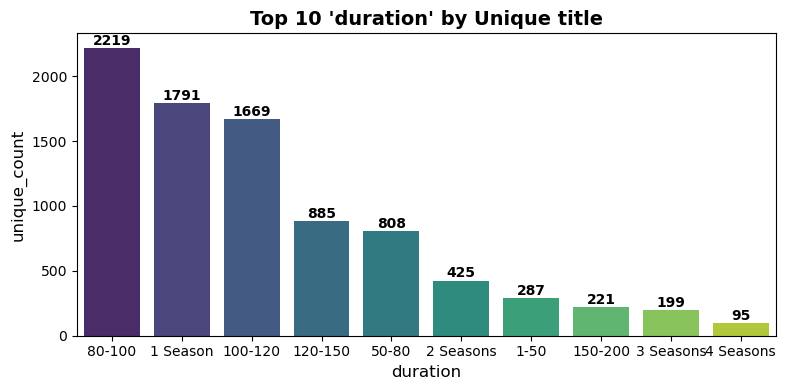

In [55]:
#Displays the top 10 durations (seasons) with the most unique titles, excluding entries with 0 seasons.
Analyze_column_distribution(df,column_name='duration',target_col="title",top_n=10,exclude_values=[0],x_col='duration',y_col="unique_count")

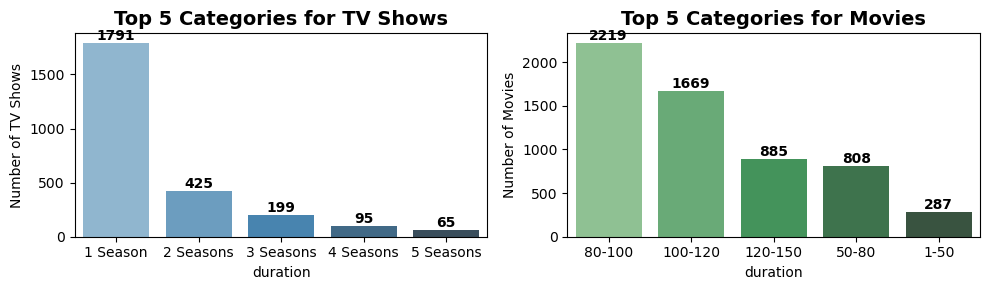

In [56]:
#Compares the top 5 durations (seasons) with the highest number of title additions in shows and movies, excluding entries with 0 seasons.
Analyze_top_categories(df_shows,df_movies,category_col='duration',title_col='title', y_col='Count',x_col='duration',exclude_values=[0],top_n=5)

## 🎞️ Duration Highlights:

### ➤ Key Insight:
Most titles cluster around **80–120 minutes** for **movies** and **1–3 seasons** for **TV shows**, indicating a preference for concise formats. However, the significant presence of shows with **5+ seasons** suggests enduring popularity and loyalty for long-running series.


🔢 Top 10 unique 'title' counts for 'listed_in':
                  listed_in  unique_count
0      International Movies          2731
1                    Dramas          2411
2                  Comedies          1669
3    International TV Shows          1350
4             Documentaries           869
5        Action & Adventure           852
6                 TV Dramas           761
7        Independent Movies           755
8  Children & Family Movies           638
9           Romantic Movies           615


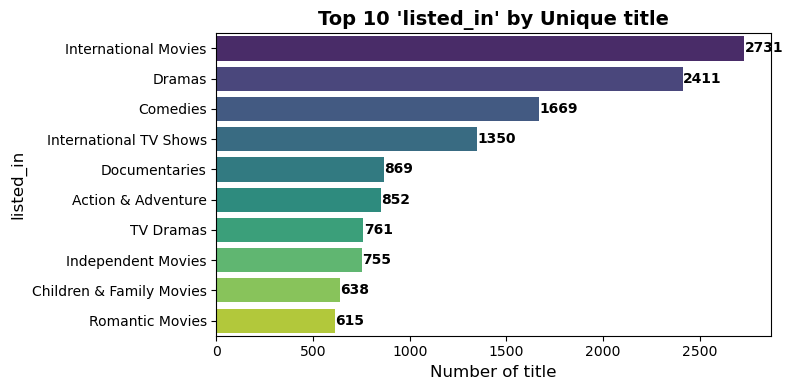

In [58]:
#Displays the top 10 categories (listed_in) with the most unique titles, excluding entries with no categories.
Analyze_column_distribution(df,column_name='listed_in',target_col="title",top_n=10,exclude_values=[None],x_col="unique_count",y_col=None)

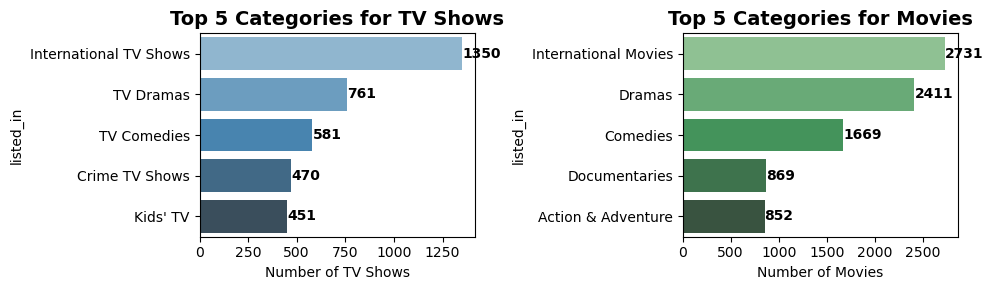

In [59]:
#Compares the top 5 categories with the highest number of title additions in shows and movies.
Analyze_top_categories(df_shows,df_movies,category_col='listed_in',title_col='title', x_col='Count',y_col='listed_in',top_n=5)

## 🎞️ Genre Distribution Highlights:

### Observation:
- **Movies**: The most common genres are **Dramas** (2411), **Comedies** (1669), and **International Movies** (2731), followed by **Documentaries** (869). These genres dominate, reflecting a strong focus on diverse global content and narratives.
- **TV Shows**: The leading genres are **International TV Shows** (1350), **TV Dramas** (761), and **TV Comedies** (581), with notable genres like **Docuseries** (395) and **Crime TV Shows** (470). TV shows have higher representation in genres like **Reality TV** (255) and **Kids' TV** (451).

### ➤ Key Insight:
The platform has a strong focus on **international movies**, **dramas**, and **comedies**, with these genres leading in unique titles. Other notable categories include **international TV shows** and **documentaries**. Genres like **action & adventure** and **romantic movies** have slightly smaller representation, showing a diverse yet concentrated content offering in popular genres. **Movies** are predominantly represented by **international films**, **dramas**, and **comedies**, with significant portions also in **action & adventure** and **documentaries**, appealing to varied tastes. **TV shows** are largely centered around **international series** and **dramas**, with an increasing focus on **serialized, binge-worthy content** that aligns with global streaming trends.

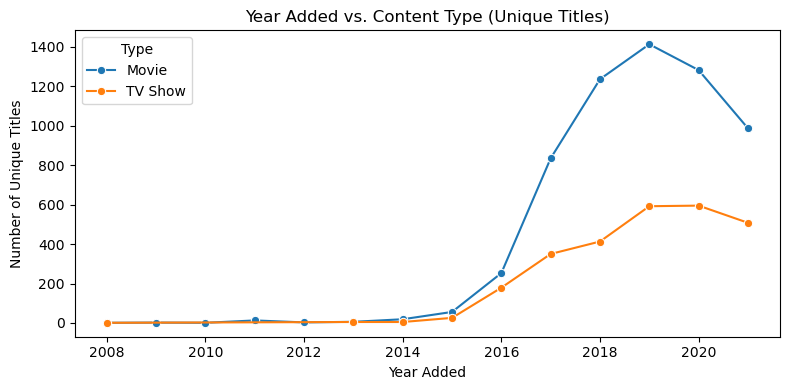

In [61]:
###Date Added vs. Type (TV Show vs Movie)

# Grouping by Year and Type and counting unique titles
type_trend_unique = df.groupby(['year_added', 'type'])['title'].nunique().reset_index(name='count')

# Plot
plt.figure(figsize=(8, 4))
sns.lineplot(data=type_trend_unique, x='year_added', y='count', hue='type', marker="o")
plt.title('Year Added vs. Content Type (Unique Titles)')
plt.xlabel('Year Added')
plt.ylabel('Number of Unique Titles')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

## 🎥 Date Added vs. Type (TV Show vs Movie)

### Observation:
- Minimal content was added before **2015**.
- From **2016** onwards, both **Movies** and **TV Shows** saw a sharp, steady rise in unique titles.
- **Movies** consistently outnumber **TV Shows** in volume each year.
- **TV Shows** show strong growth from **2017**, peaking around **2020–2021**.

### ➤ Key Insight:
The platform has steadily ramped up content in both formats since **2016**. While **Movies** dominate in volume, the significant rise in **TV Shows** indicates a growing focus on episodic content, likely driven by binge-watching trends and long-term viewer engagement.

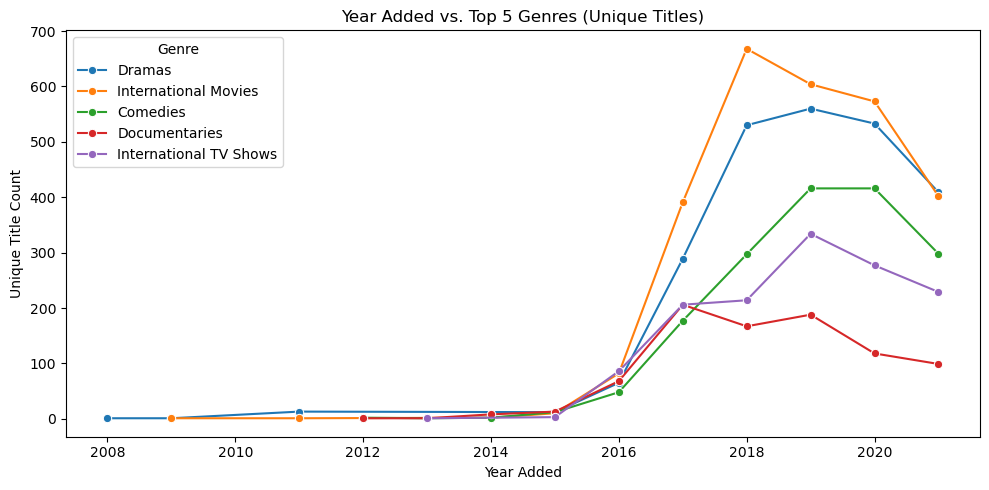

In [63]:
### Trend: Year Added vs. Top Genres

# Group by year and genre, count unique titles
genre_trend = df.groupby(['year_added', 'listed_in'])['title'].nunique().reset_index(name='count')

# Top 5 genres overall based on total unique titles
top_genres = genre_trend.groupby('listed_in')['count'].sum().nlargest(5).index

# Filter only top genres
genre_trend_top = genre_trend[genre_trend['listed_in'].isin(top_genres)]

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(data=genre_trend_top, x='year_added', y='count', hue='listed_in', marker='o')

plt.title('Year Added vs. Top 5 Genres (Unique Titles)')
plt.xlabel('Year Added')
plt.ylabel('Unique Title Count')
plt.legend(title='Genre')
plt.tight_layout()
plt.show()

## 🎯 Top Genre Trends on the Platform

### Observation:
- **Dramas**: Consistent growth since **2016**, reflecting increasing demand.
- **International Movies**: Rising steadily, indicating a shift toward global content.
- **International TV Shows**: Significant spike post-2016, catering to a diverse, non-English-speaking audience.
- **Documentaries**: Fluctuations, with spikes in **2016-2017**, possibly tied to events or trends.
- **Fluctuating Genres**: **Comedies** and **Action & Adventure** show variable trends, likely influenced by changing viewer preferences.

### ➤ Key Insight:
The platform has focused on expanding its **international** and **drama** offerings, with significant growth in non-English content, while maintaining flexibility in genres like **comedies** and **action**.

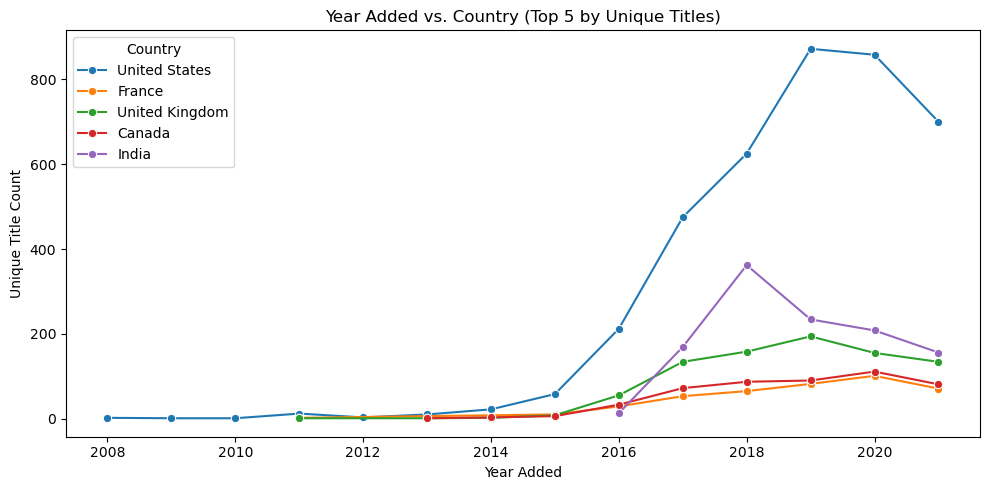

In [65]:
### Trend:  Date Added vs. Country

df_clean = df[df['country'] != 'Unknown Country']
# Group by year_added and country, get unique titles
country_trend = df_clean.groupby(['year_added', 'country'])['title'].nunique().reset_index(name='count')

# Get top 5 countries with highest total unique titles added
top_countries = country_trend.groupby('country')['count'].sum().nlargest(5).index

# Filter only for top countries
country_trend_top = country_trend[country_trend['country'].isin(top_countries)]

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(data=country_trend_top, x='year_added', y='count', hue='country', marker='o')
plt.title('Year Added vs. Country (Top 5 by Unique Titles)')
plt.xlabel('Year Added')
plt.ylabel('Unique Title Count')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

## 🌍 Date Added vs. Country (Top 5 by Unique Titles)

### Observation:
- **United States** consistently leads in content additions across all years.
- **India** shows a dramatic rise starting in **2017**, peaking in **2018**.
- **United Kingdom**, **France**, and **Canada** show steady growth with minor year-to-year fluctuations.
- All top 5 countries have notable spikes from **2016** onwards, reflecting global expansion.

### ➤ Key Insight:
The platform significantly scaled its international content after **2016**. While the **U.S.** remains dominant, countries like **India** and the **UK** emerged as major contributors, indicating a strategic focus on regional and globally diverse content offerings.

              release_year  year_added
release_year      1.000000    0.110242
year_added        0.110242    1.000000


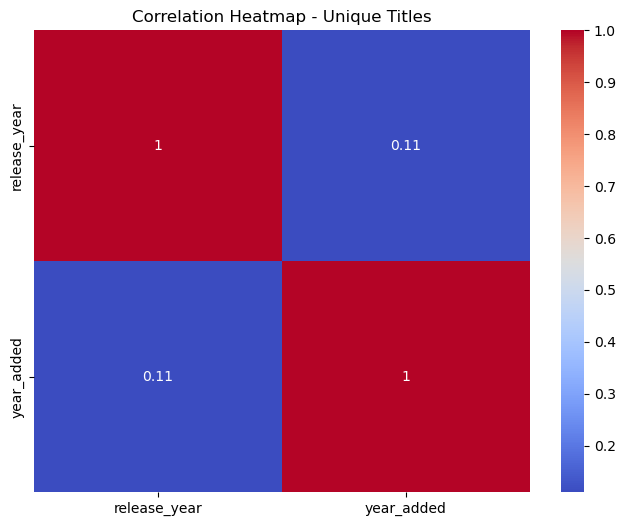

In [67]:
# Step 1: Group by unique titles and aggregate the necessary columns
df_unique_titles = df.groupby('title').agg({
    'release_year': 'first',  # or any other aggregation like mean
    'year_added': 'first'     # or any other aggregation
}).reset_index()

# Step 2: Calculate the correlation matrix for the unique titles
correlation_matrix = df_unique_titles[['release_year', 'year_added']].corr()
print(correlation_matrix)
# Step 3: Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap - Unique Titles")
plt.show()


## Insight: 
The correlation between **release year** and **year added** is weak (**0.11**), indicating that the timing of adding titles to the platform is not strongly influenced by their release year.

              release_year  year_added
release_year      1.000000    0.378817
year_added        0.378817    1.000000


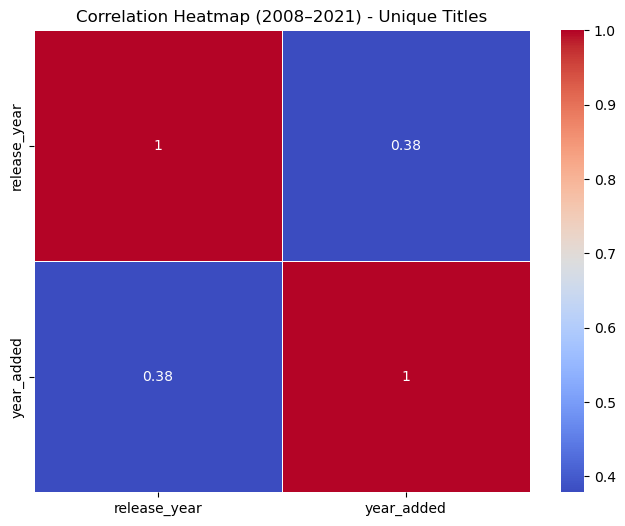

In [69]:
# Step 1: Group by unique titles and aggregate
df_unique_titles = df.groupby('title').agg({
    'release_year': 'first',
    'year_added': 'first'
}).reset_index()

# Step 2: Filter for years between 2008 and 2021
filtered_df = df_unique_titles[
    (df_unique_titles['release_year'].between(2008, 2021)) &
    (df_unique_titles['year_added'].between(2008, 2021))
]

# Step 3: Compute correlation matrix
correlation_matrix = filtered_df[['release_year', 'year_added']].corr()
print(correlation_matrix)

# Step 4: Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap (2008–2021) - Unique Titles")
plt.show()

## 📊 Correlation Insight (2008–2021)

### ➤ Key Insight:
When focusing on titles released and added between **2008** and **2021**, the correlation between **release_year** and **year_added** increases to **0.38**.  
This suggests a moderate relationship, meaning **newer titles** are more likely to be added to Netflix soon after their release, reflecting a stronger focus on **recent content**.

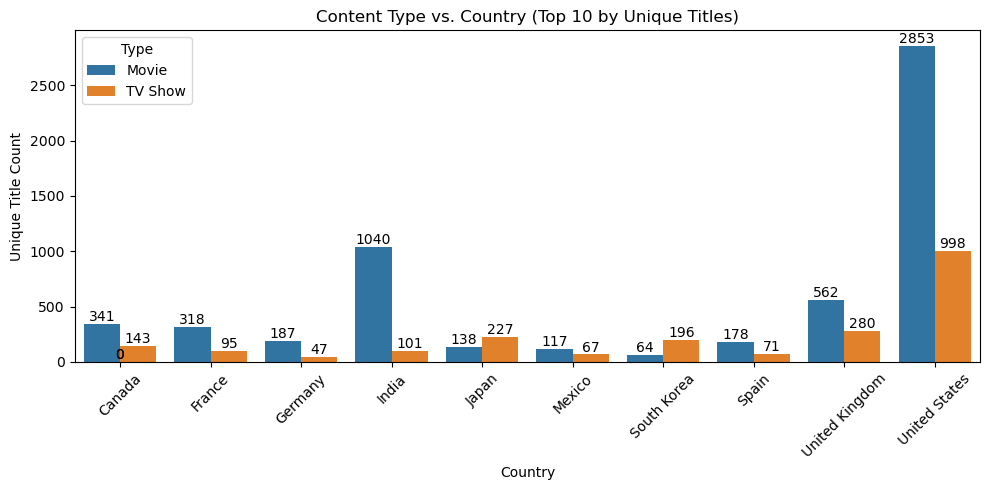

In [71]:
### Content Type vs. Country (Top 10 by Unique Titles)


df_clean_country = df[df['country'] != 'Unknown Country']

# Group by country and type, count unique titles
country_type_trend = df_clean_country.groupby(['country', 'type'])['title'].nunique().reset_index(name='count')

# Get top 10 countries by total unique titles
top_countries_ct = country_type_trend.groupby('country')['count'].sum().nlargest(10).index

# Filter only top countries
country_type_top = country_type_trend[country_type_trend['country'].isin(top_countries_ct)]

# Plot grouped bar chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=country_type_top, x='country', y='count', hue='type')
plt.title('Content Type vs. Country (Top 10 by Unique Titles)')
plt.xlabel('Country')
plt.ylabel('Unique Title Count')
plt.legend(title='Type')
plt.xticks(rotation=45)

# Adding the count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 🌍 Content Type vs. Country (Top 10 by Unique Titles)

### Observation:
- **United States** dominates both **Movie** and **TV Show** categories, with the highest number of unique titles in both types.
- **Canada** follows, with a significantly higher count of unique **Movies** than **TV Shows**.
- **India** has a high volume of **Movies** but fewer **TV Shows** compared to other countries in the top 10.
- **United Kingdom**, **France**, and **Germany** show a balanced split between **Movies** and **TV Shows**, with **Movies** generally leading.
- **Japan** stands out with a higher count of unique **TV Shows** than **Movies**.

### ➤ Key Insight:
The **United States** leads across both **Movie** and **TV Show** content, reflecting its global dominance in entertainment production. Other countries, like **Canada**, **India**, and **Japan**, show strong presences in specific content types, such as **Movies** or **TV Shows**, indicating distinct content creation trends.

In [123]:
# Filter data by country for Movies
df_movies_us = df_movies[df_movies['country'] == 'United States']
df_movies_in = df_movies[df_movies['country'] == 'India']
df_movies_uk = df_movies[df_movies['country'] == 'United Kingdom']
df_movies_ca = df_movies[df_movies['country'] == 'Canada']
df_movies_sk = df_movies[df_movies['country'] == 'South Korea']
df_movies_jp = df_movies[df_movies['country'] == 'Japan']

# Filter data by country for TV Shows
df_shows_us = df_shows[df_shows['country'] == 'United States']
df_shows_in = df_shows[df_shows['country'] == 'India']
df_shows_uk = df_shows[df_shows['country'] == 'United Kingdom']
df_shows_ca = df_shows[df_shows['country'] == 'Canada']
df_shows_sk = df_shows[df_shows['country'] == 'South Korea']
df_shows_jp =  df_shows[df_shows['country'] == 'Japan']

## Function: `Analyze_column_distribution_by_country`

### Purpose:
Analyzes and visualizes the distribution of unique titles in a given column (e.g., genre, rating) across TV shows or movies for five countries: the US, India, the UK, South Korea, and Japan.

### Parameters:
- **df_us, df_in, df_uk, df_sk, df_jp,df_ca (DataFrames)**: DataFrames for each country (US, India, UK, South Korea, Japan,Canada).
- **column_name (str)**: The column to analyze (e.g., 'genre', 'rating').
- **media_type (str)**: Type of media ('tv_shows' or 'movies').
- **exclude_values (list, optional)**: List of values to exclude from the analysis (e.g., "Unknown").

### Output:
- A 2x3 grid of bar charts comparing the top 10 unique titles across the five countries based on the selected column.

In [136]:
def Analyze_column_distribution_by_country(df_us, df_in, df_uk, df_sk, df_jp,df_ca,column_name, media_type, exclude_values=None):
    import seaborn as sns
    import matplotlib.pyplot as plt

    def clean_df(df):
        df_clean = df.dropna(subset=[column_name])
        if exclude_values:
            df_clean = df_clean[~df_clean[column_name].isin(exclude_values)]
        return df_clean

    # Clean all five country DataFrames
    df_us = clean_df(df_us)
    df_in = clean_df(df_in)
    df_uk = clean_df(df_uk)
    df_ca = clean_df(df_ca)
    df_sk = clean_df(df_sk)
    df_jp = clean_df(df_jp)

    # Group, count unique titles, and take top 10
    us_column_counts = (df_us.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10))
    in_column_counts = (df_in.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10))
    uk_column_counts = (df_uk.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10))
    ca_column_counts = (df_ca.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10))
    sk_column_counts = (df_sk.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10))
    jp_column_counts = (df_jp.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10))

    # Set up color palettes
    viridis_palette_us = sns.color_palette("viridis", len(us_column_counts))
    viridis_palette_in = sns.color_palette("viridis", len(in_column_counts))
    viridis_palette_uk = sns.color_palette("viridis", len(uk_column_counts))
    viridis_palette_ca = sns.color_palette("viridis", len(ca_column_counts))
    viridis_palette_sk = sns.color_palette("viridis", len(sk_column_counts))
    viridis_palette_jp = sns.color_palette("viridis", len(jp_column_counts))

    # Print counts (optional)
    print("US:\n", us_column_counts, "\n")
    print("India:\n", in_column_counts, "\n")
    print("UK:\n", uk_column_counts, "\n")
    print("CA:\n", ca_column_counts, "\n")
    print("South Korea:\n", sk_column_counts, "\n")
    print("Japan:\n", jp_column_counts, "\n")

    # Plotting
    plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    sns.barplot(data=us_column_counts, x=column_name, y='title', palette=viridis_palette_us,hue=column_name, legend=False)
    plt.title(f'Top 10 {media_type.title()} by {column_name.title()} - US')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())

    plt.subplot(2, 3, 2)
    sns.barplot(data=in_column_counts, x=column_name, y='title', palette=viridis_palette_in,hue=column_name, legend=False)
    plt.title(f'Top 10 {media_type.title()} by {column_name.title()} - India')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())

    plt.subplot(2, 3, 3)
    sns.barplot(data=uk_column_counts, x=column_name, y='title', palette=viridis_palette_uk,hue=column_name, legend=False)
    plt.title(f'Top 10 {media_type.title()} by {column_name.title()} - UK')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())

    plt.subplot(2, 3, 4)
    sns.barplot(data=ca_column_counts, x=column_name, y='title', palette=viridis_palette_ca,hue=column_name, legend=False)
    plt.title(f'Top 10 {media_type.title()} by {column_name.title()} - Canada')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())

    plt.subplot(2, 3, 5)
    sns.barplot(data=sk_column_counts, x=column_name, y='title', palette=viridis_palette_sk,hue=column_name, legend=False)
    plt.title(f'Top 10 {media_type.title()} by {column_name.title()} - South Korea')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())

    plt.subplot(2, 3, 6)
    sns.barplot(data=jp_column_counts, x=column_name, y='title', palette=viridis_palette_jp,hue=column_name, legend=False)
    plt.title(f'Top 10 {media_type.title()} by {column_name.title()} - Japan')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())

    plt.tight_layout(pad=4.0)
    plt.show()

US:
    rating  title
7   TV-MA    751
4       R    667
3   PG-13    436
5   TV-14    293
2      PG    247
8   TV-PG    187
9    TV-Y     70
10  TV-Y7     63
6    TV-G     51
0       G     39 

India:
      rating  title
3     TV-14    560
5     TV-MA    239
6     TV-PG    137
8     TV-Y7     57
1     PG-13     11
7      TV-Y      9
0        PG      7
4      TV-G      7
2         R      6
9  TV-Y7-FV      1 

UK:
   rating  title
3      R    148
6  TV-MA    146
2  PG-13     84
4  TV-14     61
7  TV-PG     42
1     PG     36
8   TV-Y     14
5   TV-G     10
9  TV-Y7      6
0      G      4 

CA:
    rating  title
4       R     85
7   TV-MA     75
2      PG     34
3   PG-13     33
5   TV-14     32
9    TV-Y     28
8   TV-PG     26
10  TV-Y7     11
6    TV-G      9
0       G      2 

South Korea:
   rating  title
6  TV-MA     38
9  TV-Y7      6
4  TV-14      4
7  TV-PG      4
1     PG      2
3      R      2
0      G      1
2  PG-13      1
5   TV-G      1
8   TV-Y      1 

Japan:
   rating  

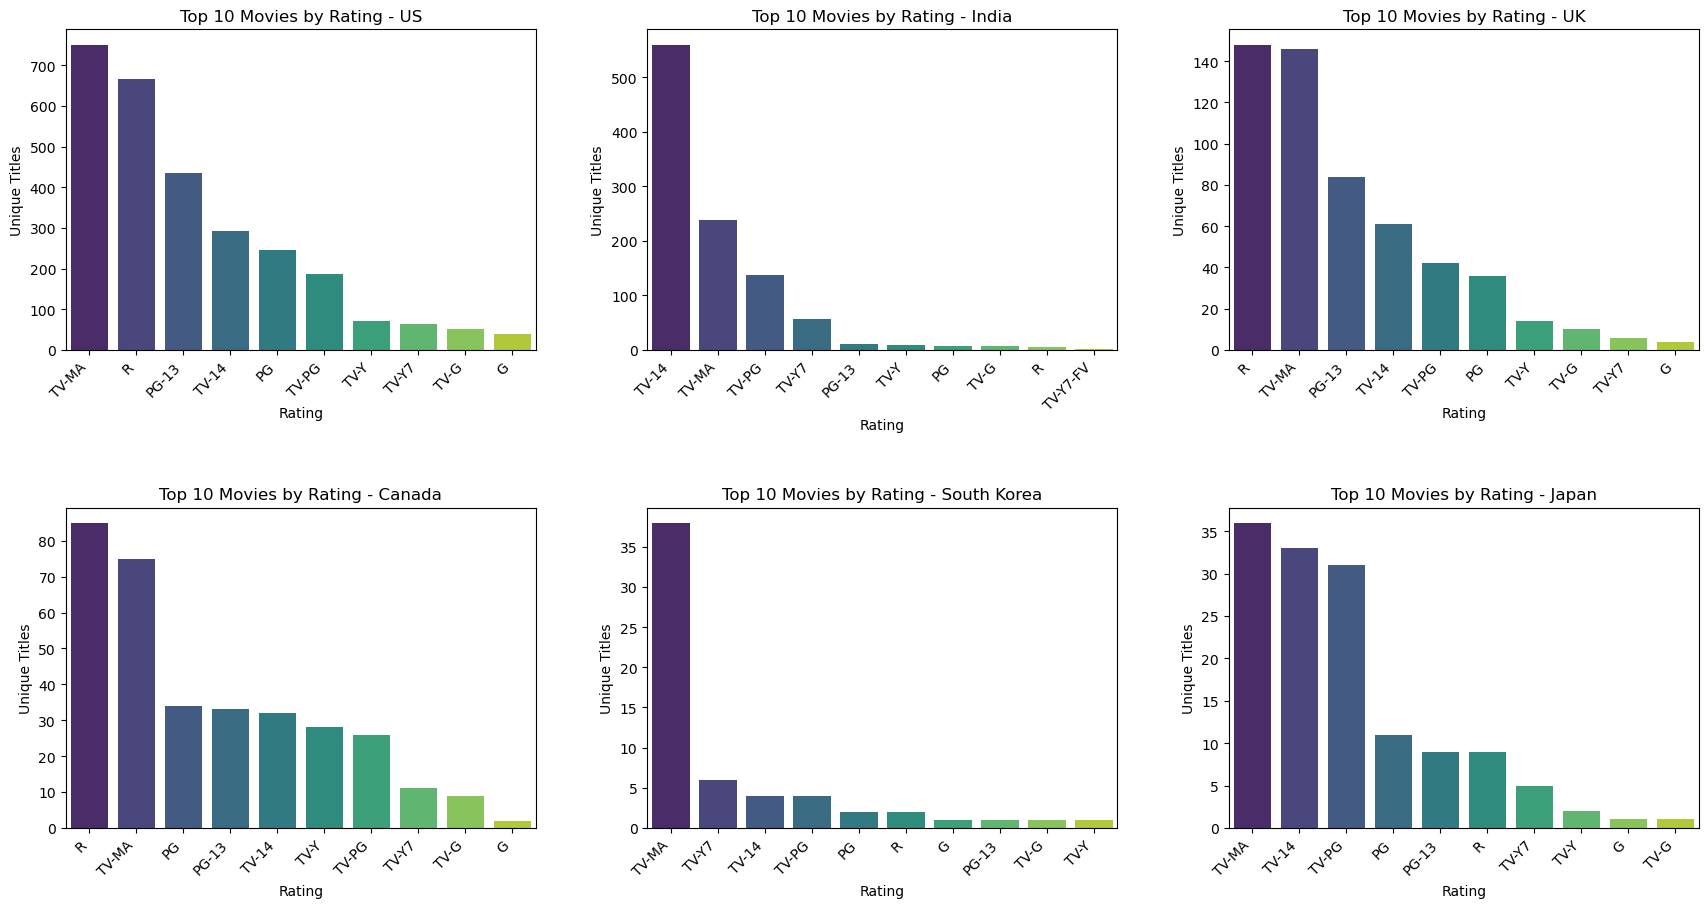

In [138]:
# For movies based on 'rating':
Analyze_column_distribution_by_country(df_movies_us, df_movies_in, df_movies_uk, df_movies_sk,df_movies_jp,df_movies_ca, column_name='rating', media_type='movies',exclude_values=['NR'])


## 🎬 Key Observations by Country:based on 'rating'
### 🇺🇸 United States  
**Most frequent**: TV-MA (751), then R, PG-13  
**Trend**: High preference for mature content (TV-MA, R)

### 🇮🇳 India  
**Most frequent**: TV-14 (560), then TV-MA, TV-PG  
**Trend**: Family-friendly focus (TV-14, TV-PG); less R or PG-13

### UK United Kingdom 
**Most frequent**: R (148) and TV-MA (146)  
**Trend**: Balanced mix of mature and teen content

### 🇨🇦 Canada  
**Most frequent**: R (85), then TV-MA, PG  
**Trend**: Similar to US, but favors film ratings slightly more

### SK South Korea  
**Most frequent**: TV-MA (38); others low  
**Trend**: Low diversity, skewed toward TV-MA

### 🇯🇵 Japan  
**Most frequent**: TV-MA (36), then TV-14, TV-PG  
**Trend**: Mature and teen content dominant

## 📊 Cross-Country Trends:
- **TV-MA** dominates in US, UK, JP, SK  
- **R** more common in Western regions (US, UK, CA)  
- **India** leads in TV-14, indicating teen/family targeting  
- **Kids' ratings** (TV-Y, TV-G, G, TV-Y7) mostly seen in US

US:
   rating  title
3  TV-MA    400
1  TV-14    228
4  TV-PG    132
6  TV-Y7    109
5   TV-Y     81
2   TV-G     45
0      R      1 

India:
   rating  title
2  TV-MA     36
0  TV-14     29
3  TV-PG     14
5  TV-Y7     11
4   TV-Y      8
1   TV-G      3 

UK:
   rating  title
2  TV-MA    120
3  TV-PG     59
0  TV-14     45
4   TV-Y     29
1   TV-G     15
5  TV-Y7     10 

CA:
   rating  title
0  TV-14     79
2  TV-MA     76
5  TV-Y7     37
3  TV-PG     24
4   TV-Y      6
1   TV-G      4 

South Korea:
      rating  title
2     TV-MA     38
5     TV-Y7     31
4      TV-Y     27
0     TV-14     21
3     TV-PG     16
1      TV-G      9
6  TV-Y7-FV      1 

Japan:
   rating  title
0  TV-14     91
2  TV-MA     60
3  TV-PG     17
5  TV-Y7     16
4   TV-Y     11
1   TV-G      1 



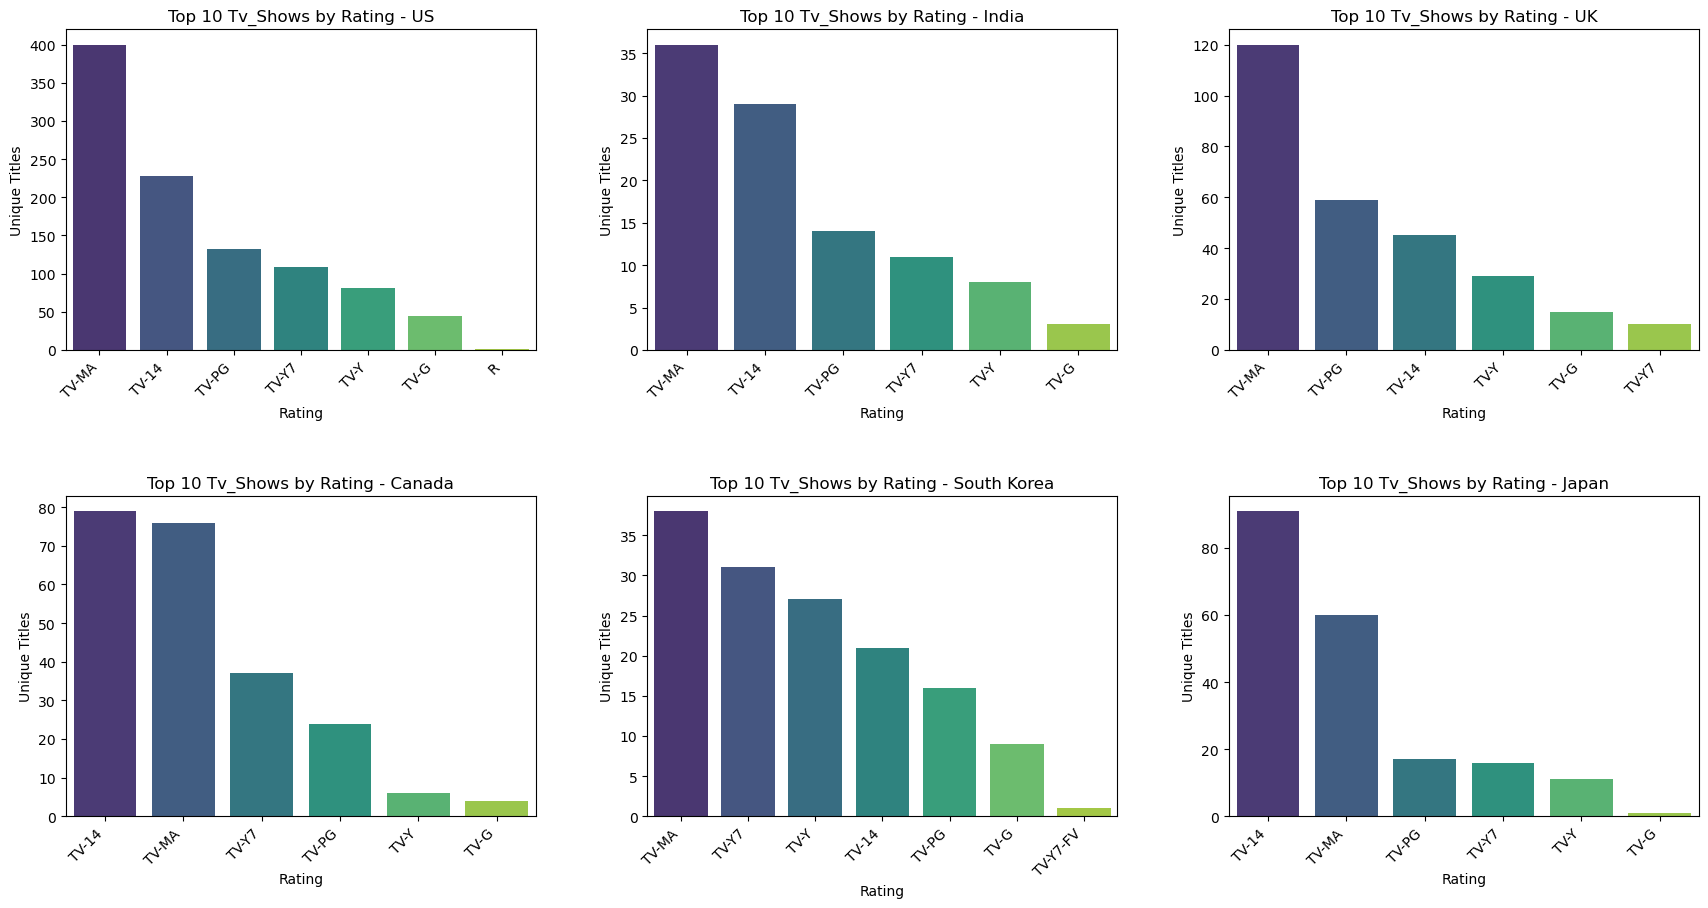

In [140]:
# For TV shows based on 'rating':
Analyze_column_distribution_by_country(df_shows_us, df_shows_in, df_shows_uk,df_shows_ca, df_shows_sk,df_shows_jp, column_name='rating', media_type='tv_shows',exclude_values=['NR'])

## 📺 Key Observations by Country (TV Shows):based on 'rating'

### 🇺🇸 United States  
**Most frequent**: TV-MA (400), then TV-14 (228), TV-PG (132)  
**Trend**: Strong presence of mature (TV-MA) and teen-rated content  

### 🇮🇳 India  
**Most frequent**: TV-MA (36), then TV-14 (29), TV-PG (14)  
**Trend**: Mix of mature and teen content, no R-rated shows  

### UK United Kingdom  
**Most frequent**: TV-MA (120), TV-PG (59), TV-14 (45)  
**Trend**: Preference for TV-MA with balanced teen/family content  

### 🇨🇦 Canada  
**Most frequent**: TV-14 (79), TV-MA (76), TV-Y7 (37)  
**Trend**: Similar balance as UK, skewed toward teen/mature content  

### SK South Korea  
**Most frequent**: TV-MA (38), TV-Y7 (31), TV-Y (27)  
**Trend**: More variety; includes content for kids and adults  

### 🇯🇵 Japan  
**Most frequent**: TV-14 (91), TV-MA (60), TV-PG (17)  
**Trend**: Dominated by teen and mature ratings  

## 🌐 Cross-Country Trends:
- **TV-MA** is dominant in most regions, especially US, UK, and SK  
- **TV-14** is prominent in JP, CA, and India  
- **Kids' ratings** (TV-Y, TV-Y7, TV-G) are consistently present but less dominant  
- **R rating** almost non-existent for TV shows, seen only once in the US

US:
                    listed_in  title
7                     Dramas    843
4                   Comedies    702
6              Documentaries    526
2   Children & Family Movies    417
0         Action & Adventure    413
10        Independent Movies    391
19                 Thrillers    296
15           Romantic Movies    229
18           Stand-Up Comedy    229
9              Horror Movies    209 

India:
                    listed_in  title
10      International Movies    887
6                     Dramas    677
3                   Comedies    339
9         Independent Movies    169
0         Action & Adventure    143
14           Romantic Movies    122
13          Music & Musicals    102
18                 Thrillers     98
1   Children & Family Movies     78
8              Horror Movies     37 

UK:
                    listed_in  title
7                     Dramas    198
11      International Movies    172
6              Documentaries    129
4                   Comedies     94
0     

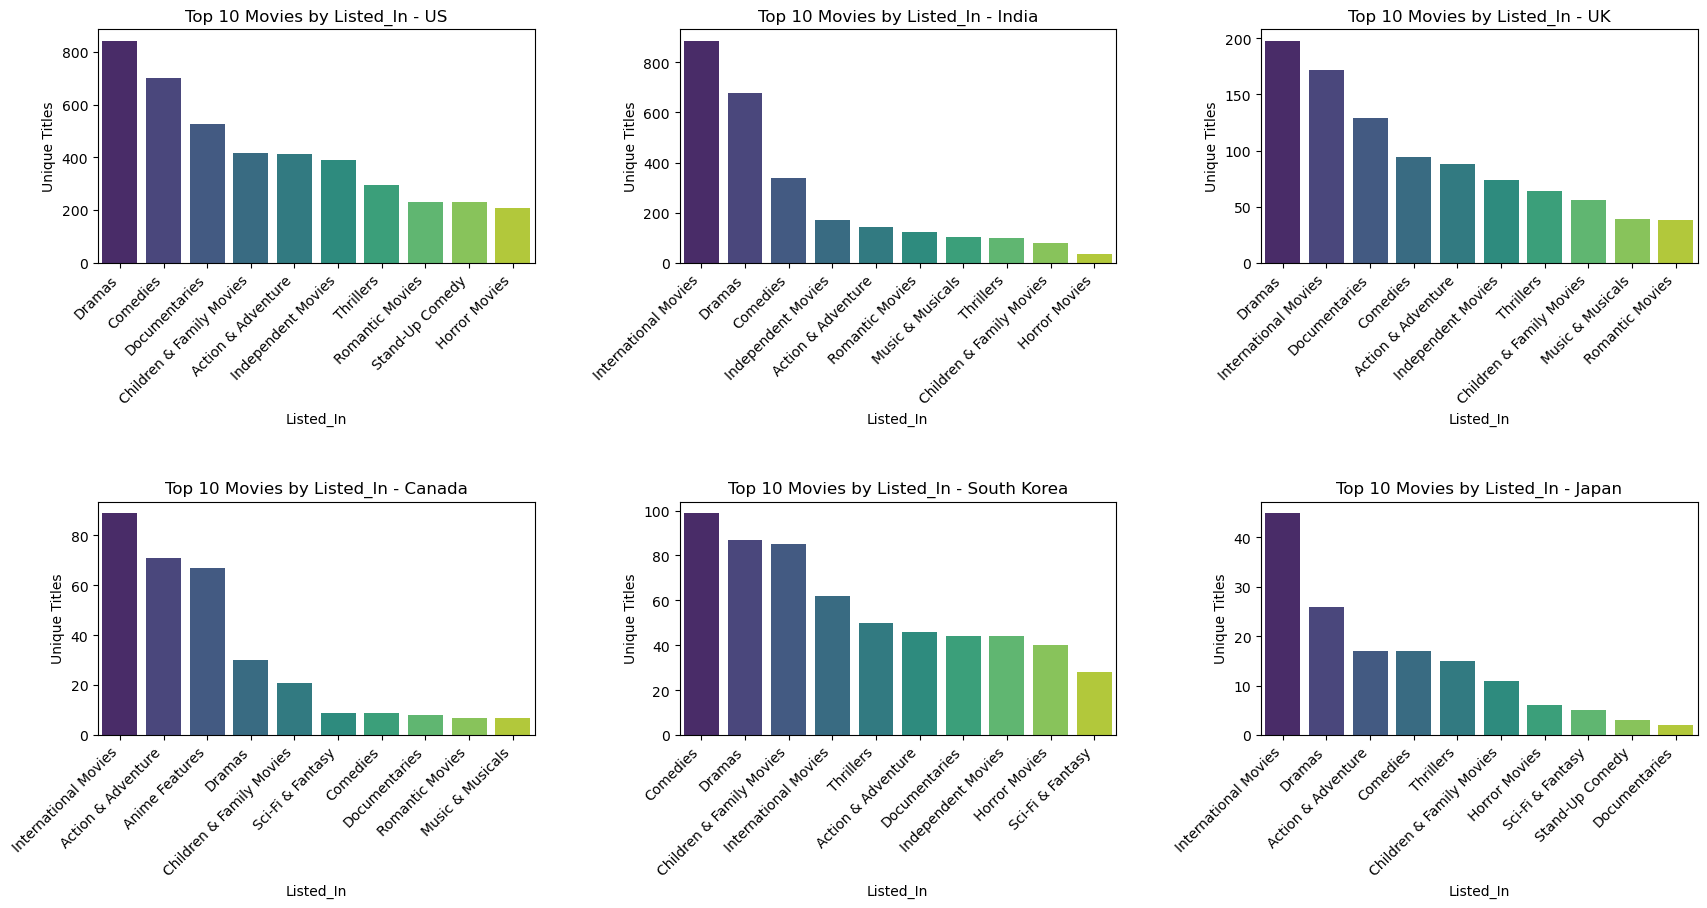

In [142]:
# For movies based on 'listed_in':
Analyze_column_distribution_by_country(df_movies_us, df_movies_in, df_movies_uk,df_movies_ca, df_movies_sk,df_movies_jp, column_name='listed_in', media_type='movies')


## 🎞️ Key Observations by Country (Movies):based on 'listed_in'

### 🇺🇸 United States  
**Top genres**: Dramas (843), Comedies (702), Documentaries (526), Children & Family (417)  
**Trend**: Diverse content mix with high drama and comedy presence  

### 🇮🇳 India  
**Top genres**: International Movies (887), Dramas (677), Comedies (339)  
**Trend**: Large share of globally themed content and local drama  

### UK United Kingdom 
**Top genres**: Dramas (198), International Movies (172), Documentaries (129)  
**Trend**: Preference for informative and global content  

### 🇨🇦 Canada  
**Top genres**: International Movies (89), Action & Adventure (71), Anime Features (67)  
**Trend**: Heavy focus on international titles and niche genres like anime  

### SK South Korea  
**Top genres**: Comedies (99), Dramas (87), Children & Family (85)  
**Trend**: Local mix of lighthearted and family-friendly genres  

### 🇯🇵 Japan  
**Top genres**: International Movies (45), Dramas (26), Action & Adventure (17)  
**Trend**: Modest genre spread, led by imported films  

## 🌐 Cross-Country Trends:
- **Dramas** and **Comedies** are universally popular across countries  
- **International Movies** dominate in India, UK, Canada, and Japan  
- **Documentaries** are strong in US and UK, weaker in Asian regions  
- **Children & Family** movies have consistent but varying presence  
- **Anime** stands out only in Canada  
- **Stand-Up Comedy** mostly popular in the US

US:
                  listed_in  title
14             TV Comedies    268
15               TV Dramas    242
6                 Kids' TV    239
4               Docuseries    202
3           Crime TV Shows    150
8               Reality TV    127
13   TV Action & Adventure     97
5   International TV Shows     85
18     TV Sci-Fi & Fantasy     62
17            TV Mysteries     54 

India:
                  listed_in  title
3   International TV Shows     73
11               TV Dramas     32
10             TV Comedies     30
4                 Kids' TV     20
6        Romantic TV Shows     13
2               Docuseries      9
1           Crime TV Shows      9
5               Reality TV      8
12               TV Horror      7
9    TV Action & Adventure      6 

UK:
                  listed_in  title
1         British TV Shows    229
5   International TV Shows    131
4               Docuseries     91
3           Crime TV Shows     50
13             TV Comedies     44
6                 Kids' TV

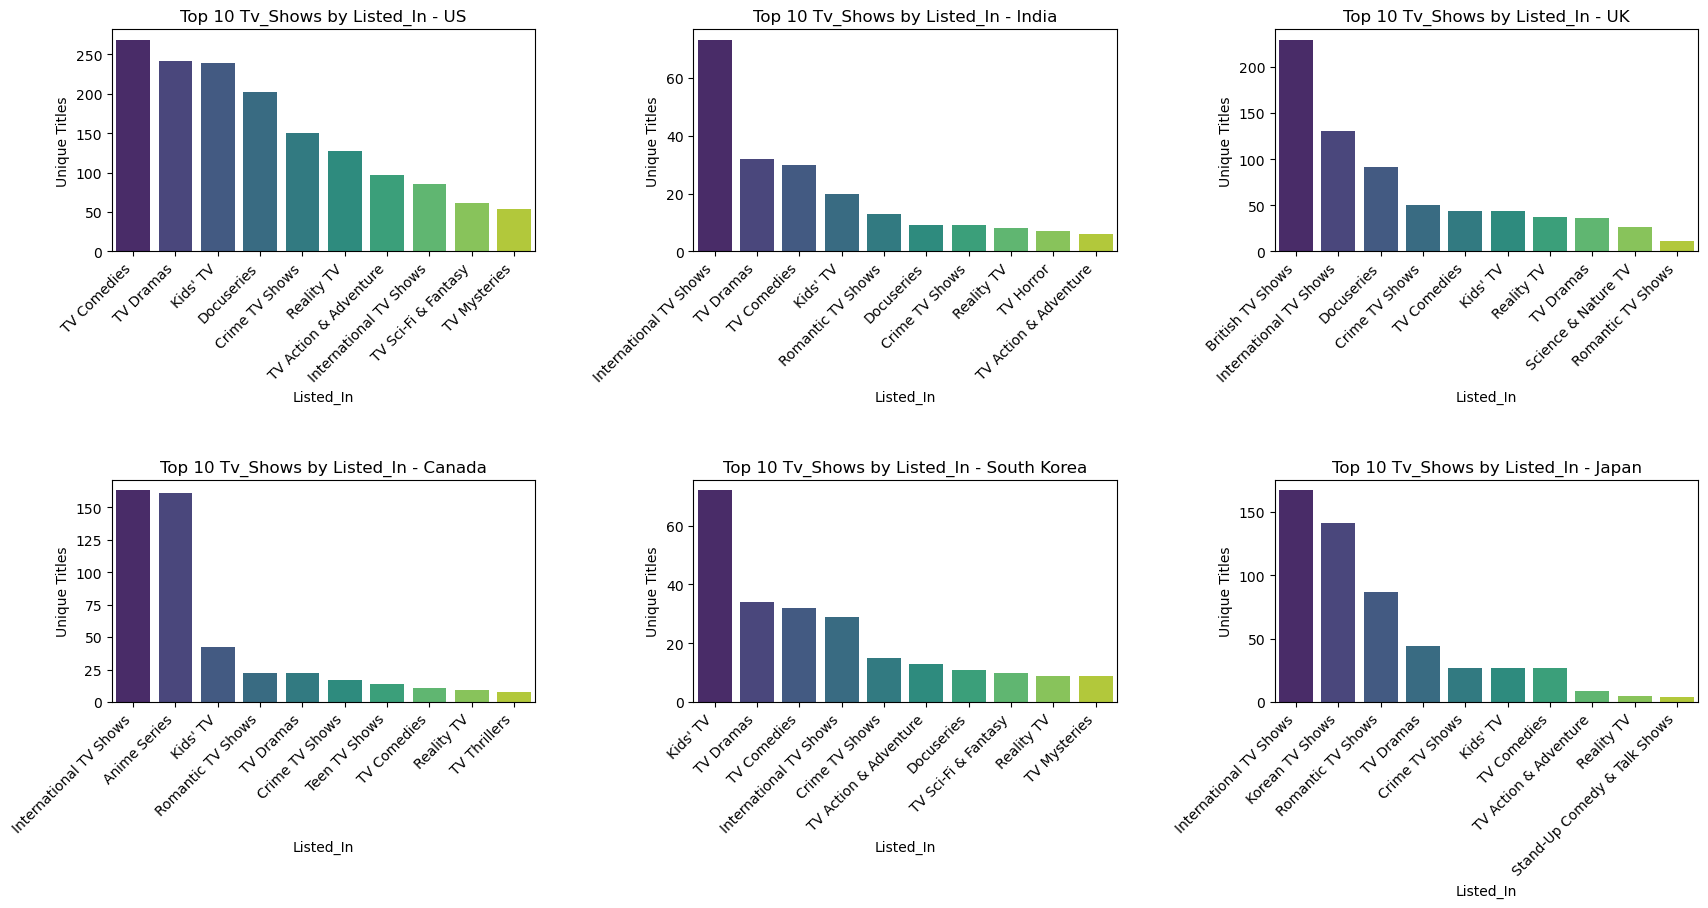

In [144]:
# For TV shows based on 'listed_in':
Analyze_column_distribution_by_country(df_shows_us, df_shows_in, df_shows_uk,df_shows_ca, df_shows_sk,df_shows_jp, column_name='listed_in', media_type='tv_shows')

## 📺 Key Observations by Country (TV Shows):based on 'listed_in'

### 🇺🇸 United States  
**Top genres**: TV Comedies (268), TV Dramas (242), Kids' TV (239), Docuseries (202)  
**Trend**: Strong mix of humor, drama, and family content  

### 🇮🇳 India  
**Top genres**: International TV Shows (73), TV Dramas (32), TV Comedies (30)  
**Trend**: Heavy reliance on international content with a modest domestic variety  

### UK United Kingdom 
**Top genres**: British TV Shows (229), International TV Shows (131), Docuseries (91)  
**Trend**: Strong national content and factual programming  

### 🇨🇦 Canada  
**Top genres**: International TV Shows (163), Anime Series (161), Kids' TV (42)  
**Trend**: Heavy intake of international and animated content  

### SK South Korea  
**Top genres**: Kids' TV (72), TV Dramas (34), TV Comedies (32)  
**Trend**: Family-friendly content paired with drama and comedy  

### 🇯🇵 Japan  
**Top genres**: International TV Shows (167), Korean TV Shows (141), Romantic TV Shows (87)  
**Trend**: Strong cross-cultural influence (esp. Korean shows), romance-centered programming  

## 🌍 Cross-Country Trends:
- **TV Dramas & Comedies** are consistently present across most regions  
- **International TV Shows** dominate in India, UK, Canada, Japan  
- **Kids' TV** ranks high in the US, South Korea, and Canada  
- **Anime** is a standout only in Canada  
- **UK** emphasizes **British TV Shows**, showing national content preference  
- **Japan** features high consumption of **Korean TV Shows**, showing strong cultural crossover

US:
                           cast  title
1954              Grey Griffin     10
5284              Vincent Tong     10
2983  Kevin Michael Richardson      9
2835             Kari Wahlgren      8
2610         Johnny Yong Bosch      7
2875             Kathleen Barr      7
290              Andrea Libman      7
3786               Mike Colter      7
5003               Tara Strong      7
5135                 Tom Kenny      7 

India:
                cast  title
258     Rajesh Kava      5
136   Julie Tejwani      5
352   Sonal Kaushal      4
290    Rupa Bhimani      4
129  Jigna Bhardwaj      4
296    Sabina Malik      3
215   Nishka Raheja      3
250   Radhika Madan      2
366   Supriya Joshi      2
392    Vatsal Dubey      2 

UK:
                     cast  title
280   David Attenborough     13
614          John Cleese      5
391            Eric Idle      5
446       Graham Chapman      5
1227         Terry Jones      5
877        Michael Palin      5
973       Paul Hollywood      5
467    

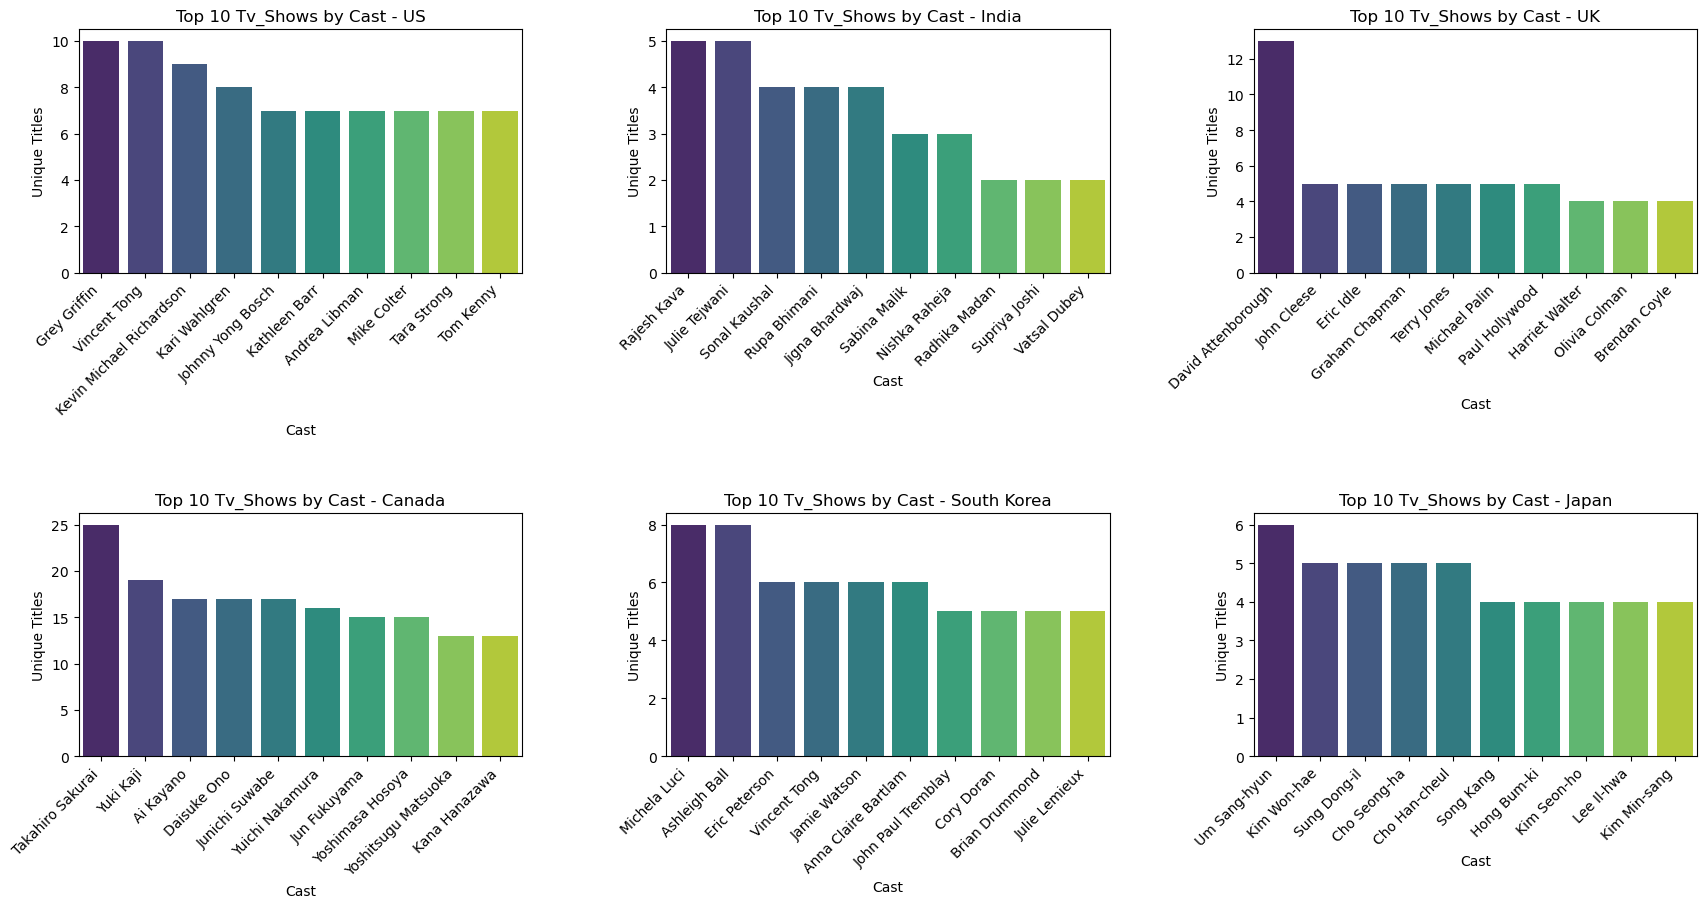

In [146]:
# For tv_shows based on 'cast':
Analyze_column_distribution_by_country(df_shows_us, df_shows_in, df_shows_uk,df_shows_ca, df_shows_sk,df_shows_jp, column_name='cast', media_type='tv_shows',exclude_values=['Unknown Actor'])

## 🎭 Key Observations by Country (TV Shows - Cast):

### 🇺🇸 United States  
**Top voice actors**:  
- Grey Griffin (10), Vincent Tong (10), Kevin Michael Richardson (9), Kari Wahlgren (8)  
**Trend**: Dominance of prolific **voice actors**, mainly from animated/kids’ content  

### 🇮🇳 India  
**Top actors**:  
- Rajesh Kava (5), Julie Tejwani (5), Sonal Kaushal (4), Rupa Bhimani (4)  
**Trend**: **Voice actors** for dubbed or animated shows; minimal celebrity-driven casting  

### UK United Kingdom  
**Top actors**:  
- David Attenborough (13), Monty Python cast (John Cleese, Eric Idle, etc. - 5 each)  
**Trend**: Strong focus on **documentary/narration (Attenborough)** and **classic British comedy**  

### 🇨🇦 Canada  
**Top actors**:  
- Takahiro Sakurai (25), Yuki Kaji (19), Ai Kayano (17), Daisuke Ono (17)  
**Trend**: Dominated by **Japanese voice actors**, reflecting heavy **anime imports**  

### SK South Korea  
**Top actors**:  
- Michela Luci (8), Ashleigh Ball (8), Eric Peterson (6)  
**Trend**: Similar to Canada/US, **voice actors** from animation are prominent  

### 🇯🇵 Japan  
**Top actors**:  
- Um Sang-hyun (6), Kim Won-hae (5), Sung Dong-il (5)  
**Trend**: Heavily features **Korean actors**, indicating strong **K-drama influence** on Japanese TV  

## 🌍 Cross-Country Trends:
- **Voice actors** dominate the charts globally—especially in US, India, Korea, and Canada  
- **Japan & UK** stand out with live-action content featuring either **Korean actors** or **national icons**  
- **Canada**'s top TV shows are overwhelmingly **anime dubbed content**, imported from Japan  
- **UK** and **India** feature **national talents**, but with very modest show counts  

US:
                     cast  title
10028  Samuel L. Jackson     22
109         Adam Sandler     20
4765        James Franco     19
8516        Nicolas Cage     18
3836     Fred Tatasciore     17
2855         David Spade     16
603        Andrea Libman     15
10253         Seth Rogen     15
8204       Molly Shannon     15
1616        Bruce Willis     15 

India:
                   cast  title
365        Anupam Kher     40
2924    Shah Rukh Khan     35
1967  Naseeruddin Shah     32
2110           Om Puri     29
138       Akshay Kumar     29
2160      Paresh Rawal     28
209   Amitabh Bachchan     28
1352     Julie Tejwani     28
2670      Rupa Bhimani     27
647        Boman Irani     27 

UK:
                       cast  title
1319           John Cleese     12
1849         Michael Palin     10
1396            Judi Dench      9
2670         Terry Gilliam      8
1489         Keith Wickham      8
369        Brendan Gleeson      8
1029  Helena Bonham Carter      8
2671           Terry Jon

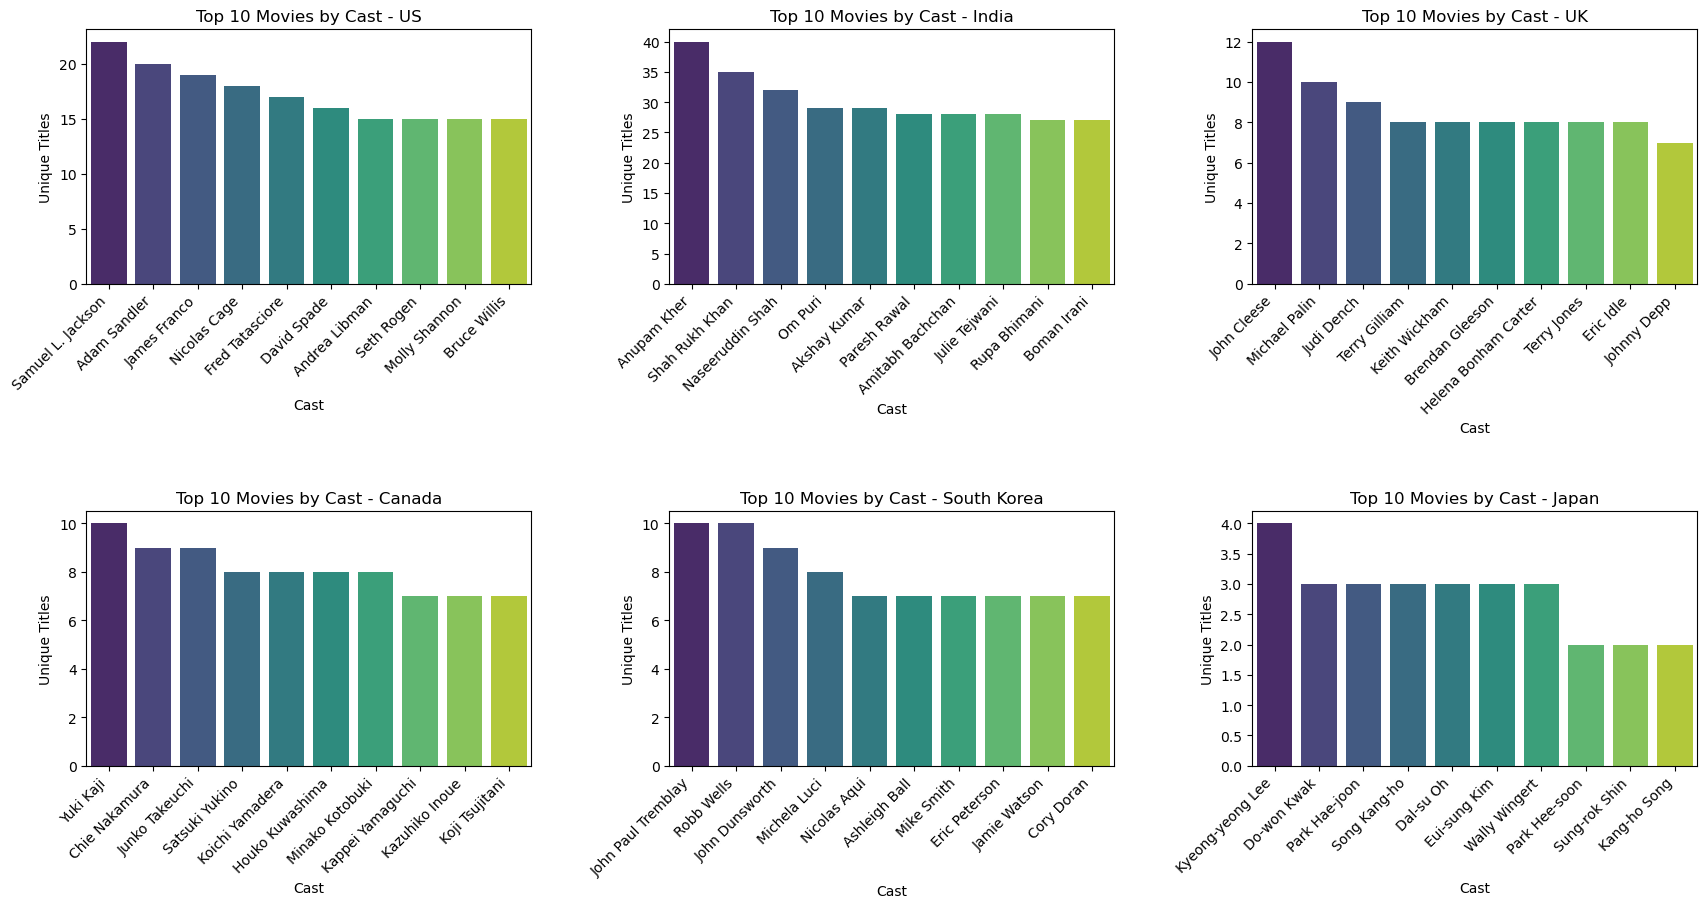

In [148]:
# For movies based on 'cast':
Analyze_column_distribution_by_country(df_movies_us, df_movies_in, df_movies_uk, df_movies_ca, df_movies_sk,df_movies_jp, column_name='cast', media_type='movies',exclude_values=['Unknown Actor'])

## 🎬 Key Observations by Country (Movies - Cast):

### 🇺🇸 United States  
**Top actors**:  
- Samuel L. Jackson (22), Adam Sandler (20), James Franco (19), Nicolas Cage (18)  
**Trend**: **Hollywood legends** and **comedic actors** dominate, with a strong presence of versatile stars like Samuel L. Jackson  

### 🇮🇳 India  
**Top actors**:  
- Anupam Kher (40), Shah Rukh Khan (35), Naseeruddin Shah (32), Om Puri (29)  
**Trend**: Heavy reliance on **Bollywood legends**, with **Shah Rukh Khan** and **Naseeruddin Shah** showcasing their vast cinematic range  

### UK United Kingdom  
**Top actors**:  
- John Cleese (12), Michael Palin (10), Judi Dench (9), Terry Gilliam (8)  
**Trend**: **British comedy and classics**—**Monty Python**'s legacy is prominent, as well as acting royalty like **Judi Dench**  

### 🇨🇦 Canada  
**Top actors**:  
- Yuki Kaji (10), Chie Nakamura (9), Junko Takeuchi (9), Satsuki Yukino (8)  
**Trend**: Similar to TV, **anime voice actors** play a significant role, with **Japanese voice acting** influencing Canada's movie scene  

### SK South Korea  
**Top actors**:  
- John Paul Tremblay (10), Robb Wells (10), John Dunsworth (9)  
**Trend**: Heavy influence from **Canadian comedy** shows (e.g., **Trailer Park Boys** cast)  

### 🇯🇵 Japan  
**Top actors**:  
- Kyeong-yeong Lee (4), Do-won Kwak (3), Park Hae-joon (3), Song Kang-ho (3)  
**Trend**: Primarily **Korean actors** in Japanese movies, indicating cross-national collaboration in the film industry  

## 🌍 Cross-Country Trends:
- **Hollywood stars** (e.g., Samuel L. Jackson, Adam Sandler) dominate the US, with a focus on **action/comedy** genres  
- **Bollywood icons** (e.g., Shah Rukh Khan, Anupam Kher) heavily influence the Indian film industry  
- **UK's Monty Python** cast plays a key role in shaping **British comedy films**  
- **Anime voice actors** from Japan make their mark in **Canadian movie industry**, continuing anime's global influence  
- **South Korea and Japan** show a unique overlap in **cross-border talent**, with **Korean actors** starring in Japanese films  

US:
               director  title
1383      Marcus Raboy     15
918          Jay Karas     15
1429   Martin Scorsese     12
917        Jay Chapman     12
2082  Steven Spielberg     11
587   Don Michael Paul     10
2001   Shannon Hartman      9
1860  Robert Rodriguez      8
1284       Lance Bangs      8
2218       Troy Miller      8 

India:
              director  title
465     Rajiv Chilaka     22
636       Suhas Kadav     16
152      David Dhawan      9
83     Anurag Kashyap      8
683       Umesh Mehra      8
168  Dibakar Banerjee      7
477   Ram Gopal Varma      7
213        Imtiaz Ali      6
252       Karan Johar      6
327     Milan Luthria      6 

UK:
              director  title
205           Joey So      6
119  Edward Cotterill      4
305   Martin Campbell      3
469     Terry Gilliam      3
59      Blair Simmons      3
484        Tom Hooper      3
362      Paul Dugdale      3
196    Jerry Rothwell      3
496    Vince Marcello      3
73         Chris Howe      3 

CA:
    

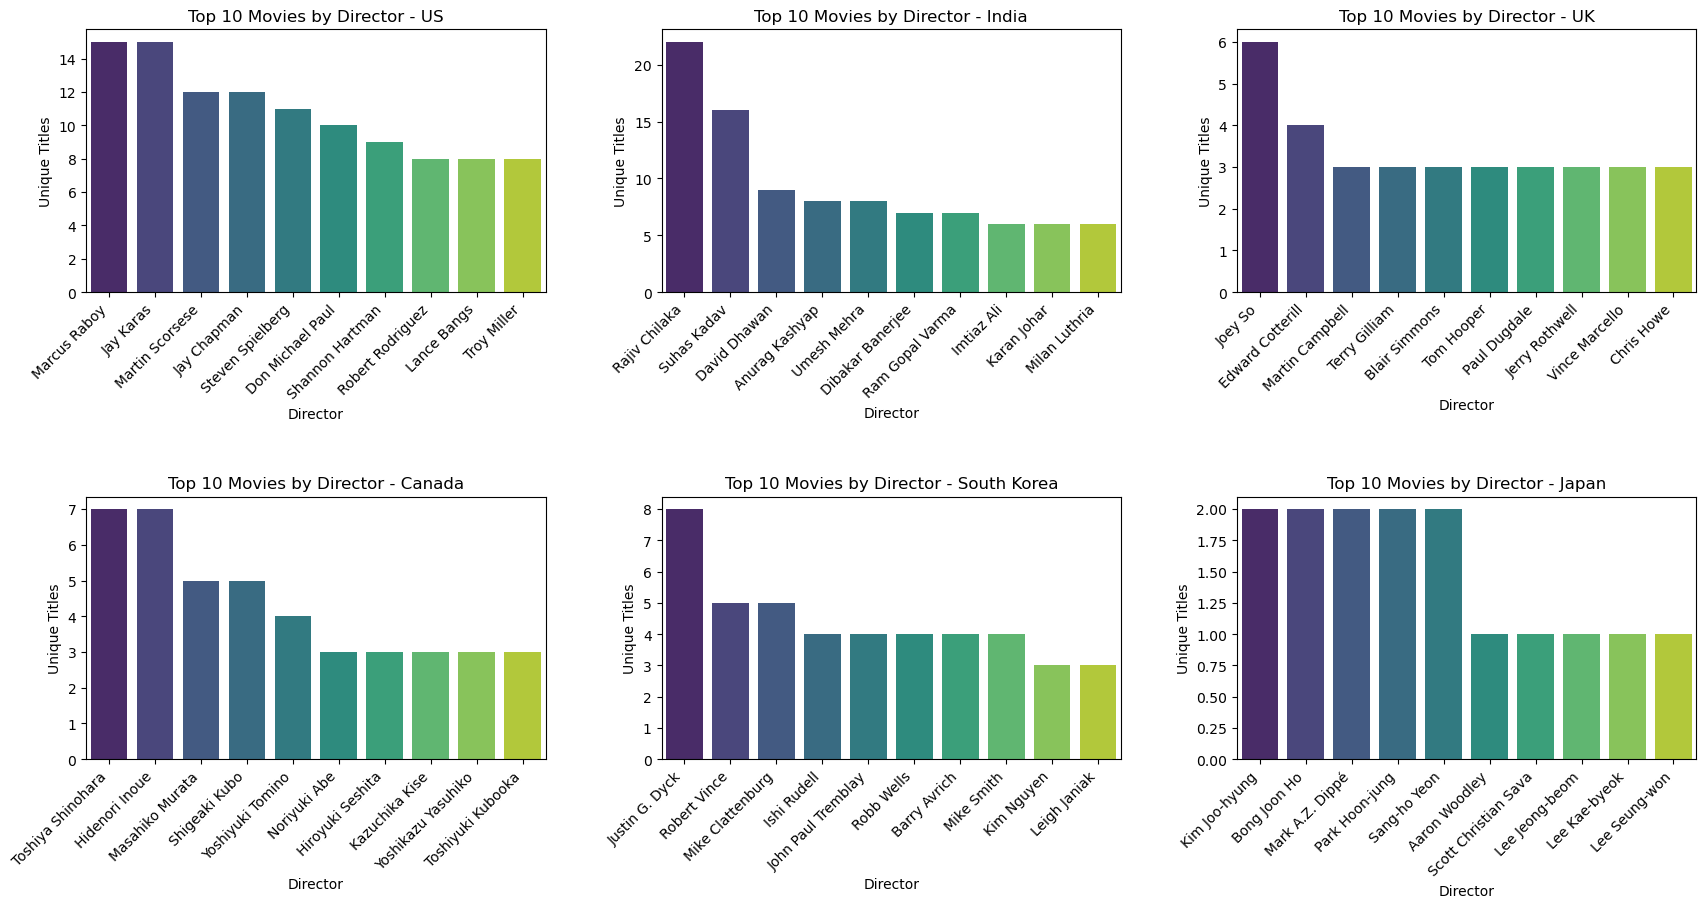

In [150]:
# For movies based on 'Director':
Analyze_column_distribution_by_country(df_movies_us, df_movies_in, df_movies_uk,df_movies_ca, df_movies_sk,df_movies_jp, column_name='director', media_type='movies',exclude_values=['Unknown Director'])

## 🎬 Key Observations by Country (Movies - Director):

### 🇺🇸 United States  
**Top directors**:  
- Marcus Raboy (15), Jay Karas (15), Martin Scorsese (12), Steven Spielberg (11)  
**Trend**: Predominantly **comedy and action directors** in mainstream Hollywood, with big names like **Scorsese** and **Spielberg** for drama and blockbuster films.

### 🇮🇳 India  
**Top directors**:  
- Rajiv Chilaka (22), Suhas Kadav (16), David Dhawan (9), Anurag Kashyap (8)  
**Trend**: **Animation** plays a prominent role with **Rajiv Chilaka**, while **David Dhawan** and **Anurag Kashyap** represent **Bollywood**'s stronghold in both comedy and drama.

### UK United Kingdom  
**Top directors**:  
- Joey So (6), Edward Cotterill (4), Martin Campbell (3), Terry Gilliam (3)  
**Trend**: **Comedy and drama directors** take center stage, with **Terry Gilliam**'s unique style standing out, alongside directors contributing to both small and big screen productions.

### 🇨🇦 Canada  
**Top directors**:  
- Toshiya Shinohara (7), Hidenori Inoue (7), Masahiko Murata (5), Shigeaki Kubo (5)  
**Trend**: **Anime directors** continue to dominate the scene, reinforcing Canada's influence in **Japanese animation** and **anime films**.

### SK South Korea  
**Top directors**:  
- Justin G. Dyck (8), Robert Vince (5), Mike Clattenburg (5), Ishi Rudell (4)  
**Trend**: **Comedy directors** feature prominently in South Korean cinema, with a variety of comedic styles in both local and international productions.

### 🇯🇵 Japan  
**Top directors**:  
- Kim Joo-hyung (2), Bong Joon Ho (2), Mark A.Z. Dippé (2), Park Hoon-jung (2)  
**Trend**: **International directors** such as **Bong Joon Ho** add a global appeal to Japanese films, although most directors listed are more niche or less prolific.

## 🌍 Cross-Country Trends:
- **Hollywood directors** (e.g., Marcus Raboy, Jay Karas) dominate with a focus on **comedy/action** genres.
- **Bollywood directors** like **Rajiv Chilaka** and **David Dhawan** highlight India's strong **animation** and **comedy** influence.
- **UK's** comedy and **Monty Python** legacy influences **British cinema**, while **Terry Gilliam**'s distinct style remains prominent.
- **Canadian anime directors** (e.g., **Toshiya Shinohara**) contribute to the **Japanese animation** influence globally.
- **South Korean and Japanese cinema** shows a cross-border connection, with directors like **Bong Joon Ho** leading international collaborations.

US:
             director  title
48         Ken Burns      3
79       Stan Lathan      2
42     Joe Berlinger      2
73   Rob Seidenglanz      2
55       Lynn Novick      2
66   Peter McDonnell      1
65  Padraic McKinley      1
64    Oscar Micheaux      1
63   Olivier Megaton      1
62      Oliver Stone      1 

India:
                  director  title
12  Gautham Vasudev Menon      2
0        Abhishek Chaubey      1
18            Nizar Shafi      1
20           Priyadarshan      1
21    Rathindran R Prasad      1
22          Sankalp Reddy      1
23                 Sarjun      1
24        Soumendra Padhi      1
25        Srijit Mukherji      1
26          Sudha Kongara      1 

UK:
                director  title
1   Alastair Fothergill      3
0             Alan Poul      1
28          Toby Haynes      1
27      Simon Frederick      1
26          Rachel Bell      1
25   Philippa Lowthorpe      1
24           Noam Murro      1
23      Michael Samuels      1
22      Michael Cumming     

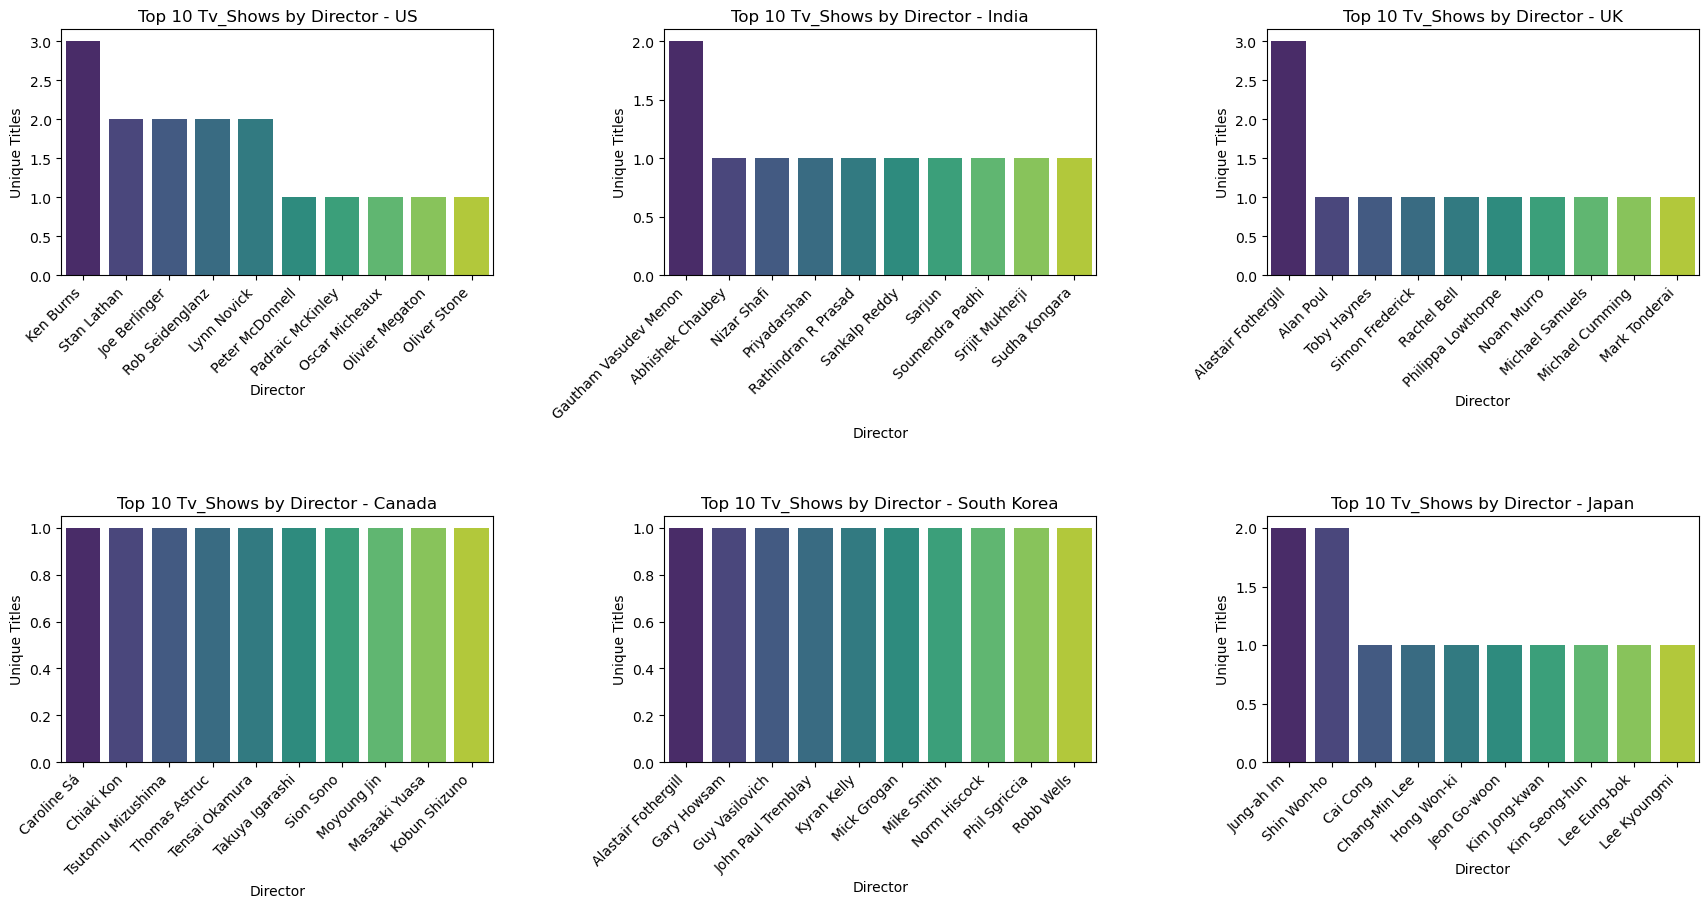

In [152]:
# For tv_shows based on 'Director':
Analyze_column_distribution_by_country(df_shows_us, df_shows_in, df_shows_uk,df_shows_ca, df_shows_sk,df_shows_jp, column_name='director', media_type='tv_shows',exclude_values=['Unknown Director'])

## 🎬 Key Observations by Country (TV Shows - Director):

### 🇺🇸 United States  
**Top directors**:  
- Ken Burns (3), Stan Lathan (2), Joe Berlinger (2), Rob Seidenglanz (2)  
**Trend**: **Documentary and crime** genres dominate, with **Ken Burns** leading in history-based series, and **Stan Lathan** contributing to impactful social commentary.

### 🇮🇳 India  
**Top directors**:  
- Gautham Vasudev Menon (2), Abhishek Chaubey (1), Nizar Shafi (1), Priyadarshan (1)  
**Trend**: **Drama and thriller directors** like **Gautham Vasudev Menon** and **Abhishek Chaubey** contribute to the evolving landscape of **Indian TV shows**.

### UK United Kingdom  
**Top directors**:  
- Alastair Fothergill (3), Alan Poul (1), Toby Haynes (1), Simon Frederick (1)  
**Trend**: **Documentary-style direction** and **British drama** remain prevalent, with **Alastair Fothergill** excelling in nature documentaries.

### 🇨🇦 Canada  
**Top directors**:  
- Caroline Sá (1), Chiaki Kon (1), Tsutomu Mizushima (1), Thomas Astruc (1)  
**Trend**: **International influences** in Canadian TV, especially in **anime and animated shows**, with directors like **Chiaki Kon** contributing to global anime productions.

### SK South Korea  
**Top directors**:  
- Alastair Fothergill (1), Gary Howsam (1), Guy Vasilovich (1), John Paul Tremblay (1)  
**Trend**: **Documentary and animation** influence, with **Alastair Fothergill**'s involvement in global projects crossing borders into **South Korean TV shows**.

### 🇯🇵 Japan  
**Top directors**:  
- Jung-ah Im (2), Shin Won-ho (2), Cai Cong (1), Chang-Min Lee (1)  
**Trend**: **Asian drama and anime** directors, with **Jung-ah Im** and **Shin Won-ho** marking strong contributions to **Japanese TV**.

## 🌍 Cross-Country Trends:
- **US directors** like **Ken Burns** and **Joe Berlinger** continue to lead in **documentary-based TV** series.
- **Indian TV** features **drama and thriller directors** like **Gautham Vasudev Menon**, shaping the evolving content landscape.
- **UK directors** excel in **nature documentaries** and **dramas**, with **Alastair Fothergill** contributing to global recognition.
- **Canadian anime directors**, such as **Chiaki Kon**, show the continued **cross-border influence** of **Japanese animation**.
- **South Korean and Japanese TV** shows benefit from **cross-border collaborations**, with **directors** contributing to **global markets**.

US:
   duration  title
6   80-100   1227
1  100-120    711
5    50-80    452
2  120-150    245
0     1-50    174
3  150-200     37
4  200-315      7 

India:
   duration  title
2  120-150    429
1  100-120    253
3  150-200    155
6   80-100    114
5    50-80     78
0     1-50      8
4  200-315      5 

UK:
   duration  title
6   80-100    213
1  100-120    159
2  120-150     76
5    50-80     65
0     1-50     36
3  150-200     10
4  200-315      3 

CA:
   duration  title
6   80-100     49
1  100-120     38
2  120-150     21
5    50-80     13
0     1-50      7
3  150-200      7
4  200-315      3 

South Korea:
   duration  title
6   80-100    174
1  100-120     88
5    50-80     30
0     1-50     29
2  120-150     18
3  150-200      1
4  200-315      1 

Japan:
   duration  title
2  120-150     23
1  100-120     21
4   80-100     11
3    50-80      7
0     1-50      2 



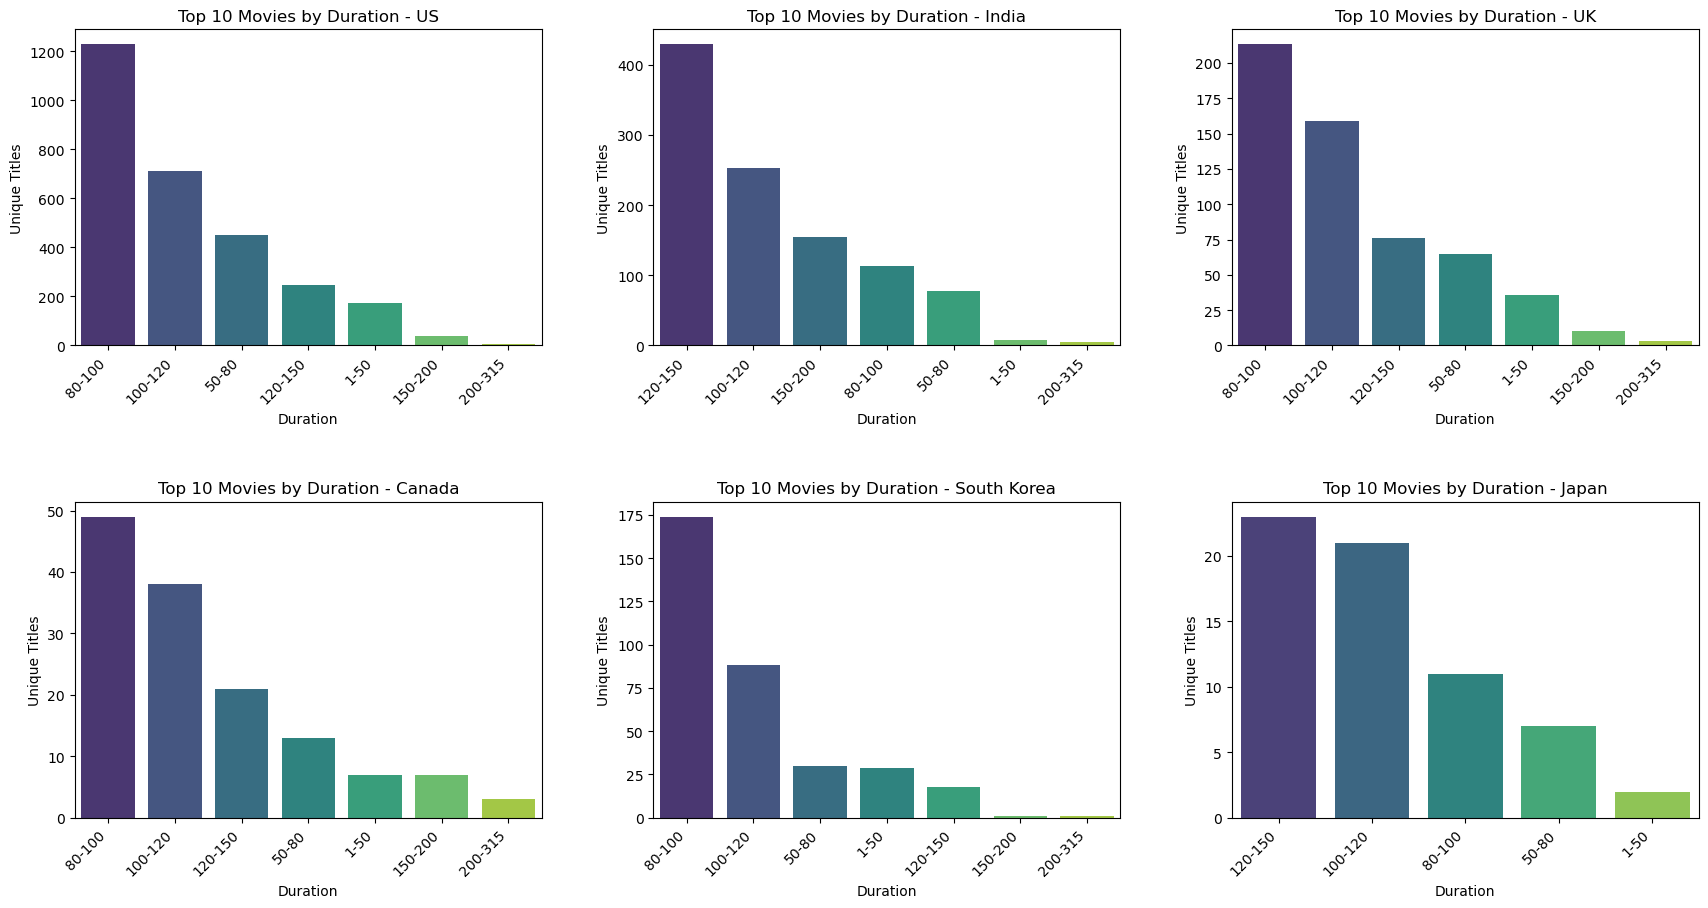

In [154]:
# For movies based on 'duration':
Analyze_column_distribution_by_country(df_movies_us, df_movies_in, df_movies_uk,df_movies_ca, df_movies_sk,df_movies_jp, column_name='duration', media_type='movies',exclude_values=[0])

## 🎬 Key Observations by Country (Movies - Duration):

### 🇺🇸 United States  
**Duration Breakdown**:  
- 80-100 mins (1227), 100-120 mins (711), 50-80 mins (452), 120-150 mins (245)  
**Trend**: **Movies of medium duration (80-120 minutes)** dominate, with a few **longer films (150-200 minutes)** being significantly less frequent.

### 🇮🇳 India  
**Duration Breakdown**:  
- 120-150 mins (429), 100-120 mins (253), 150-200 mins (155), 80-100 mins (114)  
**Trend**: **Longer movies (120-150 mins)** are more common in India, reflecting a preference for longer storytelling in Indian cinema.

### UK United Kingdom  
**Duration Breakdown**:  
- 80-100 mins (213), 100-120 mins (159), 120-150 mins (76), 50-80 mins (65)  
**Trend**: **Shorter movies (80-100 minutes)** dominate, with fewer **longer movies** (120-150 mins).

### 🇨🇦 Canada  
**Duration Breakdown**:  
- 80-100 mins (49), 100-120 mins (38), 120-150 mins (21), 50-80 mins (13)  
**Trend**: Canada follows a similar trend as the UK with a focus on **shorter films (80-100 mins)**.

### SK South Korea  
**Duration Breakdown**:  
- 80-100 mins (174), 100-120 mins (88), 50-80 mins (30), 120-150 mins (18)  
**Trend**: **Shorter movies (80-100 minutes)** are more frequent in South Korea, with a clear preference for **medium-length films**.

### 🇯🇵 Japan  
**Duration Breakdown**:  
- 120-150 mins (23), 100-120 mins (21), 80-100 mins (11), 50-80 mins (7)  
**Trend**: **Longer films (120-150 mins)** are slightly more common in Japan, but the overall distribution suggests a mix of both **medium and shorter films**.

## 🌍 Cross-Country Trends:
- **Medium-length films (80-120 mins)** remain dominant across all countries, with **the US** and **South Korea** having the largest share.
- **India** and **Japan** show a higher preference for **longer films (120-150 mins)**.
- **Canada** and **UK** favor shorter films, with the most frequent duration being **80-100 minutes**.

US:
       duration  title
0     1 Season    544
7    2 Seasons    166
8    3 Seasons    107
9    4 Seasons     66
10   5 Seasons     41
11   6 Seasons     23
12   7 Seasons     19
13   8 Seasons     15
1   10 Seasons      5
14   9 Seasons      4 

India:
     duration  title
0   1 Season     87
1  2 Seasons      7
2  3 Seasons      5
3  4 Seasons      2 

UK:
      duration  title
0    1 Season    171
2   2 Seasons     50
3   3 Seasons     25
4   4 Seasons     14
5   5 Seasons     12
6   6 Seasons      3
7   9 Seasons      3
1  10 Seasons      2 

CA:
     duration  title
0   1 Season    148
1  2 Seasons     53
2  3 Seasons     14
3  4 Seasons      4
4  5 Seasons      4
5  6 Seasons      3
6  9 Seasons      1 

South Korea:
       duration  title
0     1 Season     56
5    2 Seasons     39
6    3 Seasons     18
8    5 Seasons      9
7    4 Seasons      8
9    6 Seasons      3
1   10 Seasons      2
2   12 Seasons      2
10   7 Seasons      2
3   13 Seasons      1 

Japan:
     duration

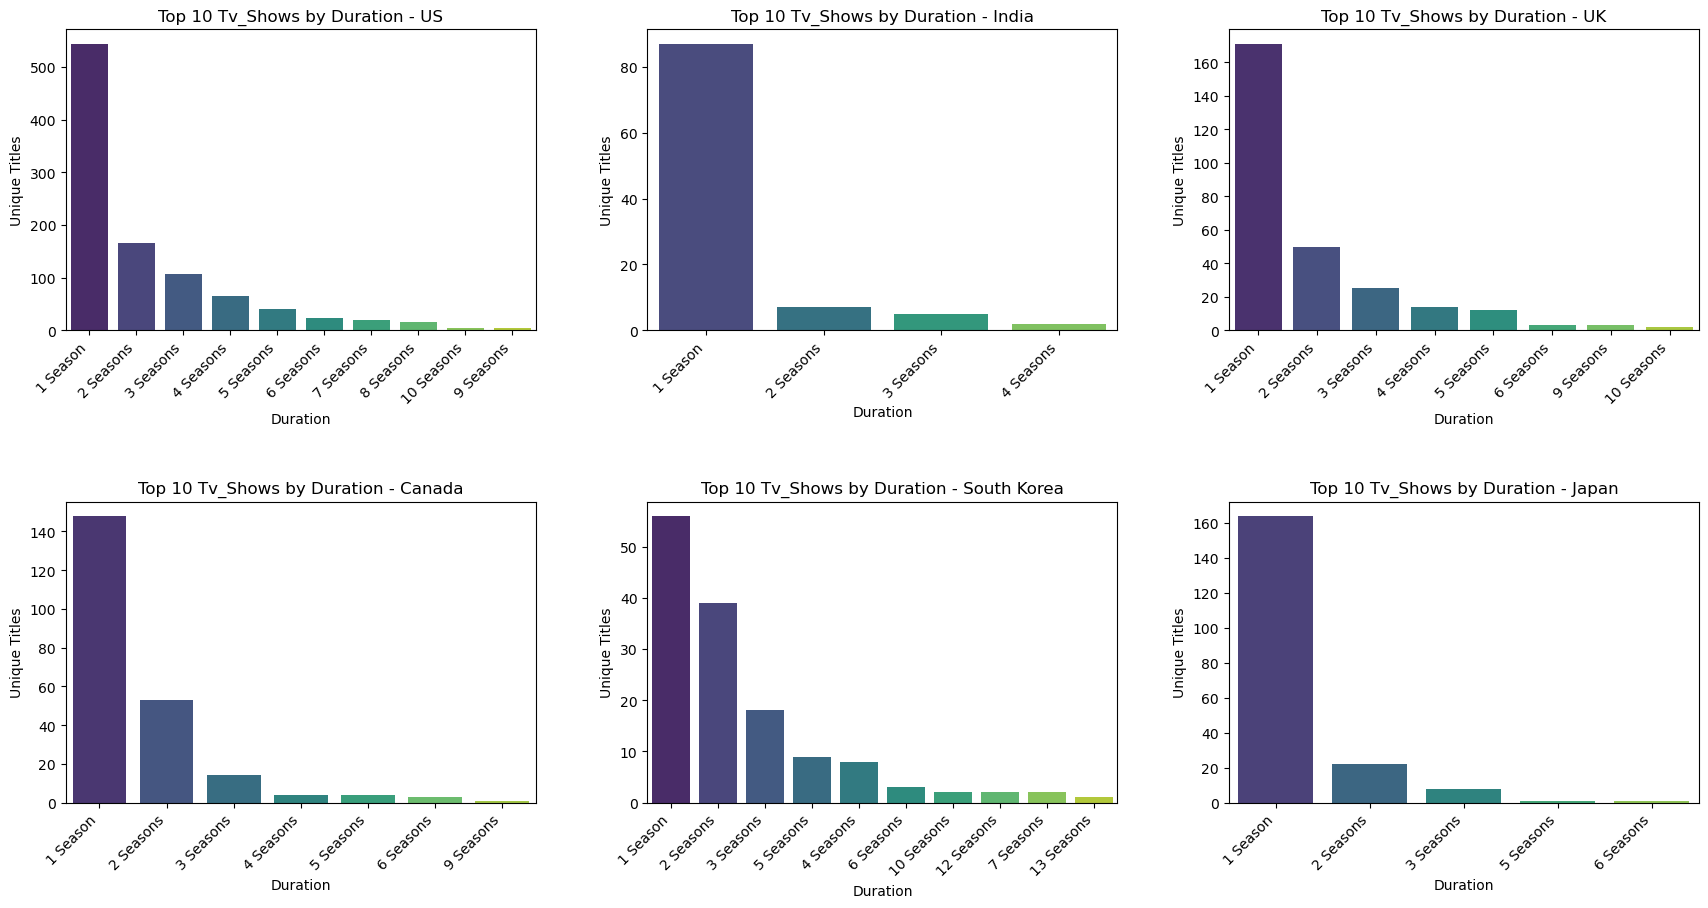

In [156]:
# For tv_shows based on 'Director':
Analyze_column_distribution_by_country(df_shows_us, df_shows_in, df_shows_uk,df_shows_ca, df_shows_sk,df_shows_jp, column_name='duration', media_type='tv_shows',exclude_values=[0])

## 📺 Key Observations by Country (TV Shows - Duration):

### 🇺🇸 United States  
**Duration Breakdown**:  
- 1 Season (544), 2 Seasons (166), 3 Seasons (107), 4 Seasons (66), 5 Seasons (41), 6 Seasons (23), 7 Seasons (19), 8 Seasons (15)
**Trend**: **1-season shows** are by far the most common, but **shows with multiple seasons** (up to 4) also appear frequently.

### 🇮🇳 India  
**Duration Breakdown**:  
- 1 Season (87), 2 Seasons (7), 3 Seasons (5), 4 Seasons (2)  
**Trend**: A **preference for 1-season shows**, with only a few series going beyond that (2-4 seasons).
  
### UK United Kingdom  
**Duration Breakdown**:  
- 1 Season (171), 2 Seasons (50), 3 Seasons (25), 4 Seasons (14), 5 Seasons (12), 6 Seasons (3), 9 Seasons (3), 10 Seasons (2)  
**Trend**: A dominant share of **1-season TV shows**, but a range of series with **up to 5 seasons** is also present.

### 🇨🇦 Canada  
**Duration Breakdown**:  
- 1 Season (148), 2 Seasons (53), 3 Seasons (14), 4 Seasons (4), 5 Seasons (4), 6 Seasons (3), 9 Seasons (1)  
**Trend**: A majority of shows are **1-season** series, with **up to 6 seasons** for a few others.

### SK South Korea  
**Duration Breakdown**:  
- 1 Season (56), 2 Seasons (39), 3 Seasons (18), 5 Seasons (9), 4 Seasons (8), 6 Seasons (3), 10 Seasons (2), 12 Seasons (2)
**Trend**: The **1-season** series dominates, but a significant number of **multi-season shows** (up to 13 seasons) are present in South Korea.

### 🇯🇵 Japan  
**Duration Breakdown**:  
- 1 Season (164), 2 Seasons (22), 3 Seasons (8), 5 Seasons (1), 6 Seasons (1)  
**Trend**: **1-season shows** are the most common, followed by a few multi-season series (2-3 seasons).

## 🌍 Cross-Country Trends:
- **1-season TV shows** are by far the most popular across all countries.
- **Shorter TV shows (1-3 seasons)** dominate, with a few countries (e.g., South Korea, UK, and Canada) showcasing a broader range of shows with up to 10 or more seasons.
- **India** has a much smaller share of multi-season shows, primarily favoring **1-season shows**.

In [158]:
def Analyze_column_trends_by_country(df_us, df_in, df_uk, df_sk, df_jp,df_ca, column_name, media_type, exclude_values=None):
    def clean_df(df):
        df_clean = df.dropna(subset=[column_name])
        if exclude_values:
            df_clean = df_clean[~df_clean[column_name].isin(exclude_values)]
        return df_clean

    # Clean all five country DataFrames
    df_us = clean_df(df_us)
    df_in = clean_df(df_in)
    df_uk = clean_df(df_uk)
    df_ca = clean_df(df_ca)
    df_sk = clean_df(df_sk)
    df_jp = clean_df(df_jp)

    # Group by column_name and count unique titles
    us_column_counts = df_us.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10)
    in_column_counts = df_in.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10)
    uk_column_counts = df_uk.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10)
    ca_column_counts = df_ca.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10)
    sk_column_counts = df_sk.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10)
    jp_column_counts = df_jp.groupby(column_name)['title'].nunique().reset_index(name='title').sort_values('title', ascending=False).head(10)

    # Set up color palettes
    viridis_palette_us = sns.color_palette("viridis", len(us_column_counts))
    viridis_palette_in = sns.color_palette("viridis", len(in_column_counts))
    viridis_palette_uk = sns.color_palette("viridis", len(uk_column_counts))
    viridis_palette_ca = sns.color_palette("viridis", len(ca_column_counts))
    viridis_palette_sk = sns.color_palette("viridis", len(sk_column_counts))
    viridis_palette_jp = sns.color_palette("viridis", len(jp_column_counts))

    # Print counts (optional)
    print("US:\n", us_column_counts, "\n")
    print("India:\n", in_column_counts, "\n")
    print("UK:\n", uk_column_counts, "\n")
    print("Camada:\n", ca_column_counts, "\n")
    print("South Korea:\n", sk_column_counts, "\n")
    print("Japan:\n", jp_column_counts, "\n")


    # Plotting
    plt.figure(figsize=(18, 10))
    
    # US Trend Plot
    plt.subplot(2, 3, 1)
    sns.lineplot(data=us_column_counts, x=column_name, y='title', marker='o')
    plt.title(f'{media_type.title()} Trend by {column_name.title()} - US')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())
    
    # India Trend Plot
    plt.subplot(2, 3, 2)
    sns.lineplot(data=in_column_counts, x=column_name, y='title', marker='o')
    plt.title(f'{media_type.title()} Trend by {column_name.title()} - India')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())
    
    # UK Trend Plot
    plt.subplot(2, 3, 3)
    sns.lineplot(data=uk_column_counts, x=column_name, y='title', marker='o')
    plt.title(f'{media_type.title()} Trend by {column_name.title()} - UK')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())

    # Canada Trend Plot
    plt.subplot(2, 3, 4)
    sns.lineplot(data=ca_column_counts, x=column_name, y='title', marker='o')
    plt.title(f'{media_type.title()} Trend by {column_name.title()} - Canada')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())
    
    # South Korea Trend Plot
    plt.subplot(2, 3, 5)
    sns.lineplot(data=sk_column_counts, x=column_name, y='title', marker='o')
    plt.title(f'{media_type.title()} Trend by {column_name.title()} - South Korea')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())
    
    # Japan Trend Plot
    plt.subplot(2, 3, 6)
    sns.lineplot(data=jp_column_counts, x=column_name, y='title', marker='o')
    plt.title(f'{media_type.title()} Trend by {column_name.title()} - Japan')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Unique Titles')
    plt.xlabel(column_name.title())
    
    plt.tight_layout(pad=4.0)
    plt.show()

US:
     release_year  title
37          2020    196
36          2019    165
35          2018    151
38          2021    124
34          2017     88
33          2016     67
32          2015     43
31          2014     24
30          2013     16
29          2012     15 

India:
     release_year  title
9           2018     19
10          2019     18
11          2020     18
12          2021     12
6           2015     10
4           2013      5
5           2014      5
1           2010      4
8           2017      4
3           2012      2 

UK:
     release_year  title
20          2017     38
23          2020     37
21          2018     36
19          2016     31
22          2019     29
24          2021     26
18          2015     22
17          2014     10
16          2013     10
15          2012      9 

Camada:
     release_year  title
25          2018     37
26          2019     27
24          2017     23
28          2021     22
27          2020     21
23          2016     15
21     

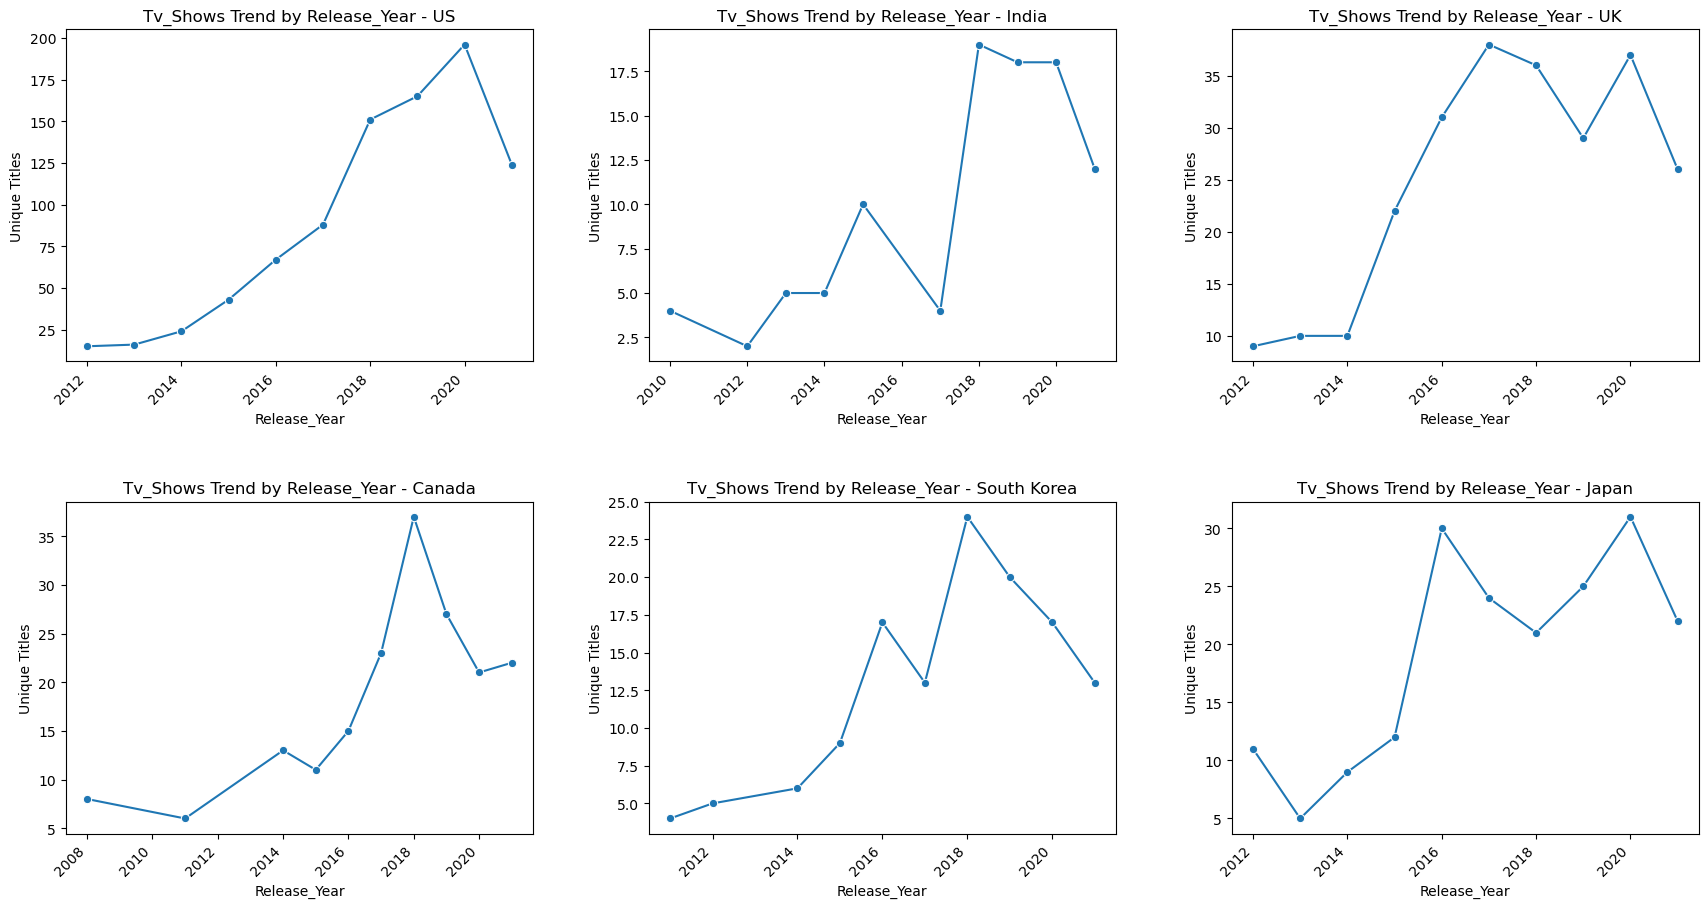

In [160]:
Analyze_column_trends_by_country(df_shows_us, df_shows_in, df_shows_uk,df_shows_ca, df_shows_sk,df_shows_jp, column_name='release_year', media_type='tv_shows')

## 📺 Key Observations by Country (TV Shows - Release Year):

### 🇺🇸 United States  
**Release Year Breakdown**:  
- 2020 (196), 2019 (165), 2018 (151), 2021 (124), 2017 (88), 2016 (67), 2015 (43), 2014 (24), 2013 (16), 2012 (15)  
**Trend**: A peak in **2020**, followed by **2019** and **2018**. **2021** still shows a solid number, indicating a steady influx of content even in the post-2020 era.

### 🇮🇳 India  
**Release Year Breakdown**:  
- 2018 (19), 2019 (18), 2020 (18), 2021 (12), 2015 (10), 2013 (5), 2014 (5), 2010 (4), 2017 (4), 2012 (2)  
**Trend**: The release years are more concentrated around **2018-2021**, with a smaller number of older TV shows from **2010 to 2017**.

### UK United Kingdom  
**Release Year Breakdown**:  
- 2017 (38), 2020 (37), 2018 (36), 2016 (31), 2019 (29), 2021 (26), 2015 (22), 2014 (10), 2013 (10), 2012 (9)  
**Trend**: The UK follows a similar trend with **2017-2021** dominating, and **2020** seeing a significant number of releases.

### 🇨🇦 Canada  
**Release Year Breakdown**:  
- 2018 (37), 2019 (27), 2017 (23), 2021 (22), 2020 (21), 2016 (15), 2014 (13), 2015 (11), 2008 (8), 2011 (6)  
**Trend**: The **2018** and **2019** years lead in releases, while older years like **2008** and **2011** are relatively sparse.

### SK South Korea  
**Release Year Breakdown**:  
- 2018 (24), 2019 (20), 2020 (17), 2016 (17), 2021 (13), 2017 (13), 2015 (9), 2014 (6), 2012 (5), 2011 (4)  
**Trend**: South Korea's trend is quite similar to other regions, with a solid representation from **2018-2021** and fewer shows from older years.

### 🇯🇵 Japan  
**Release Year Breakdown**:  
- 2020 (31), 2016 (30), 2019 (25), 2017 (24), 2021 (22), 2018 (21), 2015 (12), 2012 (11), 2014 (9), 2013 (5)  
**Trend**: A peak in **2020**, along with significant releases in **2016**, **2019**, and **2017**. Older shows (2012-2014) are fewer in number.

## 🌍 Cross-Country Trends:
- **2020** stands out as the most popular year across most countries for TV show releases.
- **2019** and **2018** are also prominent, showing a consistent release cycle from 2018 onward in most regions.
- Older shows (pre-2015) are less frequent, with exceptions in the **UK and Japan** for a few releases from 2013 and 2014.
- **2021** shows a steady number of releases in all countries, indicating the continuation of TV production post-pandemic.

US:
     release_year  title
64          2017    366
65          2018    328
63          2016    287
66          2019    276
67          2020    213
62          2015    173
61          2014    118
68          2021    106
60          2013     96
59          2012     87 

India:
     release_year  title
52          2017    115
53          2018    102
54          2019     88
51          2016     80
55          2020     67
48          2013     64
50          2015     63
49          2014     54
47          2012     43
45          2010     41 

UK:
     release_year  title
38          2016     72
40          2018     64
39          2017     63
37          2015     47
41          2019     44
42          2020     37
36          2014     36
43          2021     24
35          2013     20
31          2009     15 

Camada:
     release_year  title
24          2017     20
26          2019     16
25          2018     16
23          2016     12
27          2020      9
28          2021      8
20     

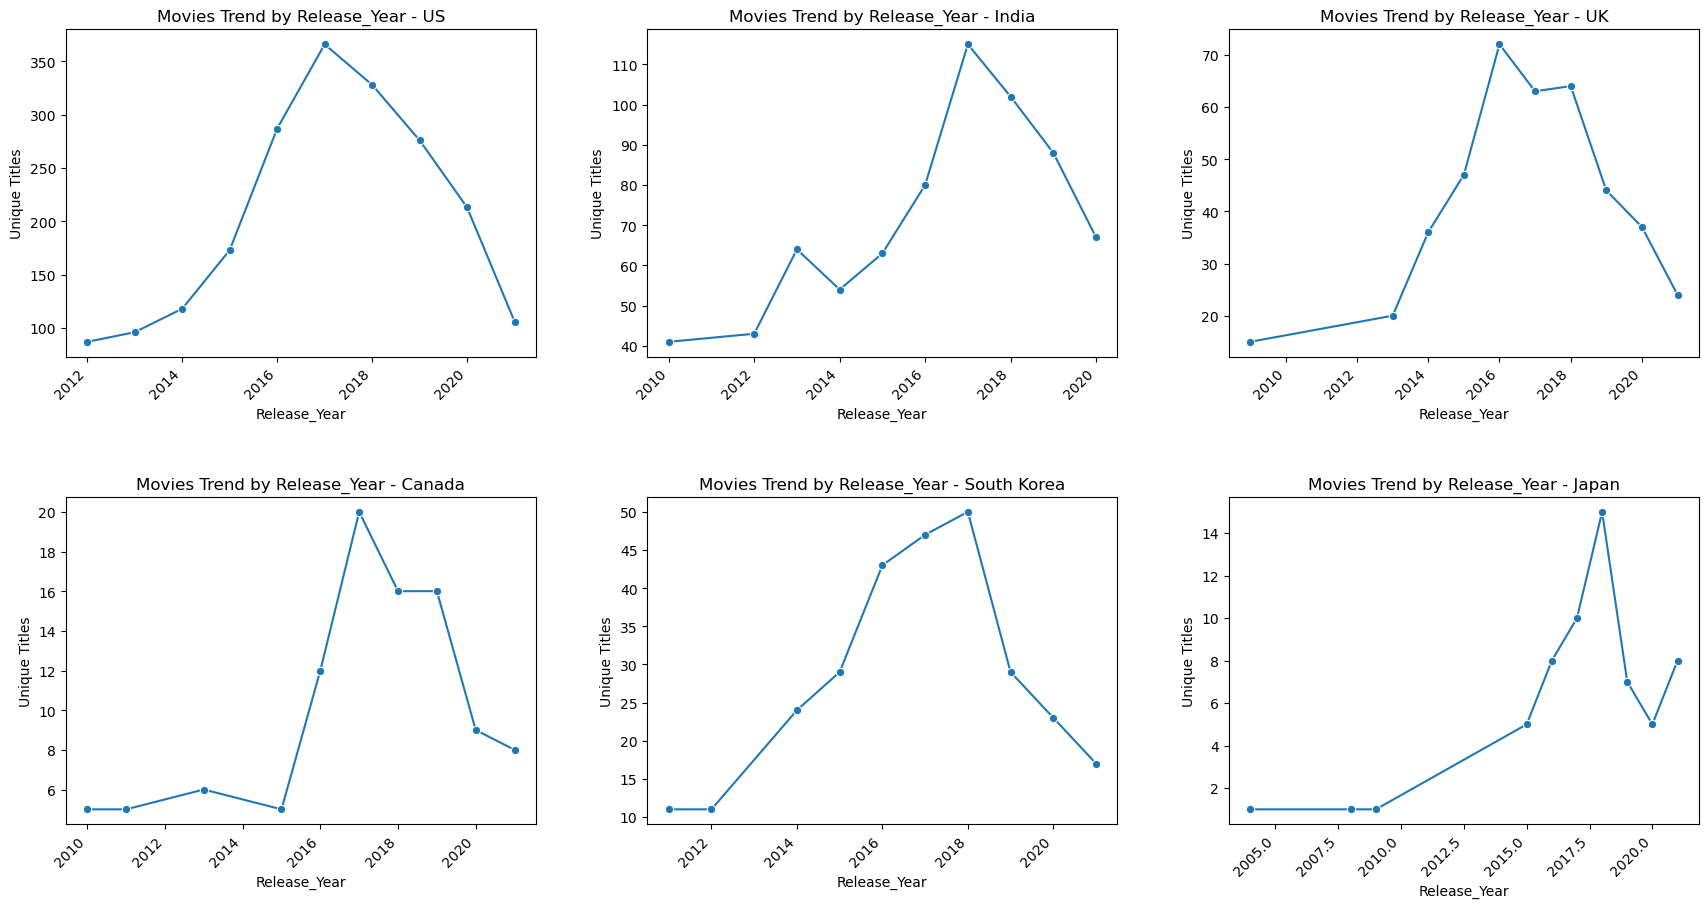

In [162]:
# For movies based on 'release_year':
Analyze_column_trends_by_country(df_movies_us, df_movies_in, df_movies_uk,df_movies_ca, df_movies_sk,df_movies_jp, column_name='release_year', media_type='movies')

## 🍿 Key Observations by Country (Movies - Release Year):

### 🇺🇸 United States  
**Release Year Breakdown**:  
- 2017 (366), 2018 (328), 2016 (287), 2019 (276), 2020 (213), 2015 (173), 2014 (118), 2021 (106), 2013 (96), 2012 (87)  
**Trend**: The release years are primarily concentrated around **2017-2020**, with a sharp drop-off in **2021**, though it still retains a decent number of releases. The number of releases decreases steadily from **2017** to **2021**.

### 🇮🇳 India  
**Release Year Breakdown**:  
- 2017 (115), 2018 (102), 2019 (88), 2016 (80), 2020 (67), 2013 (64), 2015 (63), 2014 (54), 2012 (43), 2010 (41)  
**Trend**: **2017-2019** dominate with **2020** also showing significant releases, though **2021** seems sparse in comparison.

### UK United Kingdom  
**Release Year Breakdown**:  
- 2016 (72), 2018 (64), 2017 (63), 2015 (47), 2019 (44), 2020 (37), 2014 (36), 2021 (24), 2013 (20), 2009 (15)  
**Trend**: A peak in **2017** and **2018** with fewer releases in the subsequent years. **2020-2021** show a declining trend, although **2016** and **2015** still have a solid presence.

### 🇨🇦 Canada  
**Release Year Breakdown**:  
- 2017 (20), 2019 (16), 2018 (16), 2016 (12), 2020 (9), 2021 (8), 2013 (6), 2011 (5), 2015 (5), 2010 (5)  
**Trend**: Fewer releases, with the most prominent years being **2017-2019**, followed by a drop-off in **2020-2021**. Canada has fewer releases in general compared to other countries.

### SK South Korea  
**Release Year Breakdown**:  
- 2018 (50), 2017 (47), 2016 (43), 2019 (29), 2015 (29), 2014 (24), 2020 (23), 2021 (17), 2012 (11), 2011 (11)  
**Trend**: A major peak in **2018** and **2017**, with consistent releases in **2016-2021**. **2021** saw fewer releases, but **2015** and **2019** remained strong.

### 🇯🇵 Japan  
**Release Year Breakdown**:  
- 2018 (15), 2017 (10), 2016 (8), 2021 (8), 2019 (7), 2015 (5), 2020 (5), 2004 (1), 2008 (1), 2009 (1)  
**Trend**: The releases are minimal, with **2018** leading, followed by **2017** and **2016**. **2020-2021** show lower numbers, with sporadic releases from the early 2000s.

## 🌍 Cross-Country Trends:
- **2017** appears as the peak year for the US, India, and South Korea.
- **2018** and **2019** are significant years across multiple countries.
- There is a noticeable decrease in movie releases from **2020** onward, likely due to global disruptions such as the pandemic.
- Older years (pre-2016) have fewer releases across all countries, with **2009 and 2004** being exceptional outliers for Japan.


US:
    year_added  title
8        2020    257
9        2021    199
7        2019    183
6        2018    157
5        2017    106
4        2016     70
3        2015     16
1        2013      5
2        2014      4
0        2008      1 

India:
    year_added  title
1        2018     26
3        2020     22
4        2021     20
2        2019     19
0        2017     14 

UK:
    year_added  title
5        2019     62
3        2017     53
6        2020     51
4        2018     45
7        2021     41
2        2016     22
1        2015      5
0        2013      1 

Camada:
    year_added  title
5        2020     54
4        2019     51
6        2021     41
3        2018     35
1        2016     25
2        2017     20
0        2015      1 

South Korea:
    year_added  title
6        2020     31
5        2019     26
4        2018     24
7        2021     24
3        2017     18
2        2016     15
1        2015      3
0        2014      2 

Japan:
    year_added  title
4        2019    

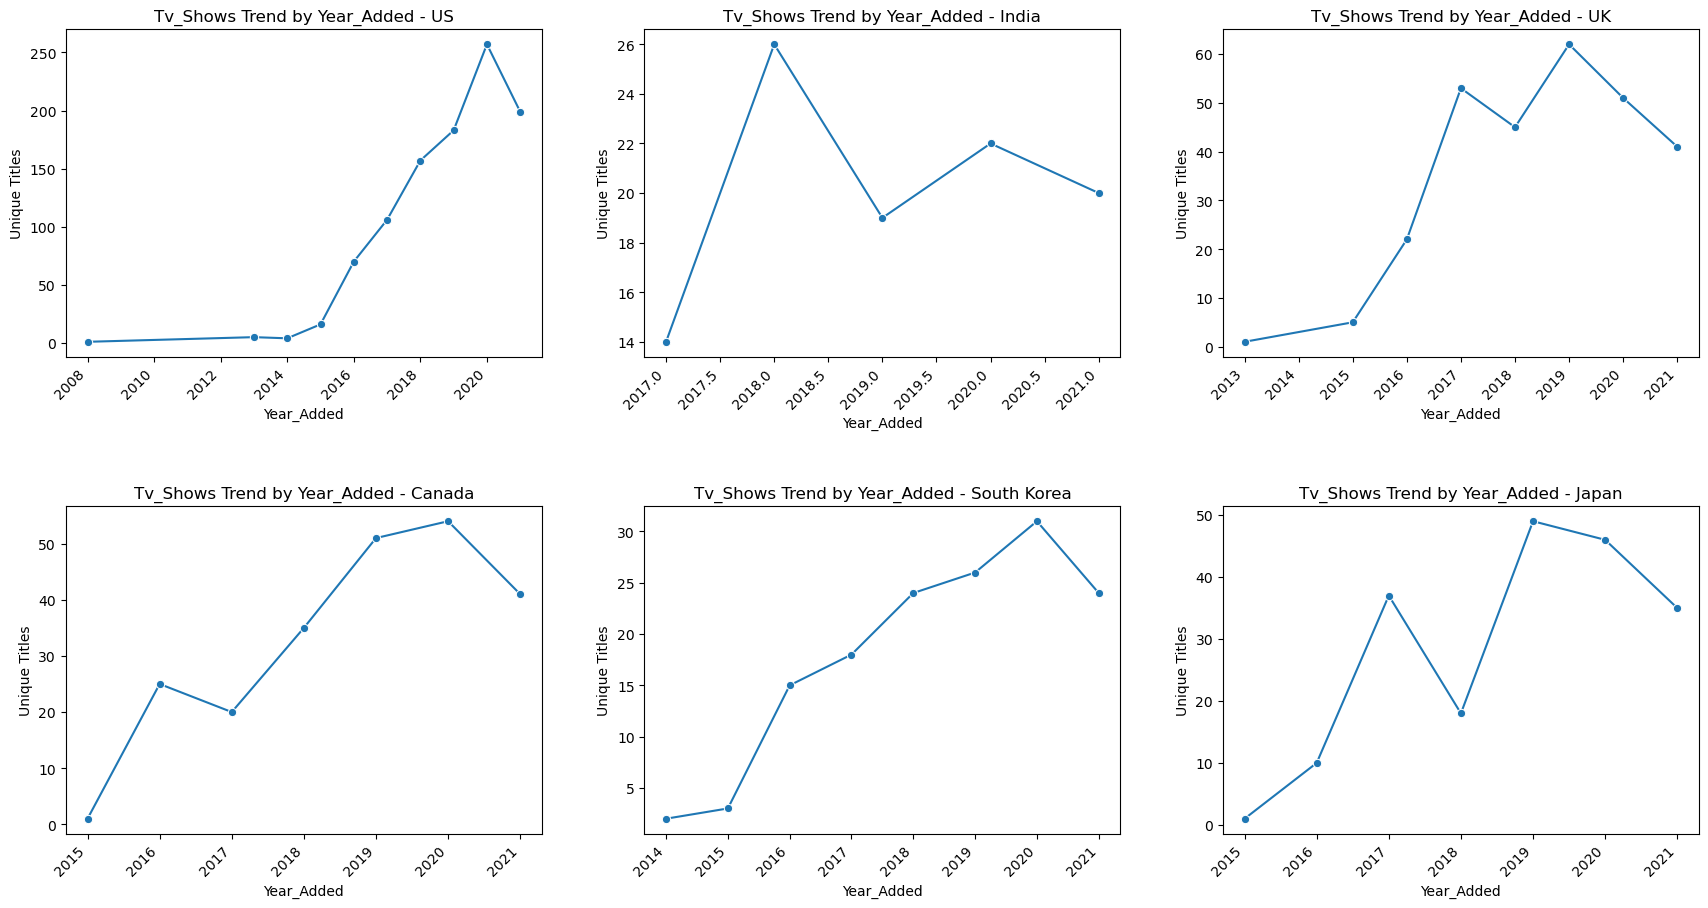

In [164]:
# For tv_shows based on 'year_added':
Analyze_column_trends_by_country(df_shows_us, df_shows_in, df_shows_uk,df_shows_ca, df_shows_sk,df_shows_jp, column_name='year_added', media_type='tv_shows')

## 📺 Key Observations by Country (TV Shows - Year Added):

### 🇺🇸 United States  
**Year Added Breakdown**:  
- 2020 (257), 2021 (199), 2019 (183), 2018 (157), 2017 (106), 2016 (70), 2015 (16), 2013 (5), 2014 (4), 2008 (1)  
**Trend**: The years **2020** and **2021** have a significant surge in TV show additions, with **2020** being the peak year. The number of shows in earlier years like **2015** and **2013** is quite low.

### 🇮🇳 India  
**Year Added Breakdown**:  
- 2018 (26), 2020 (22), 2021 (20), 2019 (19), 2017 (14)  
**Trend**: The highest number of TV shows were added in **2018**, followed by steady additions in **2020** and **2021**, with a decline in earlier years.

### UK United Kingdom  
**Year Added Breakdown**:  
- 2019 (62), 2017 (53), 2020 (51), 2018 (45), 2021 (41), 2016 (22), 2015 (5), 2013 (1)  
**Trend**: The most significant years for TV show additions in the UK were **2019** and **2017**, followed by a relatively stable range of shows added in **2018-2021**.

### 🇨🇦 Canada  
**Year Added Breakdown**:  
- 2020 (54), 2019 (51), 2021 (41), 2018 (35), 2016 (25), 2017 (20), 2015 (1)  
**Trend**: **2020** saw the highest number of additions, closely followed by **2019**. Canada shows a pattern of steady additions over the past few years with a sharp drop in earlier years.

### SK South Korea  
**Year Added Breakdown**:  
- 2020 (31), 2019 (26), 2018 (24), 2021 (24), 2017 (18), 2016 (15), 2015 (3), 2014 (2)  
**Trend**: **2020** is the peak year for South Korea, with a fairly consistent number of shows added in the following years, including **2019** and **2021**. Earlier years show fewer additions.

### 🇯🇵 Japan  
**Year Added Breakdown**:  
- 2019 (49), 2020 (46), 2017 (37), 2021 (35), 2018 (18), 2016 (10), 2015 (1)  
**Trend**: **2019** and **2020** dominate with the highest number of TV shows added, followed by **2017** and **2021**. Much fewer shows were added in earlier years.

## 🌍 Cross-Country Trends:
- **2020** stands out as the peak year for TV shows across the board, especially in the **US, Canada**, and **South Korea**.
- **2021** follows closely behind with significant additions, especially in the **US, UK, and Canada**.
- There is a noticeable increase in TV show additions in recent years, particularly from **2017 onward** across all countries.
- Earlier years (**2015 and before**) have significantly fewer TV shows added, suggesting a shift toward more recent and likely more accessible platforms.

US:
     year_added  title
11        2019    689
12        2020    601
13        2021    501
10        2018    468
9         2017    369
8         2016    142
7         2015     42
6         2014     18
3         2011     12
5         2013      5 

India:
    year_added  title
2        2018    336
3        2019    215
4        2020    186
1        2017    155
5        2021    136
0        2016     13 

UK:
    year_added  title
6        2019    132
5        2018    113
7        2020    104
8        2021     93
4        2017     81
3        2016     33
2        2015      3
1        2014      2
0        2011      1 

Camada:
    year_added  title
5        2021     39
4        2020     33
3        2019     31
1        2017     17
2        2018     13
0        2016      5 

South Korea:
    year_added  title
7        2020     80
6        2019     64
5        2018     63
8        2021     57
4        2017     54
3        2016     18
2        2015      3
0        2013      1
1        2014   

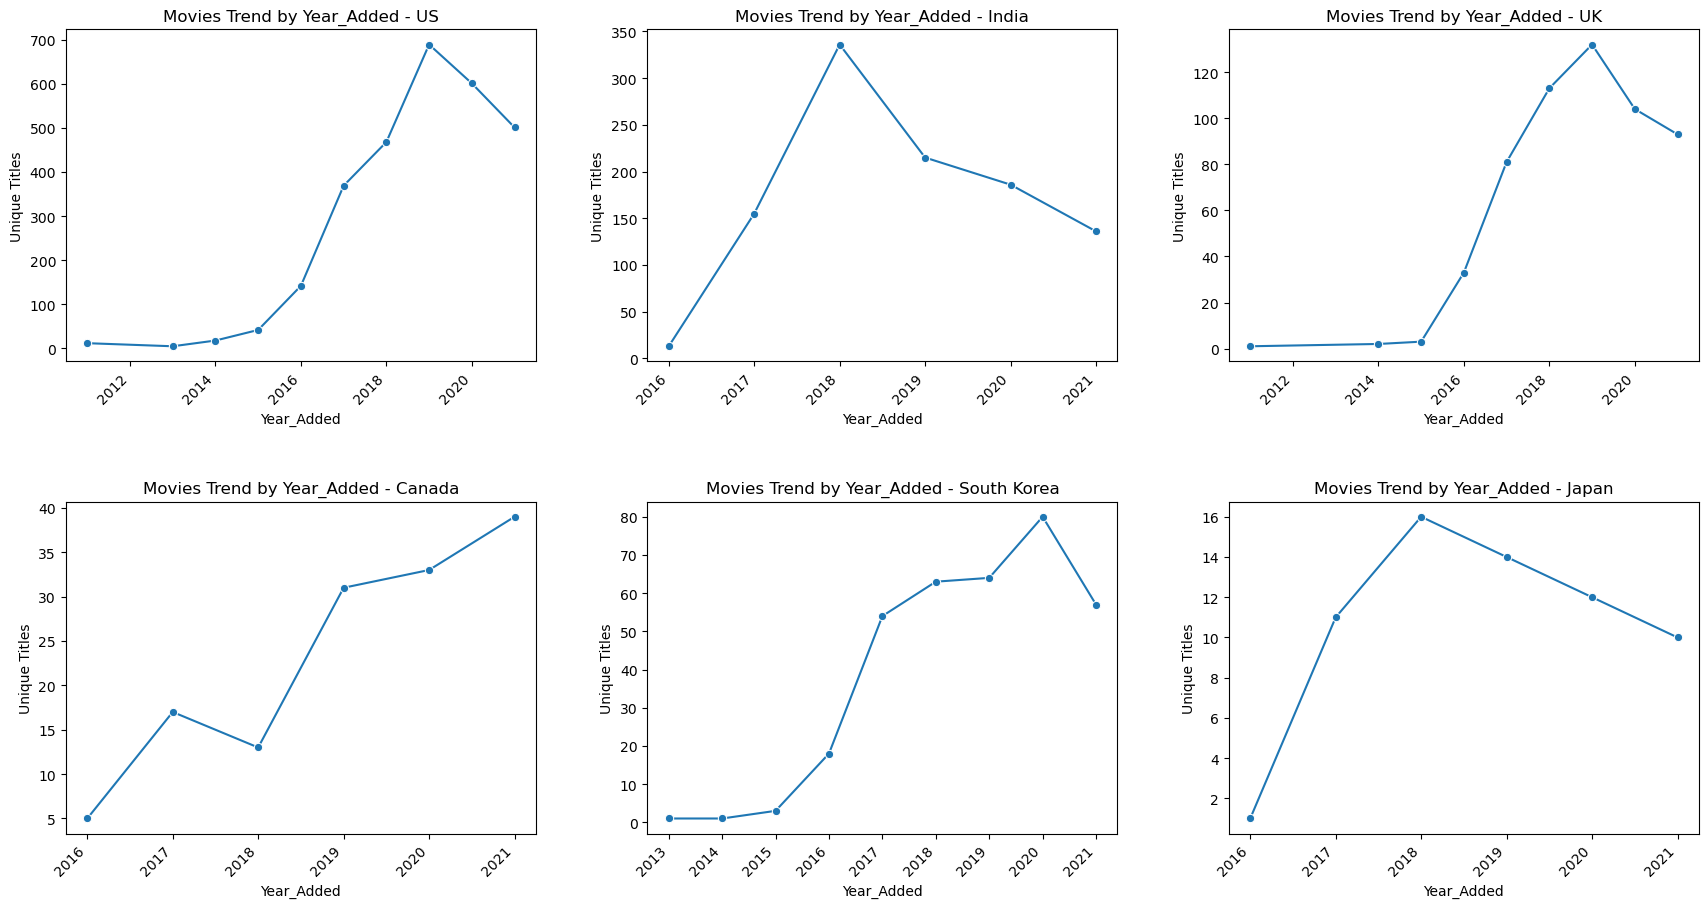

In [166]:
# For movies based on 'year_added':
Analyze_column_trends_by_country(df_movies_us, df_movies_in, df_movies_uk,df_movies_ca, df_movies_sk,df_movies_jp, column_name='year_added', media_type='movies')

## 🎬 Key Observations by Country (Movies - Year Added):

### 🇺🇸 United States  
**Year Added Breakdown**:  
- 2019 (689), 2020 (601), 2021 (501), 2018 (468), 2017 (369), 2016 (142), 2015 (42), 2014 (18), 2011 (12), 2013 (5)  
**Trend**: The number of movies added surged in **2019**, **2020**, and **2021**, with **2019** being the peak year. There is a notable drop in the number of movies added prior to 2017, with very few movies being added in 2011 and earlier years.

### 🇮🇳 India  
**Year Added Breakdown**:  
- 2018 (336), 2019 (215), 2020 (186), 2017 (155), 2021 (136), 2016 (13)  
**Trend**: **2018** saw the highest number of movie additions, followed by **2019** and **2020**. The number of movies added sharply declined before 2017, especially in **2016**, where the number is very low.

### UK United Kingdom  
**Year Added Breakdown**:  
- 2019 (132), 2018 (113), 2020 (104), 2021 (93), 2017 (81), 2016 (33), 2015 (3), 2014 (2), 2011 (1)  
**Trend**: The UK saw significant movie additions in **2019**, followed by **2018** and **2020**. Similar to other countries, the years before 2017 have a very low number of movies added, with just a few in 2015 and earlier.

### 🇨🇦 Canada  
**Year Added Breakdown**:  
- 2021 (39), 2020 (33), 2019 (31), 2017 (17), 2018 (13), 2016 (5)  
**Trend**: The most recent years (**2021**, **2020**, and **2019**) show a higher number of movie additions. However, earlier years like **2016** and before show a significantly lower number of movies added.

### SK South Korea  
**Year Added Breakdown**:  
- 2020 (80), 2019 (64), 2018 (63), 2021 (57), 2017 (54), 2016 (18), 2015 (3), 2013 (1), 2014 (1)  
**Trend**: **2020** led in terms of movie additions, followed by **2019** and **2018**. The number of movies added in 2016 and earlier is much lower, especially in **2013** and **2014**, where only a few movies were added.

### 🇯🇵 Japan  
**Year Added Breakdown**:  
- 2018 (16), 2019 (14), 2020 (12), 2017 (11), 2021 (10), 2016 (1)  
**Trend**: Japan has a low number of movie additions overall, with **2018** and **2019** being the peak years. The years before 2016 have a very low count, indicating limited movie additions in earlier years.

## 🌍 Cross-Country Trends:
- **2020** saw a high number of movies added across most countries, with the **US** and **South Korea** leading the way.
- **2019** and **2021** also show significant movie additions, especially in countries like the **US** and **India**.
- Countries like the **UK**, **Canada**, and **South Korea** saw their peak years in the past few years (2019-2021).
- Older years (prior to 2016) show a drastic decline in the number of movies added across all countries, suggesting a more recent surge in movie content availability.

US:
     month_added  title
8             9    106
0             1     95
11           12     94
6             7     92
10           11     86
7             8     81
5             6     80
9            10     80
1             2     79
3             4     73 

India:
     month_added  title
3             4     18
2             3     16
4             5     11
5             6      9
8             9      8
9            10      8
11           12      8
7             8      7
6             7      6
1             2      4 

UK:
     month_added  title
2             3     41
8             9     30
9            10     29
11           12     27
6             7     26
3             4     24
7             8     22
0             1     19
1             2     19
4             5     16 

Camada:
     month_added  title
5             6     27
11           12     27
0             1     22
6             7     21
3             4     20
2             3     19
7             8     19
10           11     19
8

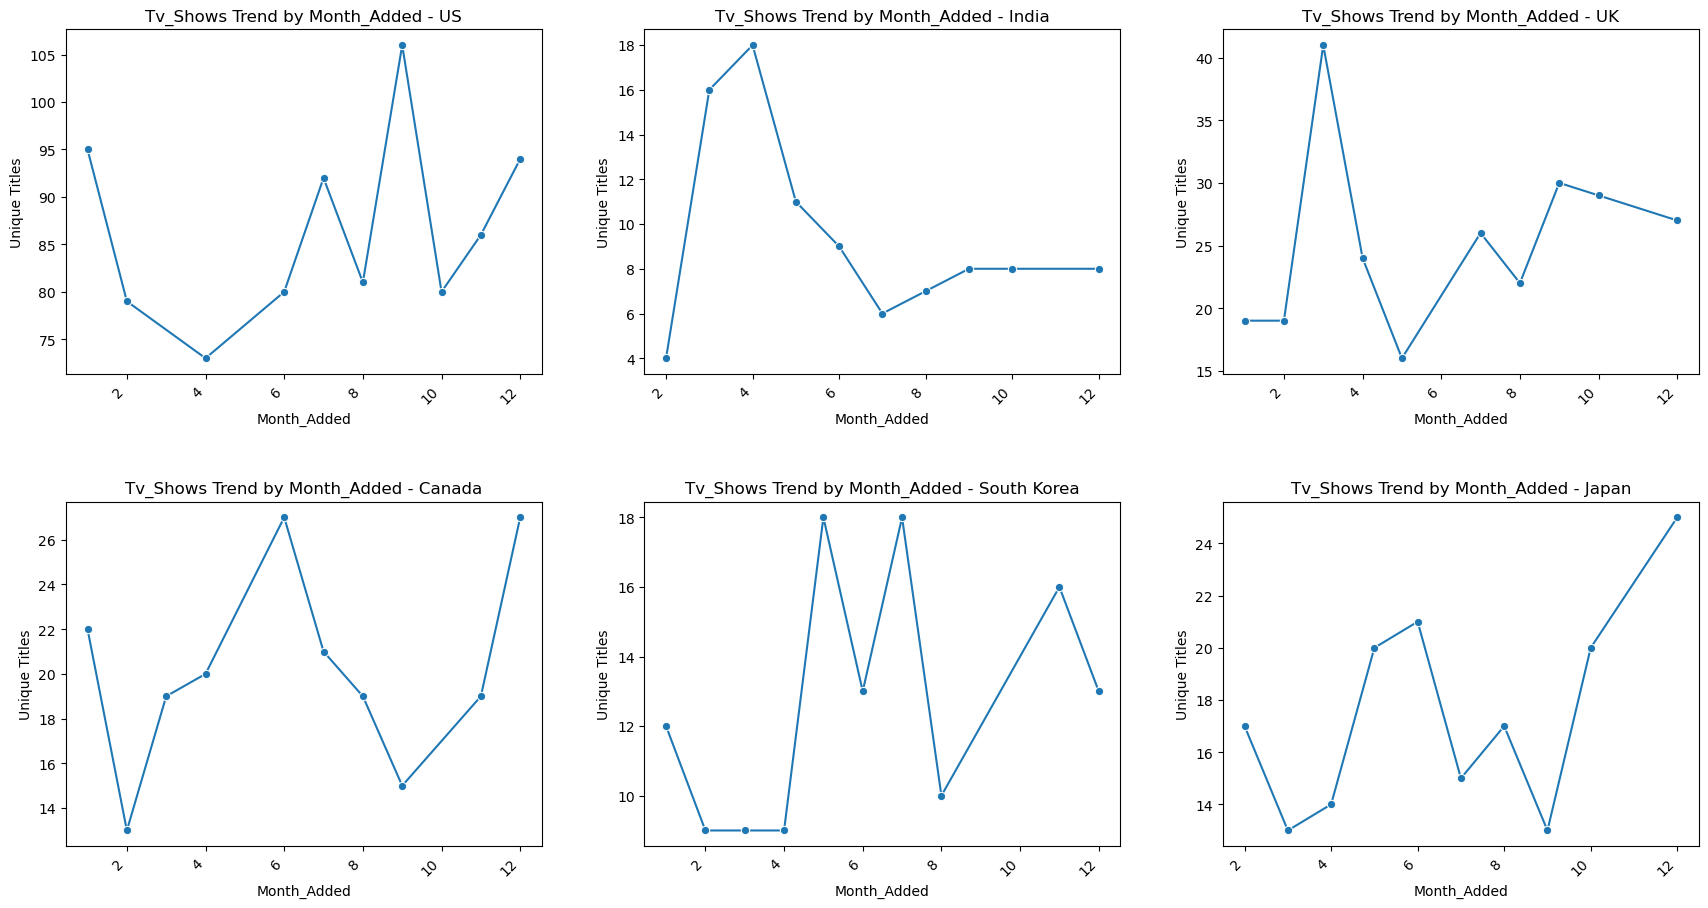

In [168]:

# For tv_shows based on 'month_added':
Analyze_column_trends_by_country(df_shows_us, df_shows_in, df_shows_uk,df_shows_ca, df_shows_sk,df_shows_jp, column_name='month_added', media_type='tv_shows')

## 🗓️ Key Observations by Country (TV Shows - Month Added):

### 🇺🇸 United States  
**Month Added Breakdown**:  
September (106), January (95), December (94), July (92), November (86), August (81), June (80), October (80), February (79), April (73)  
**Trend**: The highest number of TV shows were added in **September**, followed closely by **January** and **December**. There’s a fairly even distribution throughout the rest of the year, with slightly fewer additions in **April**.

### 🇮🇳 India  
**Month Added Breakdown**:  
April (18), March (16), May (11), June (9), September (8), October (8), December (8), August (7), July (6), February (4)  
**Trend**: **April** and **March** stand out with the most additions. Additions taper off after May, with consistently low numbers in the rest of the months, especially **February**.

### UK United Kingdom  
**Month Added Breakdown**:  
March (41), September (30), October (29), December (27), July (26), April (24), August (22), January (19), February (19), May (16)  
**Trend**: **March** is the peak month for additions, followed by **September** and **October**. The rest of the months are relatively balanced, though **May** has the lowest count.

### 🇨🇦 Canada  
**Month Added Breakdown**:  
June (27), December (27), January (22), July (21), April (20), March (19), August (19), November (19), September (15), February (13)  
**Trend**: **June** and **December** are tied for the highest additions. The middle months (March–August) show consistent activity. **February** and **September** have the fewest additions.

### SK South Korea  
**Month Added Breakdown**:  
May (18), July (18), November (16), June (13), December (13), January (12), August (10), February (9), March (9), April (9)  
**Trend**: Additions peak in **May** and **July**, followed by **November**. The rest of the months have similar, moderate numbers, especially from **February to April**.

### 🇯🇵 Japan  
**Month Added Breakdown**:  
December (25), June (21), May (20), October (20), February (17), August (17), July (15), April (14), March (13), September (13)  
**Trend**: **December** leads with the most additions, followed by **June**, **May**, and **October**. The other months have relatively even distributions, with **March** and **September** at the lower end.

## 🌍 Cross-Country Trends:
- **December** and **June** are consistently strong months for TV show additions across several countries, especially **Japan**, **Canada**, and the **US**.
- **March**, **April**, and **May** are strong months for **India**, the **UK**, and **South Korea**.
- Countries like **India** and **South Korea** show lower activity in **February** compared to others.

US:
     month_added  title
0             1    328
6             7    268
10           11    262
8             9    247
7             8    245
9            10    241
3             4    237
11           12    236
2             3    222
5             6    209 

India:
     month_added  title
11           12    117
3             4    113
9            10    109
2             3     99
6             7     98
7             8     96
10           11     93
8             9     79
0             1     70
4             5     67 

UK:
     month_added  title
0             1     55
9            10     54
11           12     54
7             8     51
8             9     51
2             3     47
3             4     47
6             7     46
1             2     44
4             5     44 

Camada:
     month_added  title
8             9     32
5             6     19
11           12     14
3             4     13
2             3     10
0             1      9
6             7      8
10           11      8
1

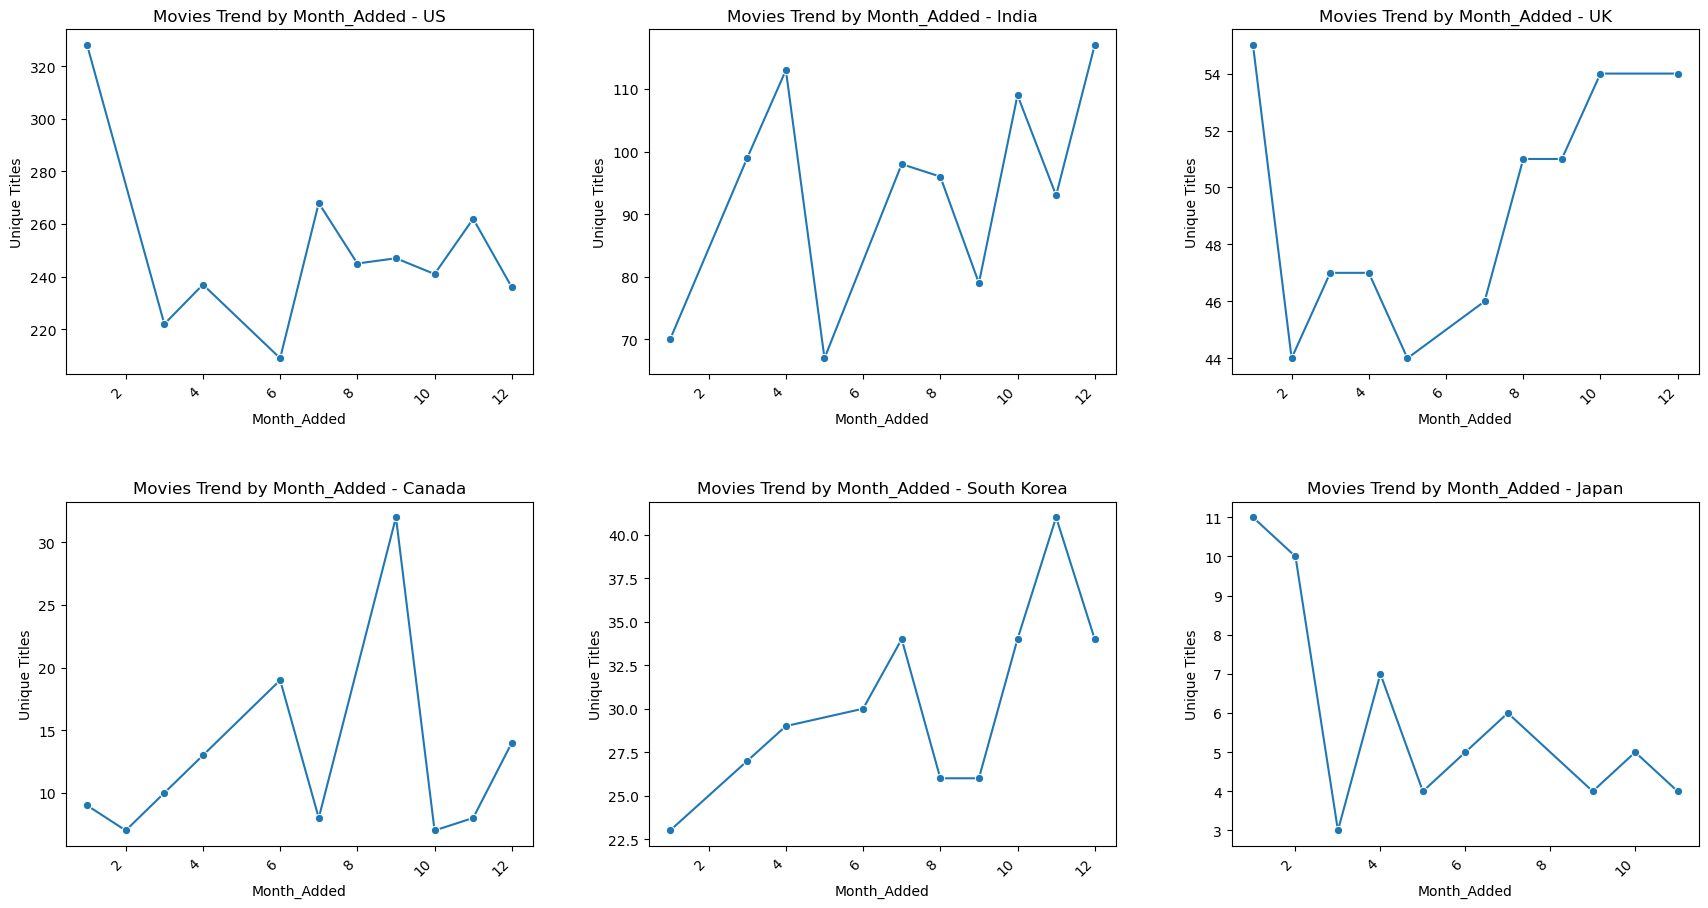

In [170]:
# For movies based on 'month_added':
Analyze_column_trends_by_country(df_movies_us, df_movies_in, df_movies_uk,df_movies_ca, df_movies_sk,df_movies_jp, column_name='month_added', media_type='movies')

## 🗓️ Key Observations by Country (Movies - Month Added):

### 🇺🇸 United States  
**Month Added Breakdown**:  
January (328), July (268), November (262), September (247), August (245), October (241), April (237), December (236), March (222), June (209)  
**Trend**: **January** has the highest number of movies added, followed by **July** and **November**. The number of movies added is relatively high across all months, with **June** seeing the least additions.

### 🇮🇳 India  
**Month Added Breakdown**:  
December (117), April (113), October (109), March (99), July (98), August (96), November (93), September (79), January (70), May (67)  
**Trend**: **December** leads with the most movies added, followed closely by **April** and **October**. The additions are lower in **January** and **May**, with a consistent number of movies added from **March to November**.

### UK United Kingdom  
**Month Added Breakdown**:  
January (55), October (54), December (54), August (51), September (51), March (47), April (47), July (46), February (44), May (44)  
**Trend**: **January** is the highest for movie additions, with **October** and **December** closely following. The months **February** and **May** have the lowest counts.

### 🇨🇦 Canada  
**Month Added Breakdown**:  
September (32), June (19), December (14), April (13), March (10), January (9), July (8), November (8), February (7), October (7)  
**Trend**: **September** is the peak month for additions, while **June** follows closely. The number of movies added drops significantly in **October**, **February**, and **July**, which see the lowest additions.

### SK South Korea  
**Month Added Breakdown**:  
November (41), July (34), October (34), December (34), June (30), April (29), March (27), August (26), September (26), January (23)  
**Trend**: **November** leads with the most additions, followed by **July** and **October**. The other months show relatively consistent activity, with **January** seeing the lowest number of additions.

### 🇯🇵 Japan  
**Month Added Breakdown**:  
January (11), February (10), April (7), July (6), June (5), October (5), May (4), September (4), November (4), March (3)  
**Trend**: **January** and **February** are the months with the highest number of movies added. The number of movies added sharply drops after **February**, with the lowest count seen in **March**.

## 🌍 Cross-Country Trends:
- **December** is a prominent month across countries like **India**, **South Korea**, and **the UK**, showing a peak in movie additions.
- **January** and **July** are consistently high across **the US**, **South Korea**, and **India**.
- Months like **March**, **February**, and **May** tend to see lower additions across several countries, especially in **Japan** and **Canada**.
- The data suggests a higher concentration of additions toward the latter part of the year, particularly in **November** and **December**, possibly influenced by holiday seasons or special content releases.

US:
     week_added  title
52          53     38
43          44     31
25          26     29
4            5     29
36          37     28
26          27     28
23          24     27
34          35     27
38          39     26
35          36     24 

India:
     week_added  title
8           13     11
9           14      6
12          18      6
10          15      6
16          22      5
33          40      4
30          37      4
2            7      3
4            9      3
39          48      3 

UK:
     week_added  title
12          13     21
30          31     16
4            5     15
38          40     15
33          35     11
35          37     11
26          27      8
29          30      8
10          11      8
16          17      7 

Camada:
     week_added  title
0            1     10
24          27     10
48          53     10
43          48      8
19          22      8
39          44      8
16          18      8
3            5      7
46          51      7
45          50      6

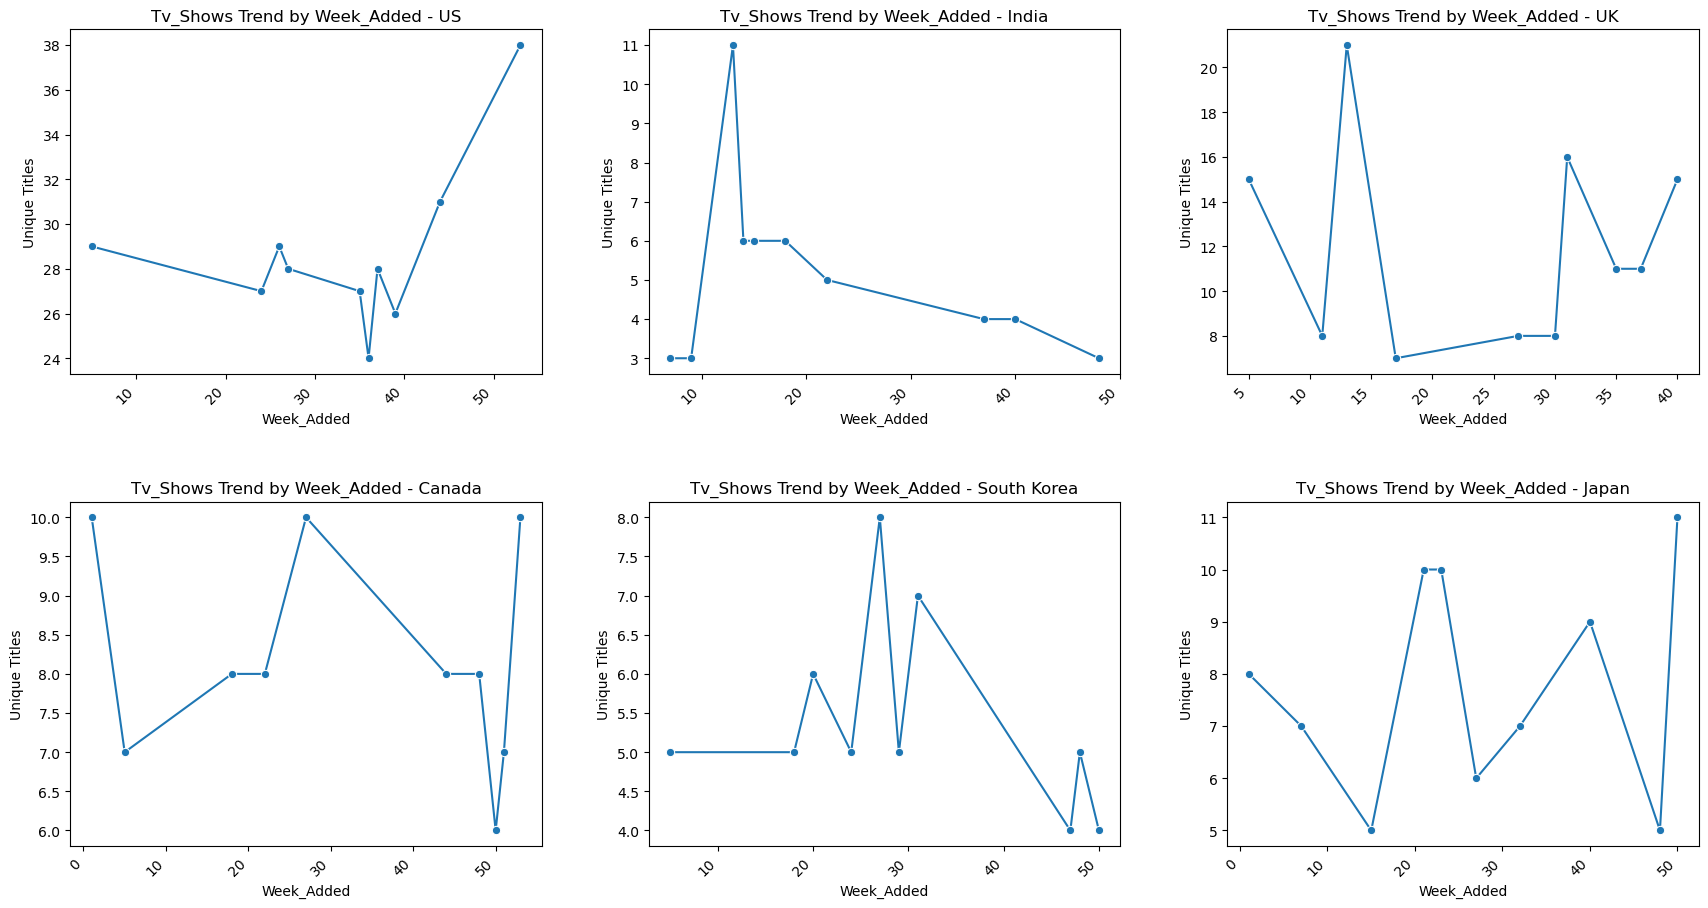

In [172]:
# For tv_shows based on 'week_added':
Analyze_column_trends_by_country(df_shows_us, df_shows_in, df_shows_uk, df_shows_ca, df_shows_sk,df_shows_jp, column_name='week_added', media_type='tv_shows')

## 🗓️ Key Observations by Country (TV Shows - Week Added):

### 🇺🇸 United States  
**Week Added Breakdown**:  
Week 53 (38), Week 44 (31), Week 26 (29), Week 5 (29), Week 37 (28), Week 27 (28), Week 24 (27), Week 35 (27), Week 39 (26), Week 36 (24)  
**Trend**: **Week 53** leads with the most shows added, followed by **Week 44** and **Week 26**. The additions are spread out, with many weeks contributing similar counts, especially around **Week 26 to Week 39**.

### 🇮🇳 India  
**Week Added Breakdown**:  
Week 13 (11), Week 14 (6), Week 18 (6), Week 15 (6), Week 22 (5), Week 40 (4), Week 37 (4), Week 7 (3), Week 9 (3), Week 48 (3)  
**Trend**: **Week 13** sees the highest number of shows added, while **Weeks 14 and 15** also show notable numbers. The data is more spread out in India, with a large gap between **Week 13** and the other weeks.

### UK United Kingdom  
**Week Added Breakdown**:  
Week 13 (21), Week 31 (16), Week 5 (15), Week 40 (15), Week 35 (11), Week 37 (11), Week 27 (8), Week 30 (8), Week 11 (8), Week 17 (7)  
**Trend**: **Week 13** leads with the highest additions, with **Week 31** and **Week 5** following closely. The additions are more concentrated in the earlier weeks, especially **Week 13**.

### 🇨🇦 Canada  
**Week Added Breakdown**:  
Week 1 (10), Week 27 (10), Week 53 (10), Week 48 (8), Week 22 (8), Week 44 (8), Week 18 (8), Week 5 (7), Week 51 (7), Week 50 (6)  
**Trend**: **Week 1**, **Week 27**, and **Week 53** have the highest additions, with **Weeks 48 and 44** following closely. Other weeks like **Weeks 5** and **50** show lower additions.

### SK South Korea  
**Week Added Breakdown**:  
Week 27 (8), Week 31 (7), Week 20 (6), Week 18 (5), Week 48 (5), Week 5 (5), Week 29 (5), Week 24 (5), Week 50 (4), Week 47 (4)  
**Trend**: **Week 27** leads with **Week 31** and **Week 20** following. A consistent number of additions occur throughout the weeks, with the lowest additions seen in **Week 47** and **Week 50**.

### 🇯🇵 Japan  
**Week Added Breakdown**:  
Week 50 (11), Week 21 (10), Week 23 (10), Week 40 (9), Week 1 (8), Week 32 (7), Week 7 (7), Week 27 (6), Week 48 (5), Week 15 (5)  
**Trend**: **Week 50** leads, followed by **Weeks 21 and 23**. Other weeks show a steady addition of shows, with **Week 1** having 8 added shows.

## 🌍 Cross-Country Trends:
- **Week 53** is a key week in **the US** and **Canada**, leading with the most additions in both countries.
- **Week 13** is prominent in **the US** and **the UK**, while **India** also shows significant activity in **Week 13**.
- There is a trend of **week-specific peaks** in the first few weeks (e.g., **Week 1**, **Week 5**, **Week 13**, **Week 27**) across multiple countries.
- The **later part of the year** (**Week 40-53**) shows a stronger concentration of additions, particularly in **the US** and **Canada**, indicating possible seasonal trends or content strategy adjustments.

US:
     week_added  title
0            1    166
43          44    131
34          35    107
39          40     97
12          13     93
25          26     93
26          27     82
21          22     79
8            9     71
30          31     70 

India:
     week_added  title
0            1     92
8            9     66
39          40     65
43          44     58
30          31     44
25          26     40
17          18     36
13          14     33
33          34     33
26          27     33 

UK:
     week_added  title
0            1     38
39          40     23
12          13     22
43          44     22
16          17     18
29          30     17
30          31     17
17          18     17
21          22     16
25          26     15 

Camada:
     week_added  title
32          37     14
21          24      8
33          38      7
30          35      7
0            1      5
10          13      5
35          41      5
44          52      5
5            8      5
6            9      5

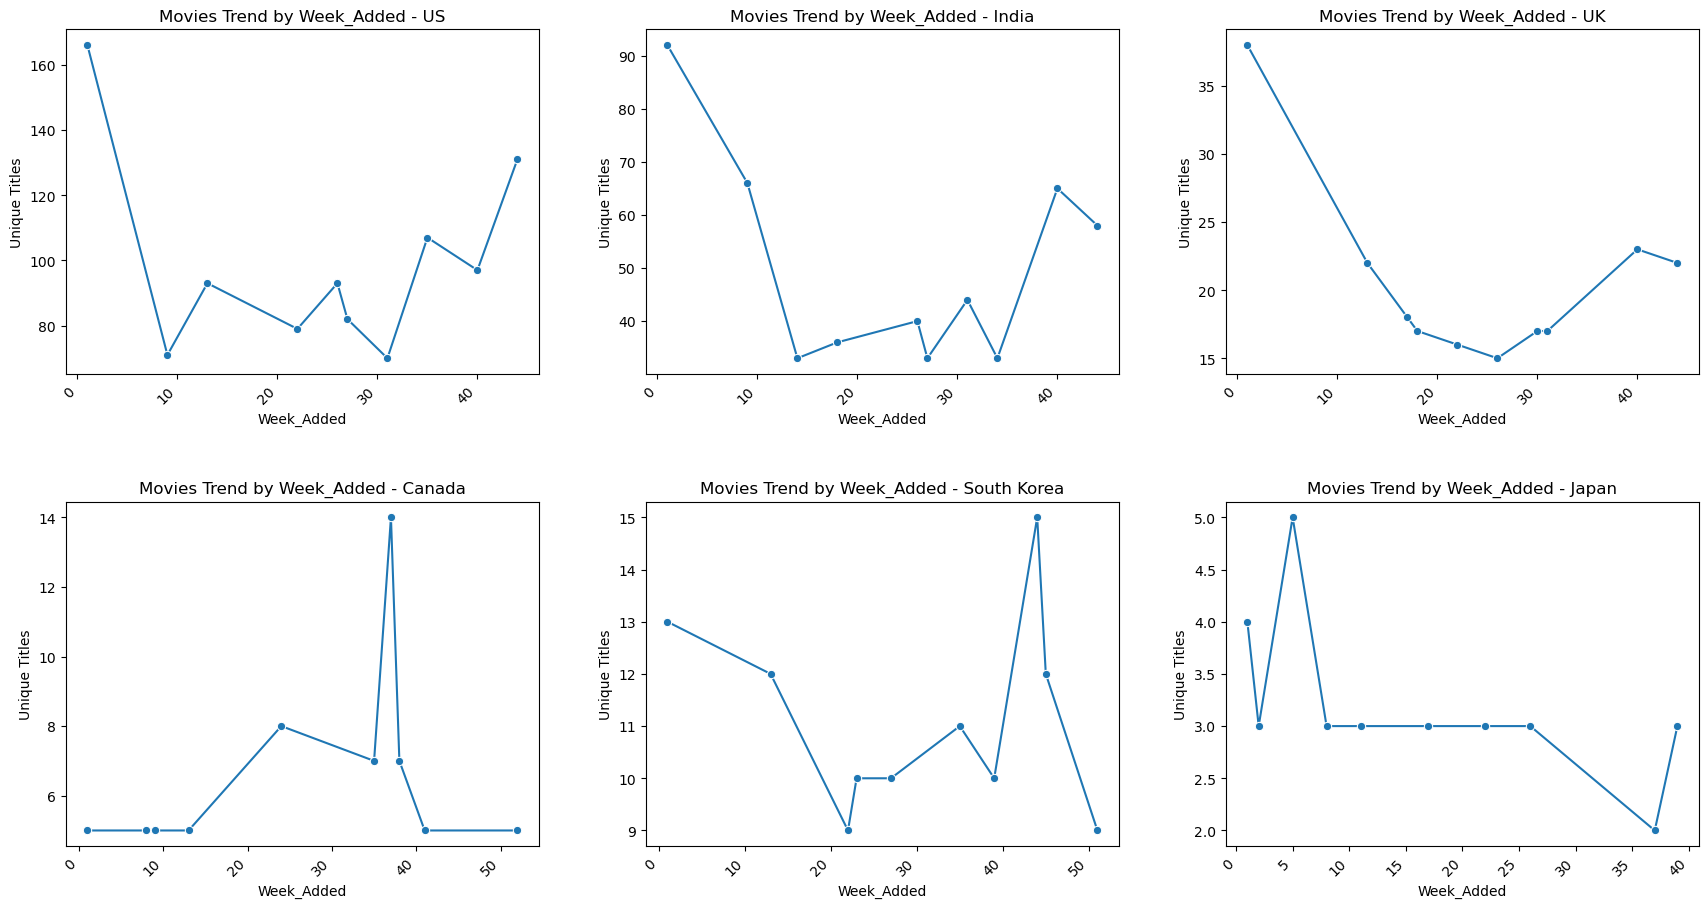

In [174]:
# For movies based on 'week_added':
Analyze_column_trends_by_country(df_movies_us, df_movies_in, df_movies_uk,df_movies_ca, df_movies_sk,df_movies_jp, column_name='week_added', media_type='movies')

## 🗓️ Key Observations by Country (Movies - Week Added):

### 🇺🇸 United States  
**Week Added Breakdown**:  
Week 1 (166), Week 44 (131), Week 35 (107), Week 40 (97), Week 13 (93), Week 26 (93), Week 27 (82), Week 22 (79), Week 9 (71), Week 31 (70)  
**Trend**: **Week 1** stands out as the top week for movie additions, followed by **Weeks 44 and 35**. The addition pattern is relatively spread out, with consistent activity across **Weeks 1, 13, 35, and 44**.

### 🇮🇳 India  
**Week Added Breakdown**:  
Week 1 (92), Week 9 (66), Week 40 (65), Week 44 (58), Week 31 (44), Week 26 (40), Week 18 (36), Week 14 (33), Week 34 (33), Week 27 (33)  
**Trend**: **Week 1** leads with the highest number of movie additions, followed by **Weeks 9, 40**, and **44**. The numbers are quite spread across weeks, especially **Week 40** in India.

### UK United Kingdom  
**Week Added Breakdown**:  
Week 1 (38), Week 40 (23), Week 13 (22), Week 44 (22), Week 17 (18), Week 30 (17), Week 31 (17), Week 18 (17), Week 22 (16), Week 26 (15)  
**Trend**: **Week 1** tops the list for the UK, with **Weeks 40 and 13** showing steady additions. The country also has significant activity in **Week 44** with 22 movies added.

### 🇨🇦 Canada  
**Week Added Breakdown**:  
Week 37 (14), Week 24 (8), Week 38 (7), Week 35 (7), Week 1 (5), Week 13 (5), Week 41 (5), Week 52 (5), Week 8 (5), Week 9 (5)  
**Trend**: **Week 37** has the highest number of movies added, while other weeks like **Week 24** and **Week 35** show moderate activity. **Week 1** and other later weeks like **41, 52** show consistent but smaller additions.

### 🇰🇷 South Korea  
**Week Added Breakdown**:  
Week 44 (15), Week 1 (13), Week 45 (12), Week 13 (12), Week 35 (11), Week 39 (10), Week 27 (10), Week 23 (10), Week 22 (9), Week 51 (9)  
**Trend**: **Week 44** leads, followed by **Week 1**. South Korea shows moderate additions across multiple weeks, with consistent activity in **Weeks 1, 13**, and **44**.

### 🇯🇵 Japan  
**Week Added Breakdown**:  
Week 5 (5), Week 1 (4), Week 11 (3), Week 39 (3), Week 2 (3), Week 22 (3), Week 17 (3), Week 26 (3), Week 8 (3), Week 37 (2)  
**Trend**: **Week 5** sees the highest number of additions, with **Week 1** closely following. Activity is relatively spread across other weeks, though the numbers are smaller compared to other countries.

## 🌍 Cross-Country Trends:
- **Week 1** stands out as the key week for movie additions in **the US** and **India**.
- **Week 44** is significant in **the US** and **South Korea**, while **Week 40** is prominent in both **the US** and **India**.
- **Weeks 35-37** show a notable amount of activity in both the **US** and **Canada**, with **Week 37** being significant in **Canada**.
- The later part of the year (**Week 40-52**) sees more concentrated activity in **South Korea** and **Canada**, indicating possible strategic content releases.

In [911]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Netflix_Datacleaning.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/EDA on Netflix-checkpoint.ipynb
	.ipynb_checkpoints/Netflix_Datacleaning-checkpoint.ipynb
	.ipynb_checkpoints/Netflix_cleaned_data-checkpoint.csv
	.ipynb_checkpoints/README-checkpoint.md
	EDA on Netflix.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [986]:
!git add "EDA on Netflix.ipynb"

In [988]:
!git commit -m "Added EDA on Netflix.ipynb"

[main 5464918] Added EDA on Netflix.ipynb
 1 file changed, 3207 insertions(+)
 create mode 100644 EDA on Netflix.ipynb


In [992]:
!git push

To https://github.com/PatraRupali/EDAOnNetflix.git
   744d9c7..5464918  main -> main


Genre Counts:
listed_in
International Movies            2731
Dramas                          2411
Comedies                        1669
International TV Shows          1350
Documentaries                    869
Action & Adventure               852
TV Dramas                        761
Independent Movies               755
Children & Family Movies         638
Romantic Movies                  615
TV Comedies                      581
Thrillers                        570
Crime TV Shows                   470
Kids' TV                         451
Docuseries                       395
Music & Musicals                 370
Romantic TV Shows                370
Horror Movies                    352
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 253
Sci-Fi & Fantasy                 242
Sports Movies                    219
Anime Series                     176
Spanish-Language TV Shows        174
TV Action & Adventure            168
Korean TV Show

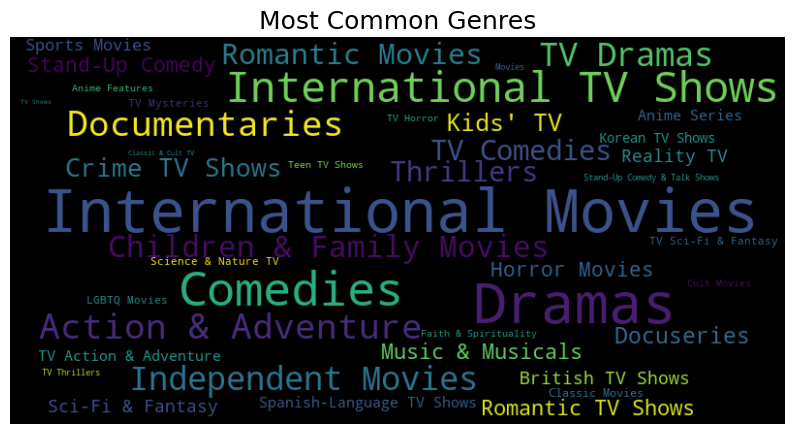

In [1040]:
# Drop duplicates for movies to ensure each genre is counted only once per title
genre_df = df[['listed_in', 'title']].drop_duplicates(subset=['title', 'listed_in'])

# Group by genre and count unique titles in each genre
genre_counts= genre_df.groupby('listed_in')['title'].count().sort_values(ascending=False)

# Print the genre counts for Movies
print("Genre Counts:")

# Generate word cloud for Movies from genre counts with 'viridis' colormap
wordcloud_movies = WordCloud(width=800, height=400, background_color='black', colormap='viridis').generate_from_frequencies(genre_counts)

# Plot the word cloud for Movies
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud_movies, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Genres', fontsize=18)
plt.show()